# Bright solitons — imaginary-time ground states and real-time dynamics of the nonlinear Schrödinger equation

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 1 — Computational toolbox*

## 1. Introduction and motivation

Quantum mechanics is linear. The superposition principle is not a convenience, it is the axiom: if
$\psi_1$ and $\psi_2$ solve the Schrödinger equation, so does $\alpha\psi_1 + \beta\psi_2$. Notebook
[00a](00a_free_particle_gaussian_wave_packet.ipynb) used that linearity to solve the free particle exactly, and
notebook [00b](00b_first_quantum_simulation_harmonic_oscillator.ipynb) used it again to expand any state in
energy eigenstates.

This notebook solves an equation that is **not** linear:

$$ i\,\frac{\partial\psi}{\partial t} \;=\; -\frac{1}{2}\frac{\partial^{2}\psi}{\partial x^{2}}
   \;-\; g\,\vert\psi\vert^{2}\psi . \tag{1} $$

The last term is cubic in the unknown function. Multiply $\psi$ by two and it grows by eight, not by two:
superposition is gone, and with it the whole machinery of eigenstates and spectral decomposition. Section 2
explains where such an equation comes from in a theory that is linear by construction — the short answer is
that Eq. (1) is not an equation for *the* wave function of a quantum system but for **one orbital occupied by
$N$ particles at once**, with the other $N-1$ particles acting on it as an average field. It is the
**Gross-Pitaevskii equation** of a Bose-Einstein condensate, and it is also, with different symbols, the
equation for the envelope of a light pulse in a glass fibre.

The physics that motivates it is one specific phenomenon. In 00a we watched a Gaussian wave packet spread: the
width grew as $\sigma(t) = \sigma_0\sqrt{1+(t/2\sigma_0^2)^2}$ and there was nothing anyone could do about it,
because a localised packet necessarily contains a range of momenta and those momenta travel at different
speeds. When $g>0$ in Eq. (1) the particles **attract** each other, and the attraction can balance the
spreading exactly. The result is a **bright soliton**: a lump of matter that travels for ever at constant
velocity, with constant shape and constant width. Two laboratories produced one in 2002 out of a few thousand
lithium-7 atoms, and one of them watched it travel $1.1\,\mathrm{mm}$ without dispersing.

Finding it on a computer needs a technique we have not used yet. In 00b the ground state came from
*diagonalising* a matrix. That is impossible here: "the Hamiltonian" contains $\vert\psi\vert^2$, so it depends
on the very state we are looking for, and there is no matrix to hand to an eigensolver. The replacement is
**imaginary-time evolution**: run the Schrödinger equation with $t$ replaced by $-i\tau$ and every state decays
towards the lowest one. Sections 7 and 8 build that idea from the linear case, where everything can be checked
against 00b, up to the nonlinear case, where it becomes a gradient flow of the energy.

### Road map

* **Section 2** — the Hartree argument: $N$ bosons in one orbital, a contact interaction, and how
  $\vert\psi\vert^2\psi$ appears. What is approximated, and where the same equation describes light.
* **Section 3** — the 1D Gross-Pitaevskii equation in SI units, the coupling constant $g_{\rm 1D}$ of a tight
  waveguide, and the non-dimensionalisation that reduces the problem to the single number $g$ of Eq. (1).
  Numbers for the lithium-7 experiments.
* **Section 4** — the energy functional, conservation of norm, energy and momentum, and why the chemical
  potential $\mu$ differs from the energy per particle.
* **Section 5** — the exact soliton, derived: first integral of the stationary equation, the mechanical
  analogy, the $\mathrm{sech}$ profile, $\mu = -g^2/8$, $E = -g^2/24$; and the Galilean boost.
* **Section 6** — the physics: dispersion against attraction, why 1D is safe and 3D collapses, the
  one-parameter family, $\mu = dE/dN$, the soliton as a particle, what the mean field hides, integrability,
  and the limits of the description.
* **Sections 7 and 8** — imaginary time: the idea in four layers with a numerical demonstration for each, then
  the split-step algorithm, its convergence in $\Delta\tau$, $N_x$ and $L$, and its failure modes.
* **Section 9** — real time: why split-step and not Runge-Kutta, the stationary soliton, the moving soliton
  against the spreading linear packet, a non-soliton initial state, convergence and conservation.
* **Section 10** — animations and space-time maps.
* **Section 11** — summary, an extended workflow checklist, exercises, references.

### What you will learn

*Physics*

* how a nonlinear equation arises from linear quantum mechanics through a mean-field (Hartree) approximation,
  and exactly which physics is thrown away in the process;
* the bright soliton: profile, chemical potential, energy, width, and the balance of kinetic dispersion
  against attractive interaction that produces it;
* why a one-dimensional attractive condensate is stable while a three-dimensional one collapses;
* $\mu = dE/dN$, self-binding, Galilean invariance, and the soliton as a composite particle;
* what integrability means in practice: a shape that is an attractor of nearby initial conditions.

*Numerical methods*

* imaginary-time evolution, derived from four independent points of view (spectral decay, diffusion with
  absorption, the power method, steepest descent on the energy functional);
* the Strang split-step Fourier method in imaginary and in real time, its $O(\Delta t^2)$ error, and the
  measured order of the bias it leaves in a converged ground state;
* the stability limit of an explicit Runge-Kutta integrator on a grid, and why an unconditionally stable
  method changes what is possible;
* convergence monitors for an iterative ground-state solver: energy, chemical potential, residual.

*Implementation practice*

* one `lax.scan` body reused for imaginary and real time, compiled once with `jax.jit`;
* `jax.grad` for the derivative $\mu = dE_{\rm tot}/dN$;
* validating a nonlinear solver against a closed-form solution at every stage.

### Prerequisites

[00a — a free Gaussian wave packet on a ring](00a_free_particle_gaussian_wave_packet.ipynb) for
non-dimensionalisation, periodic grids, `fftfreq`, spectral derivatives and expectation values on a grid, and
[00b — the harmonic oscillator](00b_first_quantum_simulation_harmonic_oscillator.ipynb) for potentials,
eigenstates, and the stability of explicit time integrators. One semester of quantum mechanics. No JAX
knowledge: the three features used here (`jit`, `lax.scan`, `grad`) are each explained in two sentences where
they appear, and properly in [01 — JAX from scratch](01_jax_from_scratch.ipynb).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Where a nonlinear Schrödinger equation comes from

### 2.1 $N$ bosons in a single orbital

Take $N$ identical bosons of mass $m$ in one dimension, interacting pairwise:

$$ \hat H \;=\; \sum_{j=1}^{N}\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial X_j^2} + V_{\rm ext}(X_j)\right]
   \;+\; \sum_{j<l} U(X_j - X_l) . \tag{2} $$

The exact ground state of Eq. (2) is a function of $N$ variables. For $N = 10^4$ atoms that object cannot be
written down, stored, or computed: this is the many-body problem, and the rest of this course is about
attacking it with methods whose errors can be controlled. The **Hartree approximation** (Pethick and Smith, Chapter 6; Pitaevskii and Stringari) cuts through it with one assumption — that every particle
occupies the *same* single-particle orbital $\varphi(X)$:

$$ \Psi_{\rm Hartree}(X_1,\ldots,X_N) \;=\; \prod_{j=1}^{N}\varphi(X_j), \qquad
   \int \vert\varphi(X)\vert^2\,dX = 1 . \tag{3} $$

This is the definition of a Bose-Einstein condensate at the mean-field level: one orbital, occupied $N$ times.
It is a *variational ansatz*, so we get the best $\varphi$ by minimising the energy. Evaluate
$\langle \Psi\vert\hat H\vert\Psi\rangle$ term by term. The one-body part gives $N$ identical contributions:

$$ \sum_j \left\langle \Psi\left\vert -\frac{\hbar^2}{2m}\partial_{X_j}^2 + V_{\rm ext}(X_j)\right\vert\Psi\right\rangle
   = N\int \left[\frac{\hbar^2}{2m}\vert\varphi'\vert^2 + V_{\rm ext}\vert\varphi\vert^2\right] dX . $$

The interaction part has $N(N-1)/2$ identical pairs, and each pair contributes the same double integral because
both particles sit in the same orbital:

$$ \sum_{j<l}\left\langle\Psi\vert U(X_j-X_l)\vert\Psi\right\rangle
   = \frac{N(N-1)}{2}\iint \vert\varphi(X)\vert^2\,U(X-X')\,\vert\varphi(X')\vert^2\, dX\,dX' . $$

Read the last expression: each particle moves in the field produced by the *density of all the others*. That is
what "mean field" means, and it is why the interaction term is quadratic in the density instead of linear.

### 2.2 The contact interaction

For ultracold atoms the interatomic potential has a range of a few nanometres while the de Broglie wavelength
is hundreds of nanometres to micrometres. At such low energies only $s$-wave scattering survives, and the true
potential can be replaced by a **contact pseudopotential** that reproduces the same scattering length $a_s$
(Pethick and Smith, Chapter 5):

$$ U(X-X') \;=\; g_{\rm 1D}\,\delta(X-X') . $$

The double integral collapses to $\tfrac12 g_{\rm 1D}\int\vert\varphi\vert^4 dX$. Writing
$\Psi(X) \equiv \sqrt{N}\,\varphi(X)$ so that $\int\vert\Psi\vert^2 dX = N$ is the particle number, and
replacing $N(N-1)\to N^2$ (an error of relative size $1/N$, invisible for $N = 10^3$ and above), the energy
becomes

$$ E[\Psi] \;=\; \int\left[\frac{\hbar^{2}}{2m}\left\vert\frac{\partial\Psi}{\partial X}\right\vert^{2}
   \;+\; V_{\rm ext}(X)\,\vert\Psi\vert^{2} + \frac{g_{\rm 1D}}{2}\vert\Psi\vert^{4}\right] dX . \tag{4} $$

Minimising Eq. (4) at fixed $\int\vert\Psi\vert^2 = N$ means setting the functional derivative equal to a
Lagrange multiplier $\mu$ times $\Psi$, $\delta E/\delta\Psi^{*} = \mu\Psi$:

$$ \left[-\frac{\hbar^{2}}{2m}\frac{\partial^{2}}{\partial X^{2}} + V_{\rm ext}(X)
   \;+\; g_{\rm 1D}\vert\Psi\vert^{2}\right]\Psi \;=\; \mu\,\Psi , \tag{5} $$

and the corresponding time-dependent equation, whose stationary solutions are
$\Psi\,e^{-i\mu T/\hbar}$, is the **Gross-Pitaevskii equation**

$$ i\hbar\,\frac{\partial\Psi}{\partial T} \;=\;
   \left[-\frac{\hbar^{2}}{2m}\frac{\partial^{2}}{\partial X^{2}} + V_{\rm ext}(X)
   \;+\; g_{\rm 1D}\vert\Psi\vert^{2}\right]\Psi . \tag{6} $$

The factor $\tfrac12$ in Eq. (4) and its absence in Eq. (6) is not a typo: differentiating
$\tfrac12 g\vert\Psi\vert^4 = \tfrac12 g(\Psi^*\Psi)^2$ with respect to $\Psi^*$ gives $g\vert\Psi\vert^2\Psi$.
Section 4 turns that factor of two into the statement $\mu \ne E/N$.

### 2.3 What has been thrown away

The Hartree ansatz (3) is a product state. It therefore contains **no correlations whatsoever** between
particles: the probability of finding one atom at $X$ and another at $X'$ factorises exactly. Everything that
a real interacting gas does beyond the average — depletion of the condensate, quantum fluctuations, the
entanglement between the atoms, atoms outside the condensate mode — is absent by construction. The
approximation is good when the gas is dilute ($n\vert a_s\vert^3 \ll 1$ in three dimensions), almost fully condensed (almost all
atoms in the condensate) and large ($N \gg 1$, so that $N-1\approx N$). It is not a controlled expansion in a
small parameter that one can push to next order without extra work, and Section 6.5 points at one specific
prediction of Eq. (6) that is *qualitatively* wrong for the true many-body ground state.

> **Physics insight.** The nonlinearity of Eq. (6) does not violate the superposition principle of quantum
> mechanics. The underlying $N$-body Schrödinger equation is perfectly linear; $\Psi$ is not a probability
> amplitude for one particle but a classical-field description of an occupied orbital, of the same nature as
> the classical electromagnetic field that emerges from a coherent state of many photons. The Born rule does
> not apply to $\vert\Psi\vert^2$ as a probability density: it is a *particle density*, in atoms per metre.

### 2.4 The same equation for light in a fibre

In a glass fibre the refractive index depends weakly on the intensity, $n = n_0 + n_2 I$ (the **optical Kerr
effect**). Writing the electric field of a pulse as a slowly varying envelope $A(Z,T)$ on a carrier, expanding
the propagation constant to second order in frequency, and moving to a frame travelling at the group velocity
gives

$$ i\,\frac{\partial A}{\partial Z} \;=\; \frac{\beta_2}{2}\frac{\partial^{2} A}{\partial T_{\rm ret}^{2}}
   \;-\; \gamma\,\vert A\vert^{2} A , $$

with $\beta_2$ the group-velocity dispersion, $T_{\rm ret}$ the retarded time and $\gamma \propto n_2$. This is
Eq. (1) with the roles of space and time exchanged: the propagation distance $Z$ plays the part of time, and
the retarded time $T_{\rm ret}$ the part of position. For anomalous dispersion ($\beta_2 < 0$) the two terms
have the relative sign that produces bright solitons, and everything derived in this notebook — the
$\mathrm{sech}$ profile, the width-amplitude relation, the robustness — applies verbatim to optical pulses.

### 2.5 Attractive interactions and the 2002 experiments

The sign of $g_{\rm 1D}$ follows the sign of the $s$-wave scattering length $a_s$. For $a_s > 0$ the
interaction is repulsive, the condensate spreads out, and there is no localised state without a trap. For
$a_s < 0$ it is attractive. In three dimensions an attractive condensate is unstable above a critical atom
number — it implodes, an event observed and named the "Bosenova" — which is why the experiments confine the
gas tightly in two directions and let it move only along the third.

Two groups did exactly that in 2002, both with lithium-7, whose scattering length can be tuned through zero
with a magnetic Feshbach resonance:

* **Khaykovich et al.** (Science **296**, 1290 (2002)) released a cloud into a horizontal optical waveguide of
  radial frequency $\omega_\perp/2\pi = 710\,$Hz, at a magnetic field where $a_s = -0.21\,$nm, and followed a
  single soliton over $1.1\,$mm with no measurable spreading. The atom number they measure in the soliton is
  $6(2)\times10^{3}$; the stability analysis in the same paper puts it between $4.2\times10^{3}$ and
  $5.2\times10^{3}$. The calculations below use $N = 4.5\times10^{3}$, and Section 6.8 says what the gap
  between the two numbers means;
* **Strecker et al.** (Nature **417**, 150 (2002)) produced a *train* of solitons with about $5000$ atoms per
  soliton at $a_s\approx-3a_0 = -0.16\,$nm. The solitons live in an optical waveguide whose radial
  confinement is matched to their magnetic trap, $\omega_\perp/2\pi = 800\,$Hz, and they oscillate in a
  shallow axial potential with a period of $310\,$ms for many periods.

Section 3.5 puts these numbers into the units of Eq. (1).

## 3. The 1D Gross-Pitaevskii equation, and its single parameter

### 3.1 The coupling constant of a waveguide

Equation (6) is one-dimensional, but atoms live in three. The reduction is legitimate when the transverse
confinement is so tight that every atom stays in the transverse ground state: with a harmonic transverse trap
of frequency $\omega_\perp$, the transverse oscillator length is

$$ a_\perp \;=\; \sqrt{\frac{\hbar}{m\omega_\perp}} , $$

and the condition is that all the other energies in the problem stay far below $\hbar\omega_\perp$. Factorising
the 3D order parameter as $\Psi_{\rm 3D}(X,Y,Z) = \Psi(X)\,\chi_0(Y,Z)$ with $\chi_0$ the transverse ground
state and integrating out $Y,Z$ produces Eq. (6) with an effective one-dimensional coupling constant. Olshanii
computed it exactly, including the correction from the confinement-induced resonance
(Phys. Rev. Lett. **81**, 938 (1998)); to leading order in $a_s/a_\perp$,

$$ g_{\rm 1D} \;=\; 2\hbar\,\omega_\perp\, a_s . \tag{7} $$

We quote Eq. (7) without deriving it — the derivation is a scattering calculation in a waveguide, not a topic
of this course. Its structure is easy to remember: the three-dimensional coupling is
$g_{\rm 3D} = 4\pi\hbar^2 a_s/m$, and dividing by the transverse area $2\pi a_\perp^2$ occupied by the
Gaussian transverse mode gives $g_{\rm 3D}/(2\pi a_\perp^2) = 2\hbar^2 a_s/(m a_\perp^2) = 2\hbar\omega_\perp a_s$.
Olshanii's full result carries one extra factor,

$$ g_{\rm 1D} \;=\; \frac{2\hbar\,\omega_\perp\,a_s}{1 - C\,a_s/(\sqrt2\,a_\perp)} , \qquad C = 1.4603\ldots , $$

where the $\sqrt2$ appears because Olshanii's transverse length is built with the reduced mass $m/2$,
$(\hbar/(\tfrac{m}{2}\omega_\perp))^{1/2} = \sqrt2\,a_\perp$. The vanishing denominator is the confinement-induced resonance. Equation (7) is the leading term in
$a_s/a_\perp$, and for the two experiments of Section 2.5 that ratio is $1.5\times10^{-4}$ and
$1.2\times10^{-4}$: the correction is four orders of magnitude below everything else in this notebook, and we
drop it.

### 3.2 Scaled variables

The equation to be scaled is Eq. (6) without an external potential,

$$ i\hbar\,\frac{\partial\Psi(X,T)}{\partial T} \;=\;
   -\frac{\hbar^{2}}{2m}\frac{\partial^{2}\Psi}{\partial X^{2}} + g_{\rm 1D}\vert\Psi\vert^{2}\Psi ,
   \qquad \int\vert\Psi\vert^{2}dX = N . $$

Following 00a, introduce a length $x_0$ (still free), a time $t_0$ and an energy $E_0$, and write

$$ X = x_0\,x , \qquad T = t_0\,t , \qquad
   \psi(x,t) \;\equiv\; \sqrt{\frac{x_0}{N}}\;\Psi(x_0x,\,t_0t) . $$

The factor $\sqrt{x_0/N}$ does two jobs at once: $\sqrt{x_0}$ makes $\psi$ dimensionless as in 00a, and
$1/\sqrt{N}$ turns the normalisation $N$ into $1$,

$$ \int\vert\psi(x)\vert^{2}dx \;=\; \int \frac{x_0}{N}\vert\Psi\vert^{2}\,\frac{dX}{x_0}
   \;=\; \frac{1}{N}\int\vert\Psi\vert^{2}dX \;=\; 1 . $$

Substitute $\Psi = \sqrt{N/x_0}\,\psi$ and use $\partial_T = t_0^{-1}\partial_t$,
$\partial_X^2 = x_0^{-2}\partial_x^2$:

$$ \frac{i\hbar}{t_0}\sqrt{\frac{N}{x_0}}\,\frac{\partial\psi}{\partial t}
   \;=\; -\frac{\hbar^{2}}{2mx_0^{2}}\sqrt{\frac{N}{x_0}}\,\frac{\partial^{2}\psi}{\partial x^{2}}
   \;+\; g_{\rm 1D}\,\frac{N}{x_0}\,\vert\psi\vert^{2}\sqrt{\frac{N}{x_0}}\,\psi . $$

Cancel the common $\sqrt{N/x_0}$ and divide by $E_0 = \hbar/t_0$:

$$ i\,\frac{\partial\psi}{\partial t}
   \;=\; -\frac{\hbar t_0}{2mx_0^{2}}\,\frac{\partial^{2}\psi}{\partial x^{2}}
   \;+\; \frac{g_{\rm 1D}\,N\,t_0}{\hbar\,x_0}\,\vert\psi\vert^{2}\psi . $$

Choosing $t_0$ exactly as in 00a,

$$ t_0 \;=\; \frac{m x_0^{2}}{\hbar} , \qquad E_0 \;=\; \frac{\hbar}{t_0} \;=\; \frac{\hbar^{2}}{m x_0^{2}} , $$

makes the first coefficient $1/2$ and turns the second into
$g_{\rm 1D}N m x_0^2/(\hbar^2 x_0) = g_{\rm 1D}Nmx_0/\hbar^2$. Defining

$$ \boxed{\;g \;\equiv\; -\,\frac{N\,g_{\rm 1D}\,m\,x_0}{\hbar^{2}}\;}
   \qquad\Longrightarrow\qquad
   i\,\frac{\partial\psi}{\partial t} \;=\; -\frac{1}{2}\frac{\partial^{2}\psi}{\partial x^{2}}
   \;-\; g\,\vert\psi\vert^{2}\psi , \tag{8} $$

which is Eq. (1). The minus sign in the definition is a convention that makes $g > 0$ the *attractive* case
($g_{\rm 1D} < 0$, i.e. $a_s < 0$), which is the one that produces bright solitons. Repulsive interactions are
$g < 0$.

One dimensionless number, $g$, now carries the mass, the atom number, the scattering length and the transverse
confinement. Two experiments with completely different atom numbers and magnetic fields are the *same*
simulation if their $g$ agree.

### 3.3 Fixing $x_0$ so that $g$ is a pure number

The free particle of 00a had no intrinsic length and we borrowed one from the initial state. Equation (8)
is different: $g$ itself depends on $x_0$, so the choice of $x_0$ and the value of $g$ are not independent.
There is a distinguished choice. Section 5 will show that the soliton has a width $2/g$ in units of $x_0$,
i.e. a physical width

$$ \ell \;=\; x_0\cdot\frac{2}{g} \;=\; x_0\,\frac{2\hbar^{2}}{N\vert g_{\rm 1D}\vert m x_0}
   \;=\; \frac{2\hbar^{2}}{m N \vert g_{\rm 1D}\vert}
   \;\overset{(7)}{=}\; \frac{\hbar}{m N\omega_\perp\vert a_s\vert} \;=\; \frac{a_\perp^{2}}{N\vert a_s\vert} , \tag{9} $$

which does not contain $x_0$ at all, as it must not. Setting $x_0 = \ell$ then forces

$$ \frac{2}{g} = 1 \qquad\Longrightarrow\qquad g = 2 . $$

Every bright soliton in the universe is the same solution of Eq. (8) with $g = 2$; the only thing that changes
from one experiment to another is what one metre and one second mean. We will use $g = 2$ throughout, and vary
$g$ only where the point is the dependence on $g$ itself.

### 3.4 The unit table

| quantity | unit | value |
|---|---|---|
| length | $x_0 = \ell = a_\perp^{2}/(N\vert a_s\vert)$ | the soliton width |
| time | $t_0 = m x_0^{2}/\hbar$ | derived |
| energy | $E_0 = \hbar^{2}/(m x_0^{2})$ | derived |
| velocity | $v_0 = x_0/t_0 = \hbar/(m x_0)$ | derived |
| density | $1/x_0$ | $\vert\psi\vert^{2}$ integrates to $1$ |

A physical energy per particle is $E_0$ times the dimensionless energy; the *total* energy of the cloud is
$N E_0$ times it, because we normalised $\psi$ to one rather than to $N$. Section 6.3 uses that distinction.

### 3.5 Numbers for the lithium-7 experiments

The cell below is arithmetic only. It takes the published parameters of the two 2002 experiments, builds
$a_\perp$, $g_{\rm 1D}$, the soliton width $\ell$ of Eq. (9) and the unit system, and checks that the
resulting $g$ really is $2$. It also prints the dimensionless combination

$$ \kappa \;\equiv\; \frac{N\vert a_s\vert}{a_\perp} \;=\; \frac{a_\perp}{\ell} , $$

which Section 6.8 identifies as the parameter that decides whether the quasi-one-dimensional description is
valid at all.

In [2]:
# ==============================================================================
# EXTRA IMPORTS  -- everything else comes from the Configuration cell above
# ==============================================================================
import base64                                   # to inline the animated GIFs in the notebook output
import tempfile                                 # a scratch file for each GIF (deleted immediately)

from matplotlib.animation import FuncAnimation, PillowWriter   # GIF writing
from IPython.display import display                            # embed the GIF in the notebook output

# colour-blind-friendly palette, used consistently in every figure of this notebook
C_NUM, C_ANA, C_THIRD, C_GREY = "#0072B2", "#D55E00", "#009E73", "0.45"

print("extra imports OK")

extra imports OK


In [3]:
# ==============================================================================
# STEP 0: the unit system of a real bright soliton  (pure bookkeeping, no physics happens here)
#   a_perp = sqrt(hbar / (m omega_perp))          transverse oscillator length
#   g_1D   = 2 hbar omega_perp a_s                Olshanii, PRL 81, 938 (1998), leading order
#   ell    = a_perp^2 / (N |a_s|)                 soliton width, Eq. (9)  -> we set x_0 = ell
#   t_0    = m x_0^2 / hbar,  E_0 = hbar / t_0,  v_0 = x_0 / t_0
# ==============================================================================
HBAR_SI = 1.054571817e-34          # reduced Planck constant                [J s]
AMU     = 1.66053906660e-27        # atomic mass unit                       [kg]
M_LI7   = 7.0160034366 * AMU       # mass of a lithium-7 atom               [kg]


def soliton_units(N, a_s_m, nu_perp_hz, mass_kg=M_LI7):
    """Everything about a quasi-1D bright soliton, from the three numbers an experimentalist quotes.

    MATH
        a_perp = sqrt(hbar / (m * 2 pi nu_perp))
        g_1D   = 2 hbar (2 pi nu_perp) a_s                      [J m]     (a_s < 0 for attraction)
        ell    = a_perp^2 / (N |a_s|)                           [m]       the soliton width
        x_0    = ell,  t_0 = m x_0^2 / hbar,  E_0 = hbar / t_0,  v_0 = x_0 / t_0
        g      = -N g_1D m x_0 / hbar^2                         [-]       must come out as 2
        kappa  = N |a_s| / a_perp = a_perp / ell                [-]       quasi-1D / collapse parameter
    Returns a dict of SI floats plus the two dimensionless numbers.
    """
    omega_perp = 2.0 * np.pi * nu_perp_hz
    a_perp = np.sqrt(HBAR_SI / (mass_kg * omega_perp))
    g_1d = 2.0 * HBAR_SI * omega_perp * a_s_m                   # negative when a_s is negative
    ell = a_perp ** 2 / (N * abs(a_s_m))
    x0 = ell
    t0 = mass_kg * x0 ** 2 / HBAR_SI
    E0 = HBAR_SI / t0
    return {"a_perp": a_perp, "g_1d": g_1d, "ell": ell, "t0": t0, "E0": E0, "v0": x0 / t0,
            "g": -N * g_1d * mass_kg * x0 / HBAR_SI ** 2,
            "kappa": N * abs(a_s_m) / a_perp}


experiments = [("Khaykovich et al. 2002", 4500, -0.21e-9, 710.0),
               ("Strecker et al. 2002  ", 5000, -0.16e-9, 800.0)]

print(f"{'experiment':24s} {'a_perp[um]':>10s} {'ell[um]':>9s} {'t_0[ms]':>9s} "
      f"{'E_0/h[Hz]':>10s} {'v_0[mm/s]':>10s} {'g':>7s} {'kappa':>7s}")
for name, N_at, a_s, nu in experiments:
    u = soliton_units(N_at, a_s, nu)
    print(f"{name:24s} {u['a_perp'] * 1e6:10.3f} {u['ell'] * 1e6:9.3f} {u['t0'] * 1e3:9.4f} "
          f"{u['E0'] / (2 * np.pi * HBAR_SI):10.1f} {u['v0'] * 1e3:10.3f} {u['g']:7.4f} {u['kappa']:7.3f}")

# the choice x_0 = ell must give g = 2 exactly -- this is a check of the algebra of Section 3.3
for name, N_at, a_s, nu in experiments:
    assert abs(soliton_units(N_at, a_s, nu)["g"] - 2.0) < 1e4 * TOL, "x_0 = ell must force g = 2"
print("\ncheckpoint: x_0 = ell gives g = 2 for both experiments (to round-off)")

experiment               a_perp[um]   ell[um]   t_0[ms]  E_0/h[Hz]  v_0[mm/s]       g   kappa
Khaykovich et al. 2002        1.424     2.147    0.5093      312.5      4.216  2.0000   0.663
Strecker et al. 2002          1.342     2.251    0.5598      284.3      4.021  2.0000   0.596

checkpoint: x_0 = ell gives g = 2 for both experiments (to round-off)


Both experiments end up with a soliton about $2.2\,\mu\mathrm{m}$ wide, a time unit of about half a
millisecond and an energy unit of $313$ and $284\,\mathrm{Hz}$ — the scales a cold-atom laboratory works
with. The velocity unit is $4\,\mathrm{mm/s}$, so the $1.1\,\mathrm{mm}$ of free propagation reported by
Khaykovich et al. is $1.1\,\mathrm{mm}/2.15\,\mu\mathrm{m} = 512$ length units, which at one unit of
velocity would take $512$ time units, i.e. $0.26\,\mathrm{s}$. The last column is the one to watch:
$\kappa = a_\perp/\ell$ is $0.663$ and $0.596$, so the soliton is only $1.5$ to $1.7$ times wider than the
transverse ground state. These experiments are *quasi*-1D by a factor of order two, not by orders of
magnitude, and Section 6.8 explains why they cannot simply increase $N$ to do better. Because
$\kappa\propto N$, the last column is also the least certain number in the table: Section 6.8 and the cell
there make that explicit.

The check at the end is the first of many: the algebra that led from Eq. (6) to Eq. (8) predicts $g=2$ when
$x_0$ is the soliton width, and the arithmetic confirms it.

## 4. Conserved quantities

Equation (8) has no potential and no explicit time dependence, so we expect conservation laws. They are the
only independent checks available for a nonlinear problem, so we derive them rather than quote them.

### 4.1 The energy functional

Rewriting Eq. (4) in the dimensionless variables of Section 3.2, with the total energy measured in units of
$NE_0$ (energy per particle in units of $E_0$),

$$ E[\psi] \;=\; \int\left[\frac{1}{2}\left\vert\frac{\partial\psi}{\partial x}\right\vert^{2}
   \;-\; \frac{g}{2}\vert\psi\vert^{4}\right] dx \;\equiv\; E_{\rm kin} + E_{\rm int} . \tag{10} $$

Its functional derivative with respect to $\psi^{*}$ is, integrating the first term by parts on the ring,

$$ \frac{\delta E}{\delta\psi^{*}} \;=\; -\frac{1}{2}\frac{\partial^{2}\psi}{\partial x^{2}}
   \;-\; g\vert\psi\vert^{2}\psi \;\equiv\; \hat H_{\rm GP}[\psi]\,\psi , \tag{11} $$

so Eq. (8) is exactly $i\,\partial_t\psi = \delta E/\delta\psi^{*}$. The object $\hat H_{\rm GP}[\psi]$ is
written with a hat because it acts like an operator, but the square bracket is essential: it depends on the
state it acts on. It is not a matrix, it has no eigenbasis, and nothing in 00b applies to it.

### 4.2 Norm

Multiply Eq. (8) by $\psi^{*}$, subtract the complex conjugate, and divide by $i$:

$$ \frac{\partial\vert\psi\vert^{2}}{\partial t}
   \;=\; \frac{i}{2}\left(\psi^{*}\psi'' - \psi\,\psi^{*\prime\prime}\right)
   \;+\; i\,g\left(\vert\psi\vert^{2}\psi^{*}\psi - \vert\psi\vert^{2}\psi\psi^{*}\right) . $$

The interaction term cancels identically — it is real and multiplies $\vert\psi\vert^2$ — which is the whole
reason the nonlinearity does not destroy probability conservation. The first term is a total derivative,

$$ \frac{\partial\vert\psi\vert^{2}}{\partial t} + \frac{\partial j}{\partial x} = 0 , \qquad
   j \;=\; \mathrm{Im}\left(\psi^{*}\frac{\partial\psi}{\partial x}\right) , \tag{12} $$

the ordinary continuity equation. On a ring the integral of $\partial_x j$ vanishes, so
$\int\vert\psi\vert^{2}dx$ is conserved.

### 4.3 Energy

Because $E$ is real, $\delta E/\delta\psi = (\delta E/\delta\psi^{*})^{*}$, and the chain rule gives

$$ \frac{dE}{dt} \;=\; \int\left(\frac{\delta E}{\delta\psi}\frac{\partial\psi}{\partial t}
   + \frac{\delta E}{\delta\psi^{*}}\frac{\partial\psi^{*}}{\partial t}\right) dx
   \;=\; 2\,\mathrm{Re}\int \left(\hat H_{\rm GP}\psi\right)\frac{\partial\psi^{*}}{\partial t}\,dx . $$

Equation (8) says $\partial_t\psi = -i\hat H_{\rm GP}\psi$, hence
$\partial_t\psi^{*} = +i(\hat H_{\rm GP}\psi)^{*}$, and

$$ \frac{dE}{dt} \;=\; 2\,\mathrm{Re}\left[\,i\int\left\vert \hat H_{\rm GP}\psi\right\vert^{2}dx\right] \;=\; 0 ,
   \tag{13} $$

because the integral is real and non-negative and $i$ times a real number is purely imaginary. The same three
lines, with $-i$ replaced by $-1$, will give the *monotonic decrease* of the energy in imaginary time
(Section 7.5).

### 4.4 Momentum

The expectation value $\langle p\rangle = \int\psi^{*}(-i\partial_x)\psi\,dx = \int j\,dx$ is conserved for the
same reason as in 00a: Eq. (8) is invariant under translations. Ehrenfest's relation also survives unchanged,

$$ \frac{d\langle x\rangle}{dt} \;=\; \langle p\rangle . \tag{14} $$

Both statements follow from Eq. (12), in which the interaction has *already* cancelled. For Eq. (14),
multiply Eq. (12) by $x$ and integrate by parts once:
$d\langle x\rangle/dt = \int x\,\partial_t\vert\psi\vert^{2}dx = -\int x\,\partial_x j\,dx = \int j\,dx
= \langle p\rangle$, the boundary term vanishing on the ring. For $\langle p\rangle$ itself the same
manipulation on Eq. (8) gives a local conservation law $\partial_t j + \partial_x\Pi = 0$ with a momentum
flux $\Pi$ whose interaction part is $-\tfrac{g}{2}\vert\psi\vert^{4}$; since $\Pi$ is a single-valued
function on the ring, $d\langle p\rangle/dt = -\int\partial_x\Pi\,dx = 0$. The interaction can only move
momentum from one place to another, never create it — which is what "invariant under translations" means.
Section 6.4 makes this the statement that a soliton moves like a free particle.

### 4.5 The chemical potential is not the energy per particle

A stationary state of Eq. (8) is $\psi(x,t) = \phi(x)e^{-i\mu t}$ with $\phi$ time-independent. Substituting,
$i\partial_t\psi = \mu\phi e^{-i\mu t}$, so

$$ \hat H_{\rm GP}[\phi]\,\phi \;=\; -\frac{1}{2}\phi'' - g\vert\phi\vert^{2}\phi \;=\; \mu\,\phi , \tag{15} $$

which is Eq. (5) non-dimensionalised. Multiplying by $\phi^{*}$ and integrating over a normalised $\phi$,

$$ \mu \;=\; \int\left[\frac{1}{2}\vert\phi'\vert^{2} - g\vert\phi\vert^{4}\right]dx
   \;=\; E_{\rm kin} + 2E_{\rm int} , \tag{16} $$

whereas the energy per particle is $E = E_{\rm kin} + E_{\rm int}$ by Eq. (10). The two differ by exactly
$E_{\rm int}$: the interaction energy is shared between pairs, so counting it once per particle
double-counts it. For the soliton $E_{\rm int}<0$ and therefore $\mu < E$. Section 6.3 gives the
identity behind this, $\mu = dE_{\rm tot}/dN$, and verifies it numerically.

> **Common pitfall.** In a *linear* problem $\mu$ and $E$ coincide and nobody distinguishes them. Reporting a
> Gross-Pitaevskii "energy" without saying which of the two it is, is one of the standard ways of being
> wrong by tens of per cent.

## 5. The exact bright soliton

### 5.1 The stationary equation as a mechanics problem

Look for a stationary state with a *real* profile, $\psi = \phi(x)e^{-i\mu t}$ with $\phi$ real. (A complex
$\phi$ would carry a current; on an infinite line with $\phi\to0$ at both ends there is nowhere for a current
to go, so nothing is lost.) Equation (15) becomes an ordinary differential equation,

$$ \phi'' \;=\; -2g\,\phi^{3} - 2\mu\,\phi . \tag{17} $$

This is Newton's second law for a unit-mass particle whose "position" is $\phi$ and whose "time" is $x$,
moving in the potential $U(\phi)$ defined by $\phi'' = -dU/d\phi$:

$$ \frac{dU}{d\phi} = 2g\phi^{3} + 2\mu\phi \qquad\Longrightarrow\qquad
   U(\phi) \;=\; \frac{g}{2}\phi^{4} + \mu\,\phi^{2} . $$

Mechanics then supplies a first integral for free — the conserved "energy" of the analogue particle,

$$ \frac{1}{2}\left(\phi'\right)^{2} + U(\phi) \;=\; C \qquad\text{(independent of }x\text{)} . \tag{18} $$

To verify Eq. (18), differentiate it with respect to $x$: $\phi'\phi'' + U'(\phi)\phi' = \phi'(\phi'' + U') = 0$
by Eq. (17).

A bright soliton is a **localised** solution: $\phi\to0$ and $\phi'\to0$ as $\vert x\vert\to\infty$. Evaluating
Eq. (18) in that limit fixes $C = 0$, so

$$ \left(\phi'\right)^{2} \;=\; -g\phi^{4} - 2\mu\phi^{2} . \tag{19} $$

The right-hand side must be non-negative near $\phi = 0$, where the $\phi^2$ term dominates; therefore
$\mu < 0$. Write $\mu = -\kappa^{2}/2$ with $\kappa > 0$, so that

$$ \left(\phi'\right)^{2} \;=\; \kappa^{2}\phi^{2} - g\phi^{4}
   \;=\; \phi^{2}\left(\kappa^{2} - g\phi^{2}\right) . \tag{20} $$

For $g < 0$ (repulsion) the bracket never vanishes, $\phi$ grows without bound, and there is no localised
solution at all. For $g > 0$ the analogue particle starts at $\phi = 0$ with zero velocity in the infinite
past, is pushed out to the turning point $\phi_{\max} = \kappa/\sqrt{g}$ where $\phi' = 0$, and returns — one
excursion, which is the soliton.

### 5.2 Integrating to the profile

Take the branch with $\phi' < 0$ (the decaying side, $x > x_c$) and separate variables:

$$ \frac{d\phi}{\phi\sqrt{\kappa^{2}-g\phi^{2}}} \;=\; -\,dx . $$

Substitute $\phi = (\kappa/\sqrt{g})\,s$, so $d\phi = (\kappa/\sqrt{g})\,ds$ and
$\sqrt{\kappa^2 - g\phi^2} = \kappa\sqrt{1-s^{2}}$:

$$ \frac{(\kappa/\sqrt g)\,ds}{(\kappa/\sqrt g)\,s\cdot\kappa\sqrt{1-s^{2}}}
   \;=\; \frac{1}{\kappa}\,\frac{ds}{s\sqrt{1-s^{2}}} \;=\; -\,dx . $$

The remaining integral is elementary,

$$ \int\frac{ds}{s\sqrt{1-s^{2}}} \;=\; -\,\mathrm{arcsech}(s)
   \;=\; -\ln\!\left(\frac{1+\sqrt{1-s^{2}}}{s}\right) , $$

as one checks by differentiating: with $s = \mathrm{sech}\,\theta$ one has $ds = -\mathrm{sech}\,\theta\tanh\theta\,d\theta$
and $\sqrt{1-s^2} = \tanh\theta$, so the integrand becomes $-d\theta$. Therefore

$$ -\frac{1}{\kappa}\,\mathrm{arcsech}(s) \;=\; -x + \text{const}
   \qquad\Longrightarrow\qquad s \;=\; \mathrm{sech}\!\left[\kappa(x-x_c)\right] , $$

and, undoing the substitution,

$$ \boxed{\;\phi(x) \;=\; \frac{\kappa}{\sqrt{g}}\;\mathrm{sech}\!\left[\kappa\,(x-x_c)\right]\;} \tag{21} $$

with two constants of integration: the centre $x_c$ (translation invariance) and $\kappa$, which Eq. (20)
ties to $\mu = -\kappa^{2}/2$.

### 5.3 Fixing $\kappa$ by the normalisation

Using $\int_{-\infty}^{\infty}\mathrm{sech}^{2}(\kappa u)\,du = 2/\kappa$,

$$ \int\phi^{2}dx \;=\; \frac{\kappa^{2}}{g}\cdot\frac{2}{\kappa} \;=\; \frac{2\kappa}{g} \;\overset{!}{=}\; 1
   \qquad\Longrightarrow\qquad \kappa = \frac{g}{2} . $$

Substituting back:

$$ \phi(x) \;=\; \frac{\sqrt g}{2}\;\mathrm{sech}\!\left[\frac{g}{2}(x-x_c)\right] , \qquad
   \mu \;=\; -\frac{g^{2}}{8} . \tag{22} $$

The energy follows from Eq. (10) with $\int\mathrm{sech}^{4}(\kappa u)du = 4/(3\kappa)$ and
$\int\mathrm{sech}^{2}\tanh^{2}(\kappa u)\,du = 2/(3\kappa)$ (the second follows from the first and
$\tanh^2 = 1-\mathrm{sech}^2$):

$$ \begin{aligned}
   E_{\rm kin} &= \frac{1}{2}\int\left(\phi'\right)^{2}dx
     = \frac{1}{2}\,\frac{\kappa^{2}}{g}\,\kappa^{2}\int\mathrm{sech}^{2}\tanh^{2}
     = \frac{1}{2}\,\frac{\kappa^{4}}{g}\,\frac{2}{3\kappa} = \frac{\kappa^{3}}{3g} = \frac{g^{2}}{24} , \\[4pt]
   E_{\rm int} &= -\frac{g}{2}\int\phi^{4}dx
     = -\frac{g}{2}\,\frac{\kappa^{4}}{g^{2}}\,\frac{4}{3\kappa} = -\frac{2\kappa^{3}}{3g} = -\frac{g^{2}}{12} ,
   \end{aligned} $$

so that

$$ E \;=\; E_{\rm kin} + E_{\rm int} \;=\; -\frac{g^{2}}{24} , \qquad
   \mu \;=\; E_{\rm kin} + 2E_{\rm int} \;=\; \frac{g^{2}}{24} - \frac{g^{2}}{6} = -\frac{g^{2}}{8} , \tag{23} $$

the second line reproducing Eq. (22) and confirming Eq. (16). Note $E_{\rm int} = -2E_{\rm kin}$ exactly: this
is the one-dimensional virial theorem for a cubic nonlinearity, and Exercise 5 asks for its derivation.

Two more numbers we will measure. The **width** of the density $\vert\phi\vert^2$, defined as its standard
deviation, uses $\int u^{2}\mathrm{sech}^{2}(\kappa u)du = \pi^{2}/(6\kappa^{3})$:

$$ \mathrm{Var}(x) \;=\; \frac{\kappa^{2}}{g}\cdot\frac{\pi^{2}}{6\kappa^{3}} \;=\; \frac{\pi^{2}}{3g^{2}} ,
   \qquad \sigma \;=\; \frac{\pi}{\sqrt3\,g} \;\approx\; \frac{1.8138}{g} , \tag{24} $$

and the **peak density** is $\phi(x_c)^{2} = g/4$. The decay length of the amplitude is $2/g$ — the number we
used in Section 3.3 to fix $x_0$.

### 5.4 A soliton of arbitrary norm

Nothing in Sections 5.1-5.2 used the normalisation; Eq. (21) solves Eq. (15) for *any* $\kappa$. Repeating
Section 5.3 with $\int\phi^{2}dx = n$ gives $\kappa = ng/2$, so

$$ \phi_n(x) = \frac{n\sqrt g}{2}\,\mathrm{sech}\!\left[\frac{ng}{2}(x-x_c)\right] , \qquad
   \mu_n = -\frac{(ng)^{2}}{8} . \tag{25} $$

Since $g\propto N$ (Section 3.2), the combination $ng$ is proportional to the number of atoms *in that
soliton*. Equation (25) therefore says: twice as many atoms, half the width, twice the peak amplitude, four
times the binding. Section 6.3 develops this.

### 5.5 The grid, and the functions that encode Sections 4 and 5

The discretisation is the one of 00a: a periodic ring of circumference $L$ with $N_x$ points, the FFT wave
numbers from `np.fft.fftfreq`, spectral derivatives, and Riemann sums for the integrals. One change: the grid
is **centred**, $x_j \in [-L/2, L/2)$, so that a soliton at $x_c = 0$ sits in the middle of the array rather
than on the seam.

The ring is not the infinite line, so the $\mathrm{sech}$ of Eq. (22) is not an exact solution on it: the
periodic images add a correction of relative size $e^{-gL/4}$ (the amplitude of the tail at the far side of
the ring). For $g=2$ and $L=60$ that is $e^{-30} \approx 10^{-13}$, which sets the floor of every check below.

Below: `make_grid`, the exact solution `soliton_exact` including the Galilean boost of Section 5.6,
`gp_hamiltonian` for $\hat H_{\rm GP}\psi$, and the three energies. The same names will be reused by the
follow-up notebook on soliton collisions.

In [4]:
# ==============================================================================
# STEP 1: grid, exact solution, and the GP functionals
# ==============================================================================
def make_grid(L, N_x):
    """Centred periodic grid on [-L/2, L/2) and the matching FFT wave numbers.

    MATH
        x_j = (j - N_x/2) dx,  j = 0..N_x-1,  dx = L / N_x
        k_n = 2 pi n / L in np.fft.fft order (n = 0,1,..,N_x/2-1,-N_x/2,..,-1)
    """
    dx = L / N_x
    x = (np.arange(N_x) - N_x // 2) * dx
    k = 2.0 * np.pi * np.fft.fftfreq(N_x, d=dx)
    return x, k, dx


def soliton_exact(x, t=0.0, g=2.0, x_c=0.0, k_0=0.0, n=1.0):
    """The bright soliton of the NLS equation, boosted to velocity k_0 -- Eqs. (22), (25), (27).

    MATH
        kappa = n g / 2,   mu = -kappa^2 / 2,   amplitude = kappa / sqrt(g)
        psi(x,t) = (kappa/sqrt(g)) sech[kappa (x - x_c - k_0 t)]
                   * exp( i k_0 x - i (k_0^2/2 + mu) t )
        integral |psi|^2 dx = n   (n = 1 unless stated otherwise)
    IMPLEMENTATION
        The sech is evaluated as 1/cosh; for |argument| > 710 cosh overflows, so the argument is clipped.
        On a ring this function is exact only up to the periodic-image correction ~ exp(-kappa L / 2).
    """
    kappa = n * g / 2.0
    mu = -0.5 * kappa ** 2
    u = np.clip(kappa * (x - x_c - k_0 * t), -700.0, 700.0)
    envelope = (kappa / np.sqrt(g)) / np.cosh(u)
    phase = np.exp(1j * (k_0 * x - (0.5 * k_0 ** 2 + mu) * t))
    return (envelope * phase).astype(CDTYPE)


def d_dx(psi, k):
    """Spectral first derivative:  psi'(x) = IFFT[ i k FFT[psi] ]  (exact for band-limited periodic psi)."""
    return np.fft.ifft(1j * k * np.fft.fft(psi))


def d2_dx2(psi, k):
    """Spectral second derivative:  psi''(x) = IFFT[ -k^2 FFT[psi] ]."""
    return np.fft.ifft(-(k ** 2) * np.fft.fft(psi))


def gp_hamiltonian(psi, k, g, V=0.0):
    """Apply the Gross-Pitaevskii operator -- Eq. (11).

    MATH
        H_GP[psi] psi = -(1/2) psi'' - g |psi|^2 psi + V psi
    NOTE
        This is NOT a linear operator: it depends on psi through |psi|^2.
    """
    return -0.5 * d2_dx2(psi, k) - g * np.abs(psi) ** 2 * psi + V * psi


def gp_energy(psi, k, dx, g, V=0.0, parts=False):
    """Energy per particle in units of E_0 -- Eq. (10) plus an optional trap term.

    MATH
        E = dx sum_j [ (1/2)|psi'_j|^2 - (g/2)|psi_j|^4 + V_j |psi_j|^2 ]
    IMPLEMENTATION
        The derivative is spectral, so on a smooth periodic state E is accurate to round-off.
        parts=True returns (E_kin, E_int, E_pot) separately, which Eq. (16) needs.
    """
    e_kin = float(dx * np.sum(0.5 * np.abs(d_dx(psi, k)) ** 2).real)
    e_int = float(dx * np.sum(-0.5 * g * np.abs(psi) ** 4))
    e_pot = float(dx * np.sum(V * np.abs(psi) ** 2))
    return (e_kin, e_int, e_pot) if parts else e_kin + e_int + e_pot


def gp_chemical_potential(psi, k, dx, g, V=0.0):
    """mu = <psi| H_GP[psi] |psi> for a normalised psi -- Eq. (16)."""
    return float(dx * np.sum(np.conj(psi) * gp_hamiltonian(psi, k, g, V)).real)


def gp_residual(psi, k, dx, g, V=0.0):
    """L2 norm of  H_GP[psi] psi - mu psi  with mu = <H_GP>: zero exactly on a stationary state."""
    mu = gp_chemical_potential(psi, k, dx, g, V)
    r = gp_hamiltonian(psi, k, g, V) - mu * psi
    return float(np.sqrt(dx * np.sum(np.abs(r) ** 2)))


def grid_norm(psi, dx):
    """Norm squared:  dx sum_j |psi_j|^2  (should be 1 throughout this notebook)."""
    return float(dx * np.sum(np.abs(psi) ** 2))


def normalise(psi, dx):
    """Rescale so that dx sum |psi|^2 = 1."""
    return psi / np.sqrt(grid_norm(psi, dx))


print("STEP 1 functions defined:", ", ".join(
    ["make_grid", "soliton_exact", "gp_hamiltonian", "gp_energy", "gp_chemical_potential", "gp_residual"]))

STEP 1 functions defined: make_grid, soliton_exact, gp_hamiltonian, gp_energy, gp_chemical_potential, gp_residual


### 5.6 Measuring position, width and momentum on a ring

Three observables from 00a, unchanged except for the centred grid. The mean position uses the **circular
mean** — map each grid point to the unit circle, average with weight $\vert\psi_j\vert^2\Delta x$, read off the
angle — so that it keeps working when the soliton crosses the seam at $\pm L/2$; the variance uses the wrapped
distance to that mean; the mean momentum is computed in Fourier space, where $\hat p$ is diagonal.

In [5]:
# ==============================================================================
# STEP 2: observables on a ring  (identical in spirit to notebook 00a)
# ==============================================================================
def mean_position(psi, x, dx, L):
    """Circular mean of |psi|^2, returned in (-L/2, L/2].

    MATH
        z = dx sum_j |psi_j|^2 exp(2 pi i x_j / L);   <x> = (L / 2 pi) arg(z)
    """
    w = np.abs(psi) ** 2 * dx
    z = np.sum(w * np.exp(2j * np.pi * x / L))
    return float(np.angle(z)) * L / (2.0 * np.pi)


def position_variance(psi, x, dx, L):
    """Var(x) measured with the shortest signed distance on the ring.

    MATH
        d_j = ((x_j - <x> + L/2) mod L) - L/2
        Var = sum_j d_j^2 |psi_j|^2 dx / sum_j |psi_j|^2 dx
    CAVEAT
        Meaningful only while the state is much narrower than the ring (sigma << L/4).
    """
    xbar = mean_position(psi, x, dx, L)
    d = (x - xbar + 0.5 * L) % L - 0.5 * L
    w = np.abs(psi) ** 2 * dx
    return float(np.sum(d ** 2 * w) / np.sum(w))


def mean_momentum(psi, k):
    """Momentum PER PARTICLE, evaluated in Fourier space.

    MATH
        <p>/N = sum_n k_n |psi_hat_n|^2 / sum_n |psi_hat_n|^2
    NOTE
        The weights are normalised, so this equals <psi| -i d/dx |psi> only for a state of unit norm
        (the case throughout this notebook); multiply by the norm to obtain the total momentum.
    """
    weights = np.abs(np.fft.fft(psi)) ** 2
    return float(np.sum(k * weights) / np.sum(weights))


print("STEP 2 observables defined: mean_position, position_variance, mean_momentum")

STEP 2 observables defined: mean_position, position_variance, mean_momentum


### 5.7 Checking the exact solution against the equation it is supposed to solve

Everything derived in Sections 5.1-5.3 is now checked numerically: the norm, the residual
$\Vert \hat H_{\rm GP}\phi - \mu\phi\Vert$ with the *predicted* $\mu = -g^2/8$, the energies
$E_{\rm kin} = g^2/24$, $E_{\rm int} = -g^2/12$, $E = -g^2/24$, the identity $\mu = E_{\rm kin}+2E_{\rm int}$,
the width $\pi/(\sqrt3 g)$ and the peak density $g/4$. Nothing here is fitted; every number on the right of
each line came out of the algebra above.

In [6]:
# ==============================================================================
# PARAMETERS of the main experiment  (change them and re-run the whole notebook)
# ==============================================================================
G      = 2.0       # dimensionless coupling; g = 2 <=> x_0 is the soliton width (Section 3.3)
L      = 60.0      # circumference of the ring          [x_0]
N_X    = 512       # number of grid points              [-]

x, k, dx = make_grid(L, N_X)

print(f"grid    : L = {L}, N_x = {N_X}, dx = {dx:.6f}, Nyquist k = {np.pi / dx:.3f}")
print(f"soliton : g = {G}, width 2/g = {2 / G:.3f}, sigma = pi/(sqrt3 g) = {np.pi / (np.sqrt(3) * G):.6f}, "
      f"peak density g/4 = {G / 4:.3f}")
print(f"ring    : periodic-image correction ~ exp(-g L / 4) = {np.exp(-G * L / 4):.2e}  -> the error floor below")

grid    : L = 60.0, N_x = 512, dx = 0.117188, Nyquist k = 26.808
soliton : g = 2.0, width 2/g = 1.000, sigma = pi/(sqrt3 g) = 0.906900, peak density g/4 = 0.500
ring    : periodic-image correction ~ exp(-g L / 4) = 9.36e-14  -> the error floor below


In [7]:
# ==============================================================================
# CHECKPOINT 1: the sech profile solves the stationary GP equation
# ==============================================================================
phi = soliton_exact(x, t=0.0, g=G)

mu_exact = -G ** 2 / 8.0
e_kin, e_int, _ = gp_energy(phi, k, dx, G, parts=True)
e_tot = e_kin + e_int
mu_num = gp_chemical_potential(phi, k, dx, G)
res = np.sqrt(dx * np.sum(np.abs(gp_hamiltonian(phi, k, G) - mu_exact * phi) ** 2))
var_num = position_variance(phi, x, dx, L)

rows = [("norm",                grid_norm(phi, dx),        1.0),
        ("mu = <H_GP>",         mu_num,                    -G ** 2 / 8),
        ("E_kin",               e_kin,                     G ** 2 / 24),
        ("E_int",               e_int,                     -G ** 2 / 12),
        ("E = E_kin + E_int",   e_tot,                     -G ** 2 / 24),
        ("E_kin + 2 E_int",     e_kin + 2 * e_int,         -G ** 2 / 8),
        ("Var(x)",              var_num,                   np.pi ** 2 / (3 * G ** 2)),
        ("sigma",               np.sqrt(var_num),          np.pi / (np.sqrt(3) * G)),
        ("peak density",        float(np.max(np.abs(phi) ** 2)), G / 4),
        ("<p>",                 mean_momentum(phi, k),     0.0)]

print(f"{'quantity':22s} {'numerical':>18s} {'analytic':>18s} {'difference':>12s}")
for name, num, ana in rows:
    print(f"{name:22s} {num:18.12f} {ana:18.12f} {abs(num - ana):12.2e}")
    assert abs(num - ana) < 1e-9, f"{name} disagrees with the analytic value"

print(f"\nresidual || H_GP phi - mu phi ||   = {res:.3e}   (floor set by the periodic images, see above)")
assert res < 1e-9, "the sech must solve the stationary equation on this grid"
print("CHECKPOINT 1 passed: Eqs. (22)-(24) verified on the grid.")

quantity                        numerical           analytic   difference
norm                       1.000000000000     1.000000000000     2.22e-16
mu = <H_GP>               -0.500000000000    -0.500000000000     1.11e-16
E_kin                      0.166666666667     0.166666666667     0.00e+00
E_int                     -0.333333333333    -0.333333333333     0.00e+00
E = E_kin + E_int         -0.166666666667    -0.166666666667     0.00e+00
E_kin + 2 E_int           -0.500000000000    -0.500000000000     0.00e+00
Var(x)                     0.822467033424     0.822467033424     1.11e-16
sigma                      0.906899682117     0.906899682117     1.11e-16
peak density               0.500000000000     0.500000000000     1.11e-16
<p>                       -0.000000000000     0.000000000000     2.60e-17

residual || H_GP phi - mu phi ||   = 5.567e-13   (floor set by the periodic images, see above)
CHECKPOINT 1 passed: Eqs. (22)-(24) verified on the grid.


Every entry agrees to $10^{-12}$ or better, and the residual sits at $5.6\times10^{-13}$ — the periodic-image
floor estimated above, $e^{-gL/4}\approx 9\times10^{-14}$, amplified by the two derivatives in
$\hat H_{\rm GP}$. Sections 5.1-5.3 are therefore not just plausible, they are correct to the last digit the
ring allows.

### 5.8 The Galilean boost

A soliton at rest is not very interesting. Claim: if $\phi$ solves the stationary equation (15) with chemical
potential $\mu$, then

$$ \psi(x,t) \;=\; \phi(x - k_0 t)\;\exp\!\left[\,i k_0 x - i\left(\frac{k_0^{2}}{2}+\mu\right)t\right] \tag{26} $$

solves the time-dependent equation (8) for any $k_0$. Substituting is a three-line calculation. Write
$u = x - k_0t$, $\theta = k_0x - (k_0^2/2+\mu)t$ and $\psi = \phi(u)e^{i\theta}$. The time derivative:

$$ i\,\frac{\partial\psi}{\partial t}
   = i\left[-k_0\phi'(u) - i\left(\tfrac{k_0^{2}}{2}+\mu\right)\phi(u)\right]e^{i\theta}
   = \left[-ik_0\phi' + \left(\tfrac{k_0^{2}}{2}+\mu\right)\phi\right]e^{i\theta} . $$

The space derivatives:

$$ \frac{\partial\psi}{\partial x} = \left(\phi' + ik_0\phi\right)e^{i\theta}, \qquad
   \frac{\partial^{2}\psi}{\partial x^{2}} = \left(\phi'' + 2ik_0\phi' - k_0^{2}\phi\right)e^{i\theta} . $$

The nonlinear term is unchanged, $\vert\psi\vert^{2} = \phi^{2}$, because the exponential has modulus one.
Assembling the right-hand side of Eq. (8),

$$ -\frac{1}{2}\frac{\partial^{2}\psi}{\partial x^{2}} - g\vert\psi\vert^{2}\psi
   = \left[\underbrace{-\tfrac12\phi'' - g\phi^{3}}_{=\;\mu\phi\ \text{by Eq. (15)}}
     \;-\; ik_0\phi' + \tfrac{k_0^{2}}{2}\phi\right]e^{i\theta} , $$

which is exactly the left-hand side. The boost therefore works, and it works for the same reason as for the
free particle in 00a: Eq. (8) is Galilean invariant, and $\vert\psi\vert^2$ — the only thing the nonlinearity
sees — is invariant under multiplication by a phase.

Reading Eq. (26): the envelope travels at velocity $k_0$ **without changing shape**, so

$$ \langle x\rangle(t) = x_c + k_0 t , \qquad \mathrm{Var}(x)(t) = \frac{\pi^{2}}{3g^{2}} = \text{const} ,
   \qquad \langle p\rangle = k_0 , \tag{27} $$

to be contrasted with the free packet of 00a, whose variance grew as
$\mathrm{Var}(x)(0) + \mathrm{Var}(p)\,t^{2}$. The energy gains the kinetic energy of the motion: from
$\vert\psi'\vert^{2} = \vert\phi' + ik_0\phi\vert^{2} = (\phi')^{2} + k_0^{2}\phi^{2}$ and
$\int\phi^2 = 1$,

$$ E \;=\; -\frac{g^{2}}{24} + \frac{k_0^{2}}{2} . \tag{28} $$


In [8]:
# ==============================================================================
# CHECKPOINT 2: the boosted soliton satisfies the time-dependent equation
#   Substitute psi(x,t) of Eq. (26) into  i psi_t + (1/2) psi_xx + g |psi|^2 psi = 0
#   and measure the residual.  psi_t is evaluated by a centred difference in t, so the
#   check is independent of any propagator we might later write.
# ==============================================================================
K0_CHECK = 2.0 * np.pi * 10 / L                 # commensurate with the ring (rule 1 of notebook 00a)
t_check, h_t = 1.3, 1e-6

psi_m = soliton_exact(x, t_check - h_t, G, x_c=0.0, k_0=K0_CHECK)
psi_p = soliton_exact(x, t_check + h_t, G, x_c=0.0, k_0=K0_CHECK)
psi_0 = soliton_exact(x, t_check, G, x_c=0.0, k_0=K0_CHECK)

lhs = 1j * (psi_p - psi_m) / (2 * h_t)          # i d(psi)/dt   by a centred difference
rhs = gp_hamiltonian(psi_0, k, G)               # H_GP[psi] psi
err_pde = float(np.max(np.abs(lhs - rhs)))
print(f"max | i dpsi/dt - H_GP psi |  = {err_pde:.3e}   "
      f"(centred difference in t, h = {h_t:g}, so the floor is ~h^2 = {h_t ** 2:.0e})")
assert err_pde < 1e-9, "the boosted soliton must solve the time-dependent GP equation"

print(f"\n<x> at t = {t_check}: numerical {mean_position(psi_0, x, dx, L):.10f}, "
      f"analytic k_0 t = {K0_CHECK * t_check:.10f}")
print(f"Var(x)             : numerical {position_variance(psi_0, x, dx, L):.10f}, "
      f"analytic pi^2/(3g^2) = {np.pi ** 2 / (3 * G ** 2):.10f}")
print(f"<p>                : numerical {mean_momentum(psi_0, k):.10f}, analytic k_0 = {K0_CHECK:.10f}")
print(f"E                  : numerical {gp_energy(psi_0, k, dx, G):.10f}, "
      f"analytic -g^2/24 + k0^2/2 = {-G ** 2 / 24 + K0_CHECK ** 2 / 2:.10f}")
for num, ana in [(mean_position(psi_0, x, dx, L), K0_CHECK * t_check),
                 (position_variance(psi_0, x, dx, L), np.pi ** 2 / (3 * G ** 2)),
                 (mean_momentum(psi_0, k), K0_CHECK),
                 (gp_energy(psi_0, k, dx, G), -G ** 2 / 24 + K0_CHECK ** 2 / 2)]:
    assert abs(num - ana) < 1e-9
print("CHECKPOINT 2 passed: Eqs. (26)-(28) verified.")

max | i dpsi/dt - H_GP psi |  = 8.681e-11   (centred difference in t, h = 1e-06, so the floor is ~h^2 = 1e-12)

<x> at t = 1.3: numerical 1.3613568166, analytic k_0 t = 1.3613568166
Var(x)             : numerical 0.8224670334, analytic pi^2/(3g^2) = 0.8224670334
<p>                : numerical 1.0471975512, analytic k_0 = 1.0471975512
E                  : numerical 0.3816446889, analytic -g^2/24 + k0^2/2 = 0.3816446889
CHECKPOINT 2 passed: Eqs. (26)-(28) verified.


The residual of the partial differential equation is $10^{-11}$, limited by the $h^2 = 10^{-12}$ of the
centred difference in $t$ used to build $\partial_t\psi$ — nothing about the soliton. The four observables
reproduce Eqs. (27) and (28) to $10^{-11}$ or better. At $t = 1.3$ the soliton has moved by
$k_0 t = 1.36$ length units while its variance has not changed in the eleventh decimal.

## 6. The physics of the bright soliton

Section 5 produced a formula. This section asks what it means, and ties each statement to a number computed
below.

### 6.1 Dispersion against attraction: a variational argument

Why does a soliton exist at all? Take any normalised trial profile of width $w$ and see how the two terms of
the energy functional (10) scale. A profile of width $w$ carrying unit norm has $\vert\psi\vert^{2}\sim 1/w$,
so $\vert\psi\vert^{4}\sim1/w^{2}$ over a region of size $w$, and its derivative is $\sim 1/w$ times its
amplitude:

$$ E_{\rm kin} \;\sim\; \frac{a}{w^{2}} , \qquad E_{\rm int} \;\sim\; -\,\frac{b\,g}{w} ,
   \qquad E(w) \;=\; \frac{a}{w^{2}} - \frac{b\,g}{w} . \tag{29} $$

As $w\to0$ the kinetic term wins ($1/w^2$ beats $1/w$) and pushes the state apart; as $w\to\infty$ both
vanish, with the interaction term vanishing more slowly, so $E\to0^{-}$ from below. In between there is a
genuine minimum at $w_{*} = 2a/(bg)$, with $E(w_{*}) = -b^{2}g^{2}/(4a) < 0$. The soliton is the state that
sits at that minimum.

The constants $a,b$ depend on the profile. Two choices can be worked out in closed form.

**Gaussian.** Take $\psi = (2\pi\sigma^{2})^{-1/4}\exp[-x^{2}/(4\sigma^{2})]$, the packet of 00a, whose
density is a normal distribution of standard deviation $\sigma$. From 00a, $\langle p^{2}\rangle =
1/(4\sigma^{2})$, so $E_{\rm kin} = 1/(8\sigma^{2})$. For the quartic term,

$$ \int\vert\psi\vert^{4}dx = \frac{1}{2\pi\sigma^{2}}\int e^{-x^{2}/\sigma^{2}}dx
   = \frac{1}{2\pi\sigma^{2}}\,\sigma\sqrt\pi = \frac{1}{2\sqrt\pi\,\sigma} , $$

so $E_{\rm int} = -g/(4\sqrt\pi\,\sigma)$ and

$$ E_{\rm G}(\sigma) \;=\; \frac{1}{8\sigma^{2}} - \frac{g}{4\sqrt\pi\,\sigma} , \qquad
   \frac{dE_{\rm G}}{d\sigma} = -\frac{1}{4\sigma^{3}} + \frac{g}{4\sqrt\pi\,\sigma^{2}} = 0
   \;\Longrightarrow\; \sigma_{*} = \frac{\sqrt\pi}{g} , \tag{30} $$

and at that width $E_{\rm G}(\sigma_{*}) = g^{2}/(8\pi) - g^{2}/(4\pi) = -g^{2}/(8\pi)$.

**Hyperbolic secant.** Take the one-parameter family $\psi_w = (2w)^{-1/2}\mathrm{sech}(x/w)$, which is
normalised for every $w$ and reduces to Eq. (22) at $w = 2/g$. The same integrals as in Section 5.3 give
$E_{\rm kin} = 1/(6w^{2})$ and $E_{\rm int} = -g/(6w)$, hence

$$ E_{\rm S}(w) \;=\; \frac{1}{6w^{2}} - \frac{g}{6w} , \qquad w_{*} = \frac{2}{g} , \qquad
   E_{\rm S}(w_{*}) = \frac{g^{2}}{24} - \frac{g^{2}}{12} = -\frac{g^{2}}{24} , \tag{31} $$

reproducing Eq. (23) exactly. This is not luck: the exact solution belongs to this family, so minimising
inside the family must find it.

Comparing the two minima answers "how good is a Gaussian?":

$$ \frac{E_{\rm G}(\sigma_{*})}{E_{\rm S}(w_{*})} = \frac{g^{2}/(8\pi)}{g^{2}/24} = \frac{3}{\pi}
   \approx 0.9549 , \qquad
   \frac{\sigma_{*}}{\sigma_{\rm sech}} = \frac{\sqrt\pi/g}{\pi/(\sqrt3 g)} = \sqrt{\frac{3}{\pi}}
   \approx 0.9772 . $$

A Gaussian captures $95.5\%$ of the binding energy and is $2.3\%$ too narrow. Good enough for an estimate,
useless as a starting point for the precision work of Sections 8 and 9.

max | closed formula - numerical integration |: Gaussian 2.70e-14, sech 6.25e-08
   restricted to sigma <= 2 (tails that fit on L = 60): 2.57e-11


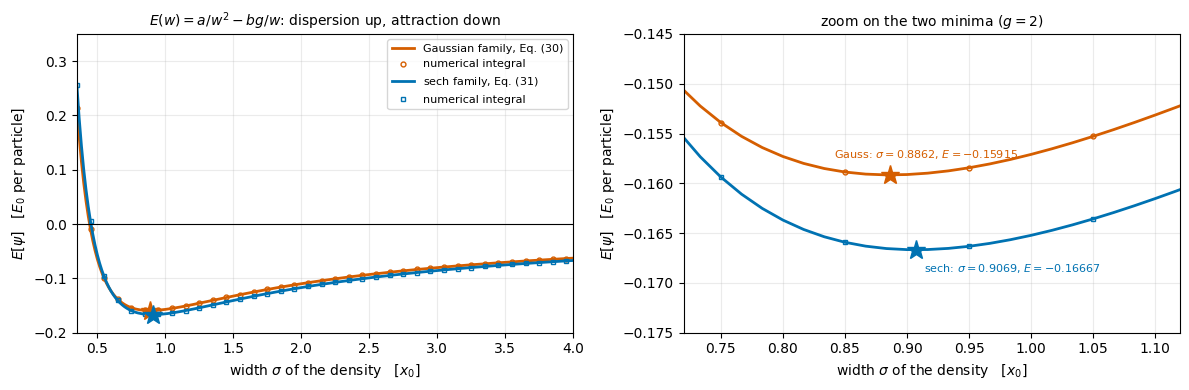


variational Gaussian : sigma* = sqrt(pi)/g   = 0.886227,  E = -g^2/(8 pi) = -0.15915494
exact sech           : sigma  = pi/(sqrt3 g) = 0.906900,  E = -g^2/24     = -0.16666667
ratios: E_G/E_S = 3/pi = 0.954930,  sigma_G/sigma_S = sqrt(3/pi) = 0.977205
overlap | <Gaussian(sigma*) | soliton> |  = 0.997206


In [9]:
# ==============================================================================
# FIGURE: the variational energy landscape  E(width), Gaussian family vs sech family
#   Both curves are computed TWICE: from the closed formulas (30)-(31) and by
#   numerically integrating Eq. (10) over the actual trial profile on the grid.
# ==============================================================================
def gaussian_packet(x, sigma, x_c=0.0, k_0=0.0):
    """Normalised Gaussian packet with an imprinted momentum -- notebook 00a, Eq. (3).

    MATH
        psi(x) = (2 pi sigma^2)^(-1/4) exp(-(x-x_c)^2 / (4 sigma^2)) exp(i k_0 x)
        |psi|^2 is a normal density of standard deviation sigma.
    """
    return ((2.0 * np.pi * sigma ** 2) ** -0.25
            * np.exp(-(x - x_c) ** 2 / (4.0 * sigma ** 2)) * np.exp(1j * k_0 * x)).astype(CDTYPE)


def sech_packet(x, w, x_c=0.0):
    """Normalised sech profile of width parameter w:  psi = (2w)^(-1/2) sech((x-x_c)/w)."""
    return ((2.0 * w) ** -0.5 / np.cosh(np.clip((x - x_c) / w, -700.0, 700.0))).astype(CDTYPE)


sig_scan = np.linspace(0.35, 4.0, 220)                      # rms width of the DENSITY, common x-axis
E_gauss_formula = 1.0 / (8.0 * sig_scan ** 2) - G / (4.0 * np.sqrt(np.pi) * sig_scan)
# a sech of rms width sigma has w = 2 sqrt(3) sigma / pi  (because Var = pi^2 w^2 / 12, Eq. (24))
w_of_sigma = 2.0 * np.sqrt(3.0) * sig_scan / np.pi
E_sech_formula = 1.0 / (6.0 * w_of_sigma ** 2) - G / (6.0 * w_of_sigma)
# the same two curves by brute-force numerical integration of Eq. (10)
E_gauss_grid = np.array([gp_energy(gaussian_packet(x, s), k, dx, G) for s in sig_scan])
E_sech_grid = np.array([gp_energy(sech_packet(x, w), k, dx, G) for w in w_of_sigma])

err_gauss = float(np.max(np.abs(E_gauss_formula - E_gauss_grid)))
err_sech = float(np.max(np.abs(E_sech_formula - E_sech_grid)))
narrow = sig_scan <= 2.0                                    # profiles whose tails fit comfortably on the ring
err_narrow = max(float(np.max(np.abs((E_gauss_formula - E_gauss_grid)[narrow]))),
                 float(np.max(np.abs((E_sech_formula - E_sech_grid)[narrow]))))
print(f"max | closed formula - numerical integration |: Gaussian {err_gauss:.2e}, sech {err_sech:.2e}")
print(f"   restricted to sigma <= 2 (tails that fit on L = {L:g}): {err_narrow:.2e}")
assert err_narrow < 1e-9, "Eqs. (30) and (31) must reproduce the grid integral of Eq. (10)"

sig_star_g, E_star_g = np.sqrt(np.pi) / G, -G ** 2 / (8 * np.pi)
sig_star_s, E_star_s = np.pi / (np.sqrt(3) * G), -G ** 2 / 24

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))
for ax, (lo, hi) in zip(axes, [(-0.20, 0.35), (-0.175, -0.145)]):
    ax.plot(sig_scan, E_gauss_formula, color=C_ANA, lw=2.0, label=r"Gaussian family, Eq. (30)")
    ax.plot(sig_scan[::6], E_gauss_grid[::6], "o", ms=3.5, color=C_ANA, mfc="none", label="numerical integral")
    ax.plot(sig_scan, E_sech_formula, color=C_NUM, lw=2.0, label=r"$\mathrm{sech}$ family, Eq. (31)")
    ax.plot(sig_scan[::6], E_sech_grid[::6], "s", ms=3.5, color=C_NUM, mfc="none", label="numerical integral")
    ax.plot([sig_star_g], [E_star_g], "*", ms=14, color=C_ANA, zorder=5)
    ax.plot([sig_star_s], [E_star_s], "*", ms=14, color=C_NUM, zorder=5)
    ax.axhline(0.0, color="k", lw=0.8)
    ax.set_xlabel(r"width $\sigma$ of the density   [$x_0$]")
    ax.set_ylabel(r"$E[\psi]$   [$E_0$ per particle]")
    ax.set_ylim(lo, hi)
    ax.grid(alpha=0.25)
axes[0].set_xlim(0.35, 4.0)
axes[0].legend(fontsize=8, loc="upper right")
axes[0].set_title(r"$E(w)=a/w^2-bg/w$: dispersion up, attraction down", fontsize=10)
axes[1].set_xlim(0.72, 1.12)
axes[1].set_title(rf"zoom on the two minima ($g={G:g}$)", fontsize=10)
axes[1].annotate(rf"sech: $\sigma={sig_star_s:.4f}$, $E={E_star_s:.5f}$", (sig_star_s, E_star_s),
                 textcoords="offset points", xytext=(6, -16), fontsize=8, color=C_NUM)
axes[1].annotate(rf"Gauss: $\sigma={sig_star_g:.4f}$, $E={E_star_g:.5f}$", (sig_star_g, E_star_g),
                 textcoords="offset points", xytext=(-40, 12), fontsize=8, color=C_ANA)
fig.tight_layout()
plt.show()

print(f"\nvariational Gaussian : sigma* = sqrt(pi)/g   = {sig_star_g:.6f},  E = -g^2/(8 pi) = {E_star_g:.8f}")
print(f"exact sech           : sigma  = pi/(sqrt3 g) = {sig_star_s:.6f},  E = -g^2/24     = {E_star_s:.8f}")
print(f"ratios: E_G/E_S = 3/pi = {E_star_g / E_star_s:.6f},  sigma_G/sigma_S = sqrt(3/pi) = "
      f"{sig_star_g / sig_star_s:.6f}")
ovl = abs(dx * np.sum(np.conj(gaussian_packet(x, sig_star_g)) * soliton_exact(x, g=G)))
print(f"overlap | <Gaussian(sigma*) | soliton> |  = {ovl:.6f}")

The left panel is Eq. (29) drawn twice: a steep positive wall at small width (kinetic energy, $1/w^{2}$) and a
slow approach to zero from below at large width (attraction, $-g/w$). Their sum has a minimum, and that
minimum is the soliton. Open circles and squares are the energy functional (10) integrated numerically over
the actual trial profiles; for every profile narrow enough to fit on the ring they lie on the closed formulas
to $3\times10^{-11}$, which is the check that Eqs. (30) and (31) were derived correctly. The
$\mathrm{sech}$ curve departs from its formula by $6\times10^{-8}$ at the widest trial width,
$\sigma = 4$, where its exponential tails no longer fit inside $L=60$ — the finite-ring effect quantified
in Section 8.3.

The right panel zooms on the two minima. The $\mathrm{sech}$ family reaches $-0.1667 = -g^{2}/24$ at
$\sigma = 0.9069$; the Gaussian family stops at $-0.1592 = -g^{2}/(8\pi)$ at $\sigma = 0.8862$. The best
Gaussian overlaps the true soliton by $0.9972$ — close, but Section 9.4 will show that the missing
$0.28\%$ is enough to make it breathe and radiate.

### 6.2 Why one dimension is safe and three dimensions are not

Repeat the scaling argument in $d$ dimensions. A normalised profile of width $w$ has
$\vert\psi\vert^{2}\sim w^{-d}$, and the interaction integral $\int\vert\psi\vert^{4}d^{d}x$ picks up
$w^{-2d}\cdot w^{d} = w^{-d}$, while the kinetic term is $w^{-2}$ in any dimension:

$$ E_d(w) \;\sim\; \frac{a}{w^{2}} \;-\; \frac{b\,g}{w^{d}} . $$

* $d=1$: the attraction, $w^{-1}$, is *weaker* than the kinetic repulsion at small $w$. A minimum exists at
  finite $w$ for every $g>0$. Solitons are stable, always.
* $d=2$: both terms scale as $w^{-2}$, so $E_2(w) = (a-bg)/w^{2}$ and the sign of $a-bg$ decides everything.
  For $g$ below the critical value $a/b$ the energy is positive and decreases towards zero as the cloud
  expands, so the minimiser runs off to $w=\infty$; above it the energy is negative and runs to $-\infty$ as
  $w\to0$. There is no stable width at any $g$ — the *critical* case, which is why two-dimensional attractive
  condensates are a delicate subject.
* $d=3$: the attraction, $w^{-3}$, *beats* the kinetic term at small $w$, so $E\to-\infty$ as $w\to0$ for
  **every** $g>0$: in free space a three-dimensional attractive condensate has no ground state at all. What
  produces a *critical atom number* is the trap that holds the cloud. Adding a harmonic trap of frequency
  $\omega$ contributes $+c\,\omega^{2}w^{2}$, and
  $E(w) = a/w^{2} - bg/w^{3} + c\omega^{2}w^{2}$ has a local minimum at moderate $w$ — a metastable
  condensate — separated by a barrier from the collapse at $w\to0$. Increasing $g$, i.e. increasing $N$,
  lowers the barrier; at a critical $N$ the local minimum and the barrier merge and disappear, and nothing
  stops the cloud from shrinking. The implosion, and the burst of atoms that escapes from it, was observed in
  $^{85}$Rb (Donley *et al.*, Nature **412**, 295 (2001)) and is called a **Bosenova**.

This is the reason every bright-soliton experiment starts by squeezing the gas into a waveguide: one
dimension is the only dimension in which an attractive condensate has a ground state. Section 6.8 returns to
the price of doing so in a real, three-dimensional trap.

### 6.3 A one-parameter family, and $\mu = dE/dN$

Equation (25) is a family labelled by the single combination $ng$, i.e. by the number of atoms in the
soliton:

| quantity | scaling | in the physical units of Section 3 |
|---|---|---|
| width | $2/(ng)$ | $\propto 1/N$ |
| peak amplitude | $n\sqrt g/2$ | $\propto N$ |
| peak density | $n^{2}g/4$ | $\propto N^{2}$ |
| chemical potential | $-(ng)^{2}/8$ | $\propto N^{2}$ |
| energy per particle | $-(ng)^{2}/24$ | $\propto N^{2}$ |
| total energy | $n\cdot\left[-(ng)^{2}/24\right]$ | $\propto N^{3}$ |

More atoms means a narrower, taller, more deeply bound soliton, and the total energy falls as $N^{3}$. The
state is **self-bound**: $\mu = -g^{2}/8 < 0$ means that removing one atom to rest at infinity costs energy
$g^{2}/8$, so the soliton holds itself together with no external trap. It is its own container.

The two energies of Section 4.5 are now related through the particle number. Restore the physical total energy of the
cloud: by the unit table of Section 3.4, $E_{\rm tot} = N E_0\,E[\psi]$, and $g = cN$ with
$c = \vert g_{\rm 1D}\vert m x_0/\hbar^{2}$ fixed. Hence

$$ E_{\rm tot}(N) \;=\; N E_0\left(-\frac{c^{2}N^{2}}{24}\right) = -\frac{E_0c^{2}N^{3}}{24}
   \qquad\Longrightarrow\qquad
   \frac{dE_{\rm tot}}{dN} = -\frac{E_0c^{2}N^{2}}{8} = -E_0\frac{g^{2}}{8} = E_0\,\mu . \tag{32} $$

The chemical potential is the energy cost of adding one particle to the ground state — and it is the
Lagrange multiplier that appeared in Eq. (5) precisely because it multiplies the constraint on $N$. The cell
below checks Eq. (32) in two independent ways: by automatic differentiation of the closed-form
$E_{\rm tot}(N)$, and by finite-differencing the *numerically integrated* energy of the exact profile.

> **JAX practice.** `jax.grad(f)` returns a new function that computes the exact derivative of `f` by
> differentiating the operations `f` performs, not by taking finite differences — no step size, no truncation
> error. It is the tool that makes variational optimisation practical later in this course; see
> [01 — JAX from scratch](01_jax_from_scratch.ipynb).

In [10]:
# ==============================================================================
# CHECKPOINT 3: mu = d E_tot / dN,  three ways
#   (a) jax.grad of the closed form  E_tot(N) = -c^2 N^3 / 24   (units of E_0)
#   (b) finite difference of  g -> g * E_numeric(g), with E_numeric integrated on the grid
#   (c) mu = <H_GP> on the exact profile        (already used in Checkpoint 1)
#   Choosing units with c = 1 makes g = N, so d/dN and d/dg are the same derivative.
# ==============================================================================
def total_energy_closed(N_atoms):
    """E_tot(N) / E_0 for a bright soliton, in units where g = N  (i.e. c = 1).

    MATH
        E_tot = N * E[psi] = N * (-g^2/24) = -N^3/24
    """
    return -N_atoms ** 3 / 24.0


mu_autodiff = float(jax.grad(total_energy_closed)(G))          # d E_tot / dN at N = g = G

h_g = 1e-4                                                     # finite-difference step in N = g
def total_energy_grid(g_val):
    """E_tot/E_0 = g * (energy per particle, integrated numerically over the exact profile)."""
    return g_val * gp_energy(soliton_exact(x, g=g_val), k, dx, g_val)

mu_fd = (total_energy_grid(G + h_g) - total_energy_grid(G - h_g)) / (2 * h_g)
mu_expect = gp_chemical_potential(soliton_exact(x, g=G), k, dx, G)

print(f"(a) jax.grad  of the closed form   : dE_tot/dN = {mu_autodiff:.12f}")
print(f"(b) finite difference of the grid E: dE_tot/dN = {mu_fd:.12f}   (h = {h_g:g})")
print(f"(c) mu = <H_GP> on the exact sech  : mu        = {mu_expect:.12f}")
print(f"    analytic -g^2/8                            = {-G ** 2 / 8:.12f}")
assert abs(mu_autodiff + G ** 2 / 8) < 1e4 * TOL
assert abs(mu_fd - mu_expect) < 1e-7, "finite-difference dE/dN must reproduce <H_GP>"
print("CHECKPOINT 3 passed: Eq. (32) holds.")

# a second, sharper statement of the same physics: the family scalings of the table above
print("\n  n g      width 2/(ng)   peak ampl.   mu = -(ng)^2/8    measured mu     measured width")
for n_frac in (0.5, 1.0, 2.0):
    psi_n = soliton_exact(x, g=G, n=n_frac)
    psi_n_normalised = psi_n / np.sqrt(grid_norm(psi_n, dx))
    mu_meas = gp_chemical_potential(psi_n, k, dx, G) / grid_norm(psi_n, dx)
    w_predicted = 2.0 / (n_frac * G)
    # width read off the profile: sech(kappa d) = sech(1) at the distance d = 1/kappa = 2/(n g)
    i_peak = int(np.argmax(np.abs(psi_n)))
    prof = np.abs(psi_n)[i_peak:] / np.abs(psi_n)[i_peak]        # right half, monotonically decreasing
    j_cross = int(np.argmax(prof < 1.0 / np.cosh(1.0)))           # first sample below sech(1)
    w_meas = float(np.interp(1.0 / np.cosh(1.0), [prof[j_cross], prof[j_cross - 1]],
                             [x[i_peak + j_cross] - x[i_peak], x[i_peak + j_cross - 1] - x[i_peak]]))
    print(f"{n_frac * G:5.2f}   {w_predicted:12.6f} {n_frac * np.sqrt(G) / 2:12.6f} "
          f"{-(n_frac * G) ** 2 / 8:16.8f} {mu_meas:15.8f} {w_meas:18.6f}")

(a) jax.grad  of the closed form   : dE_tot/dN = -0.500000000000
(b) finite difference of the grid E: dE_tot/dN = -0.500000000418   (h = 0.0001)
(c) mu = <H_GP> on the exact sech  : mu        = -0.500000000000
    analytic -g^2/8                            = -0.500000000000
CHECKPOINT 3 passed: Eq. (32) holds.

  n g      width 2/(ng)   peak ampl.   mu = -(ng)^2/8    measured mu     measured width
 1.00       2.000000     0.353553      -0.12500000     -0.12500000           2.000050
 2.00       1.000000     0.707107      -0.50000000     -0.50000000           1.000350
 4.00       0.500000     1.414214      -2.00000000     -2.00000000           0.500704


All three routes to $\mu$ agree: automatic differentiation of $-N^{3}/24$, a finite difference of the grid
energy, and the expectation value $\langle \hat H_{\rm GP}\rangle$ all return $-0.5 = -g^{2}/8$ for $g=2$.
The table underneath shows the family: doubling $ng$ halves the width, doubles the amplitude and quadruples
$\vert\mu\vert$, and the measured width column — the distance from the peak at which the profile has fallen
to $\mathrm{sech}(1) = 0.6481$ of its maximum, obtained by interpolating between grid points — reproduces
$2/(ng)$ to four digits.

### 6.4 A soliton is a particle

Equation (26) says the soliton translates rigidly at velocity $k_0$, and Eq. (28) says its energy is

$$ E \;=\; \underbrace{-\frac{g^{2}}{24}}_{\text{internal}} \;+\; \underbrace{\frac{k_0^{2}}{2}}_{\text{motion}} ,
   \qquad \langle p\rangle = k_0 , $$

which is the energy of a particle of unit mass moving at velocity $k_0$, plus a constant internal energy. In
physical units the mass is $Nm$: the whole cloud moves as one object. Combined with Ehrenfest's relation (14)
and $d\langle p\rangle/dt = 0$, the centre of mass obeys Newton's first law exactly — not approximately, and
not only on average, since the shape never changes.

The reason is Galilean invariance, and the reason *that* holds is that the nonlinearity depends only on
$\vert\psi\vert^{2}$, which no phase factor can touch. Adding an external potential breaks the invariance and
the soliton then accelerates like a particle in that potential, which is what Strecker et al. observed when
their solitons oscillated in a shallow axial trap (Exercise 1).

### 6.5 What the mean field hides: translational symmetry

Equation (8) is invariant under $x\to x+x_c$, yet its solution (22) is localised at one particular $x_c$ and
therefore is *not* invariant. This is spontaneous symmetry breaking inside a variational ansatz, and it has a
concrete consequence: the family of solitons at all $x_c$ is degenerate, so the solution of an imaginary-time
relaxation is determined entirely by where the initial guess happened to sit (Section 8.6 demonstrates this).

The many-body statement is sharper, and it is a genuine failure of the mean field rather than a technicality.
The exact ground state of the $N$-boson Hamiltonian (2) with no external potential is an eigenstate of the
total momentum and is therefore **translationally invariant**: the density of the exact ground state is
uniform. What is localised is the *relative* wave function; the centre of mass of the soliton is completely
delocalised, exactly as the centre of mass of a hydrogen atom in free space is. The Hartree product (3)
cannot represent "localised internal structure with a delocalised centre of mass", so it localises everything
and produces a density profile that the exact ground state does not have. Lai and Haus constructed the
corresponding exact quantum states, by Bethe ansatz, for the quantum nonlinear Schrödinger model of solitons in
optical fibres, which is the attractive one-dimensional Bose gas (Phys. Rev. A **40**, 844 and 854 (1989)): superposing their momentum eigenstates with a wave packet in the total momentum recovers a
localised density, which then slowly spreads — a dispersive spreading of the centre of mass, as for a free
particle of mass $Nm$, that the Gross-Pitaevskii equation does not contain. For $N\sim10^{3}$ atoms over a few hundred milliseconds that spreading is negligible, which
is why Eq. (8) describes the experiments; it is not negligible in principle.

### 6.6 Robustness, and integrability

A linear wave packet has no preferred shape: every initial condition spreads, and the spreading depends on
which one you started from. The soliton is different. Start from a profile that is *close* to Eq. (22) and
the state does not drift away: it oscillates about the soliton, sheds the mismatch as small-amplitude
radiation that runs off, and settles onto a soliton. The soliton is an attractor of nearby initial
conditions, in a system with no dissipation at all — the "dissipation" is radiation carrying the excess away
from the core. Section 9.4 measures this for a Gaussian whose overlap with the soliton is $0.9972$.

The deeper reason is that Eq. (8) is **integrable**. Zakharov and Shabat showed in 1972 (Sov. Phys. JETP
**34**, 62) that the nonlinear Schrödinger equation can be solved exactly by inverse scattering: one maps the
initial condition to the scattering data of an auxiliary linear operator, evolves the scattering data
trivially, and maps back. The equation possesses infinitely many independent conserved quantities — the norm,
the momentum and the energy are only the first three — and its solutions decompose into solitons plus
radiation, with the soliton content fixed for all time by the initial condition. That is why a perturbed
soliton relaxes back to *a* soliton rather than to something else, and why two solitons pass through each
other unchanged.

### 6.7 Where solitons matter

**Optical fibres.** Because Eq. (8) also governs a pulse envelope in a Kerr medium (Section 2.4), a light
pulse of the right shape and peak power propagates down a fibre without broadening. Soliton transmission was
proposed as the way to beat dispersion in long-haul communication, and soliton and dispersion-managed
soliton systems were built and deployed; Agrawal's *Nonlinear Fiber Optics* (Chapter 5) gives the account.

**Matter-wave interferometry.** A soliton is a self-trapped, dispersionless, coherent matter wave, which
makes it attractive as the moving arm of an atom interferometer: splitting, reflecting and recombining a
soliton on a barrier keeps the packet compact for the whole interrogation time instead of letting it
disperse. The stability of the soliton is doing work that a trap would otherwise have to do.

**Soliton trains and modulational instability.** A uniform attractive condensate is unstable against
long-wavelength density modulations: a small ripple grows because the region of higher density attracts more
atoms. The instability breaks the cloud into a regular array of solitons. Strecker et al. proposed it as the
origin of their train in 2002, and Nguyen, Luo and Hulet characterised its role in train formation in 2017
(Science **356**, 422). The same instability, with the same equation, turns a continuous-wave laser beam in a fibre
into a train of pulses.

### 6.8 Limits of validity of the one-dimensional description

Three assumptions were made, and each has a number attached.

1. **Quasi-one-dimensionality.** Reducing three dimensions to one requires every atom to stay in the
   transverse ground state, which needs the soliton to be longer than it is wide: $\ell \gg a_\perp$, i.e.
   $\kappa = N\vert a_s\vert/a_\perp = a_\perp/\ell \ll 1$. The cell in Section 3.5 measured $\kappa = 0.66$
   and $0.60$ for the two experiments — order one, not small.
2. **No collapse.** The three-dimensional character reasserts itself when the soliton becomes narrow enough
   to feel the transverse degree of freedom, and then Section 6.2 applies: the cloud collapses. Numerical
   solutions of the full three-dimensional Gross-Pitaevskii equation in a waveguide put the threshold at
   $\kappa_c = 0.675\pm0.005$ (Parker, Cornish, Adams and Martin, J. Phys. B **40**, 3127 (2007)), in
   agreement with the analytic value $2/3$ that Salasnich, Parola and Reatto obtained (Phys. Rev. A **66**,
   043603 (2002)) from their non-polynomial Schrödinger equation (Phys. Rev. A **65**, 043614 (2002)). Both 2002 experiments therefore ran
   close to a genuine instability, which is why they could not simply increase $N$ to make the soliton more
   one-dimensional: that is the direction in which it explodes. How close is a question the experiments
   themselves cannot answer sharply, because $\kappa$ is linear in the atom number and $N$ is the least
   precisely known quantity in the table. Khaykovich et al. measure $N = 6(2)\times10^{3}$, whose central
   value gives $\kappa = 0.88$ — *above* $\kappa_c$ — while their own stability estimate,
   $4.2$–$5.2\times10^{3}$, gives $\kappa = 0.62$–$0.77$. The parameters used here, $N = 4.5\times10^{3}$,
   sit inside that window. The lesson is not that the experiment was unstable but that it operated at
   $\kappa$ of order $\kappa_c$, and that the number which decides stability is the one with the largest
   error bar.
3. **Mean field.** Sections 2.3 and 6.5 listed what the Hartree product omits: quantum depletion, atoms
   outside the condensate mode, and the delocalisation of the centre of mass.

The cell below turns points 1 and 2 into numbers for the two experiments.

In [11]:
# ==============================================================================
# CHECKPOINT 4: how close were the 2002 experiments to the collapse threshold?
#   kappa = N |a_s| / a_perp = a_perp / ell     (quasi-1D parameter)
#   kappa_c = 0.675 +/- 0.005                   (Parker et al. 2007, 3D GP numerics)
# ==============================================================================
KAPPA_C = 0.675

print(f"{'experiment':24s} {'kappa':>8s} {'kappa/kappa_c':>14s} {'ell/a_perp':>12s} {'N_c':>8s}")
for name, N_at, a_s, nu in experiments:
    u = soliton_units(N_at, a_s, nu)
    n_crit = KAPPA_C * u["a_perp"] / abs(a_s)
    print(f"{name:24s} {u['kappa']:8.3f} {u['kappa'] / KAPPA_C:14.3f} {1 / u['kappa']:12.3f} {n_crit:8.0f}")
    assert u["kappa"] < KAPPA_C, "a published soliton must sit below the collapse threshold"
print("\nCHECKPOINT 4 passed: both experiments sit below kappa_c = 0.675, but not by much.")

# how sensitive is that verdict to the atom number?  kappa is LINEAR in N, and N carries the largest
# experimental error bar of the three inputs -- so the margin below kappa_c is only as good as N.
print("\nsensitivity to N (Khaykovich et al.: measured 6(2)e3, stability estimate 4.2-5.2e3):")
for N_try in (4200, 4500, 5200, 6000, 8000):
    print(f"    N = {N_try:5d}  ->  kappa = {soliton_units(N_try, -0.21e-9, 710.0)['kappa']:.3f}"
          f"   ({'below' if soliton_units(N_try, -0.21e-9, 710.0)['kappa'] < KAPPA_C else 'ABOVE'} kappa_c)")

experiment                  kappa  kappa/kappa_c   ell/a_perp      N_c
Khaykovich et al. 2002      0.663          0.983        1.507     4579
Strecker et al. 2002        0.596          0.883        1.677     5661

CHECKPOINT 4 passed: both experiments sit below kappa_c = 0.675, but not by much.

sensitivity to N (Khaykovich et al.: measured 6(2)e3, stability estimate 4.2-5.2e3):
    N =  4200  ->  kappa = 0.619   (below kappa_c)
    N =  4500  ->  kappa = 0.663   (below kappa_c)
    N =  5200  ->  kappa = 0.767   (ABOVE kappa_c)
    N =  6000  ->  kappa = 0.885   (ABOVE kappa_c)
    N =  8000  ->  kappa = 1.179   (ABOVE kappa_c)


## 7. Imaginary-time evolution

### 7.1 The question

Notebook 00b found the ground state of a harmonic trap by building the Hamiltonian as a tridiagonal matrix and
handing it to an eigensolver. That route is closed here for two independent reasons.

* $\hat H_{\rm GP}[\psi]$ depends on $\psi$. There is no fixed matrix to diagonalise; the "eigenvalue
  problem" (15) is nonlinear and an eigensolver has nothing to work on.
* Even for a linear problem, diagonalisation costs $O(M^{3})$ time and $O(M^{2})$ memory for a Hilbert space
  of dimension $M$. For a grid of $512$ points that is nothing; for the many-body Hilbert spaces of the later
  chapters, where $M = 2^{20}$, it is impossible.

What follows is the standard replacement, and it needs nothing but the ability to *apply* $\hat H$ to a state.

### 7.2 The linear argument

Take a linear Hamiltonian $\hat H$ with eigenstates $\phi_n$ and energies $E_0 \le E_1 \le E_2 \le\ldots$, and
expand an arbitrary initial state,

$$ \psi(0) \;=\; \sum_n c_n\,\phi_n \qquad\Longrightarrow\qquad
   \psi(t) \;=\; \sum_n c_n\,e^{-iE_nt}\,\phi_n . $$

Every coefficient rotates; none decays; the state never settles. Now substitute

$$ t \;=\; -i\tau , \qquad \tau\in\mathbb{R},\ \tau>0 , $$

so that $e^{-iE_nt} = e^{-iE_n(-i\tau)} = e^{-E_n\tau}$ and

$$ \psi(\tau) \;=\; \sum_n c_n\,e^{-E_n\tau}\,\phi_n
   \;=\; e^{-E_0\tau}\left[c_0\phi_0 \;+\; \sum_{n\ge1}c_n\,e^{-(E_n-E_0)\tau}\,\phi_n\right] . \tag{33} $$

The bracket is the whole argument. Every excited component is suppressed *relative to the ground state* by
$e^{-(E_n-E_0)\tau}$, and $E_n - E_0 > 0$ for every $n$ with $E_n > E_0$. The prefactor $e^{-E_0\tau}$ changes
the norm — it shrinks it if $E_0>0$, and *grows* it if $E_0<0$, which is the case for our soliton — but it is
a common factor and carries no information about the shape. Divide it out:

$$ \frac{\psi(\tau)}{\Vert\psi(\tau)\Vert} \;\xrightarrow[\tau\to\infty]{}\; \frac{\phi_0}{\Vert\phi_0\Vert}
   \qquad\text{provided } c_0 = \langle\phi_0\vert\psi(0)\rangle \ne 0 . \tag{34} $$

Three statements follow, and each is checked below.

1. **Renormalise at every step.** Not because the physics requires it, but because otherwise the numbers in
   the array run away exponentially. For the nonlinear problem there is a second reason: $g\vert\psi\vert^{2}$
   is only the physical interaction if $\Vert\psi\Vert = 1$.
2. **The convergence rate is the gap.** The slowest-decaying contamination is the lowest excited state with
   $c_n\ne0$, so the error falls as $e^{-(E_1-E_0)\tau}$: a straight line on a semi-logarithmic plot, of
   measurable slope.
3. **You get the lowest state with non-zero overlap**, not necessarily the ground state. If a symmetry makes
   $c_0$ vanish exactly, the method converges to the lowest state in the symmetry sector of the initial guess.

### 7.3 The algorithm: Strang splitting of $e^{-\hat H\Delta\tau}$

Applying $e^{-\hat H\Delta\tau}$ requires a decision, because $\hat H = \hat T + \hat W$ is a sum of two pieces
that are easy separately and hard together:

$$ \hat T = -\frac{1}{2}\frac{\partial^{2}}{\partial x^{2}} \quad\text{(diagonal in Fourier space)}, \qquad
   \hat W = V(x) - g\vert\psi\vert^{2} \quad\text{(diagonal in position space)} . $$

They do not commute, so $e^{-(\hat T+\hat W)h} \ne e^{-\hat Th}e^{-\hat Wh}$. Expanding both sides to second
order,

$$ \begin{aligned}
   e^{-\hat Th}e^{-\hat Wh} &= 1 - h(\hat T+\hat W)
      + \frac{h^{2}}{2}\left(\hat T^{2} + 2\hat T\hat W + \hat W^{2}\right) + O(h^{3}) , \\
   e^{-(\hat T+\hat W)h} &= 1 - h(\hat T+\hat W)
      + \frac{h^{2}}{2}\left(\hat T^{2} + \hat T\hat W + \hat W\hat T + \hat W^{2}\right) + O(h^{3}) ,
   \end{aligned} $$

so the difference is $\tfrac{h^{2}}{2}[\hat T,\hat W]$: the naive product is accurate only to first order in
$h$ per step. The cure is to symmetrise. Define the **Strang** product

$$ S(h) \;\equiv\; e^{-\hat Th/2}\;e^{-\hat Wh}\;e^{-\hat Th/2} . \tag{35} $$

Its error is one order better, and the proof needs no algebra at all. Reversing the sign of $h$ reverses every
factor and the order of the product is symmetric, so

$$ S(h)\,S(-h) = e^{-\hat Th/2}e^{-\hat Wh}e^{-\hat Th/2}\;e^{+\hat Th/2}e^{+\hat Wh}e^{+\hat Th/2} = 1 . $$

Writing $S(h) = e^{-h\hat G(h)}$, this says $\hat G(-h) = \hat G(h)$: the generator is an *even* function of
$h$, so it contains no $h^{1}$ term,

$$ \hat G(h) \;=\; \hat T + \hat W + h^{2}\hat C_2 + O(h^{4}) . \tag{36} $$

The error per step is therefore $O(h^{3})$, and over $\tau/h$ steps the accumulated error is $O(h^{2})$. The
same $S(h)$ with $h\to i\,\Delta t$ is the real-time propagator of Section 9, where each of the three factors
is separately unitary.

In practice the three factors are three lines of code:

$$ \psi \;\to\; \mathrm{IFFT}\left[e^{-k^{2}h/4}\,\mathrm{FFT}[\psi]\right] \;\to\;
   \psi\,e^{\left(g\vert\psi\vert^{2}-V\right)h} \;\to\;
   \mathrm{IFFT}\left[e^{-k^{2}h/4}\,\mathrm{FFT}[\psi]\right] \;\to\; \frac{\psi}{\Vert\psi\Vert} . \tag{37} $$

The exponent of the kinetic half-step is $-\tfrac{k^{2}}{2}\cdot\tfrac{h}{2} = -k^{2}h/4$; the sign in the
middle factor is positive for $g>0$ because attraction *lowers* the energy and imaginary time amplifies
whatever lowers the energy.

In [12]:
# ==============================================================================
# STEP 3: imaginary-time propagation by Strang split-step  -- Eq. (37)
#   One scan body, two entry points:
#     imaginary_time_ground_state : run n_steps and return the final state + the norm of each step
#     imaginary_time_frames       : the same, but keep a snapshot every n_inner steps (for movies)
# ==============================================================================
def _imag_step_factory(k, dx, g, V, dtau):
    """Build the one-step map of Eq. (37) for fixed parameters (used by both entry points)."""
    exp_kin = jnp.exp(-0.25 * k ** 2 * dtau)             # exp(-(k^2/2)(dtau/2)), the kinetic HALF step

    def step(psi, _):
        psi = jnp.fft.ifft(exp_kin * jnp.fft.fft(psi))               # kinetic half step
        psi = psi * jnp.exp((g * jnp.abs(psi) ** 2 - V) * dtau)      # nonlinear + potential full step
        psi = jnp.fft.ifft(exp_kin * jnp.fft.fft(psi))               # kinetic half step
        nrm = jnp.sqrt(dx * jnp.sum(jnp.abs(psi) ** 2))              # imaginary time does NOT conserve the norm
        return psi / nrm, nrm                                        # (carry, per-step norm)
    return step


@partial(jax.jit, static_argnames=("n_steps",))
def imaginary_time_ground_state(psi, k, dx, g, V, dtau, n_steps):
    """Relax psi towards the lowest state of H_GP by n_steps of Eq. (37).

    MATH
        psi <- N[ exp(-T dtau/2) exp(-W dtau) exp(-T dtau/2) psi ],  W = V - g|psi|^2
    RETURNS
        (psi, norms) with norms[j] = || psi ||  BEFORE the renormalisation of step j.
        Section 7.9 reads the chemical potential off those norms.
    COST
        2 FFTs of length N_x per step, i.e. O(N_x log N_x); memory O(N_x).
    JAX
        lax.scan compiles the loop body ONCE instead of unrolling n_steps copies of it.
    """
    return lax.scan(_imag_step_factory(k, dx, g, V, dtau), psi, None, length=n_steps)


@partial(jax.jit, static_argnames=("n_inner", "n_frames"))
def imaginary_time_frames(psi, k, dx, g, V, dtau, n_inner, n_frames):
    """Same relaxation, keeping a snapshot every n_inner steps. Shape (n_frames+1, N_x), frame 0 = input."""
    step = _imag_step_factory(k, dx, g, V, dtau)

    def outer(psi, _):
        psi, _ = lax.scan(step, psi, None, length=n_inner)
        return psi, psi

    _, frames = lax.scan(outer, psi, None, length=n_frames)
    return jnp.concatenate([psi[None, :], frames], axis=0)


print("STEP 3: imaginary_time_ground_state and imaginary_time_frames compiled on first call.")

STEP 3: imaginary_time_ground_state and imaginary_time_frames compiled on first call.


> **JAX practice.** `jax.jit` compiles a Python function once, for the shapes of its arguments, into a single
> fused program; `lax.scan(body, init, xs, length=n)` is a compiled `for` loop that carries a state forward
> and collects one output per iteration. Marking `n_steps` as a *static* argument tells the compiler that this
> number is known at compile time, which it must be for `scan` to fix the loop length; changing it triggers a
> recompilation. Both are explained in [01 — JAX from scratch](01_jax_from_scratch.ipynb).

### 7.4 Demonstration 1: the convergence rate is the gap

The place to test the machinery is the problem of notebook 00b, where every answer is known: the harmonic
oscillator $V(x) = x^{2}/2$, with $E_n = n+\tfrac12$, ground state $\phi_0 = \pi^{-1/4}e^{-x^{2}/2}$, and a
gap $E_1-E_0 = 1$. Setting $g = 0$ in Eq. (37) makes it a purely linear calculation.

The initial guess is a Gaussian of the wrong width placed **off centre**, so that it has non-zero overlap
with every eigenstate. Equation (33) then predicts

$$ \left\Vert \frac{\psi(\tau)}{\Vert\psi(\tau)\Vert} - \phi_0 \right\Vert \;\propto\; e^{-(E_1-E_0)\tau}
   \;=\; e^{-\tau} , $$

a straight line of slope $-1$ on a semi-logarithmic plot. If instead the guess is placed **at the centre**,
parity makes $c_1 = c_3 = \ldots = 0$ exactly, the slowest surviving contamination is $\phi_2$, and the slope
must be $-(E_2-E_0) = -2$.

In [13]:
# ==============================================================================
# PARAMETERS for the linear harmonic-oscillator demonstrations of Section 7
# ==============================================================================
L_HO, N_HO = 24.0, 256
x_ho, k_ho, dx_ho = make_grid(L_HO, N_HO)
V_HO = jnp.asarray(0.5 * x_ho ** 2)                    # the trap of notebook 00b, in its own units
k_ho_j = jnp.asarray(k_ho)
V_HO_np = np.asarray(V_HO)

DTAU_HO = 0.005                                        # small enough that the splitting bias is invisible here
phi0_ho = (np.pi ** -0.25) * np.exp(-x_ho ** 2 / 2)    # exact ground state
phi1_ho = np.sqrt(2.0) * (np.pi ** -0.25) * x_ho * np.exp(-x_ho ** 2 / 2)
phi2_ho = (np.pi ** -0.25) / np.sqrt(2.0) * (2 * x_ho ** 2 - 1) * np.exp(-x_ho ** 2 / 2)

print(f"harmonic-oscillator grid: L = {L_HO}, N_x = {N_HO}, dx = {dx_ho:.5f}, dtau = {DTAU_HO}")
print(f"exact levels E_n = n + 1/2; gap E_1 - E_0 = 1, E_2 - E_0 = 2")

harmonic-oscillator grid: L = 24.0, N_x = 256, dx = 0.09375, dtau = 0.005
exact levels E_n = n + 1/2; gap E_1 - E_0 = 1, E_2 - E_0 = 2


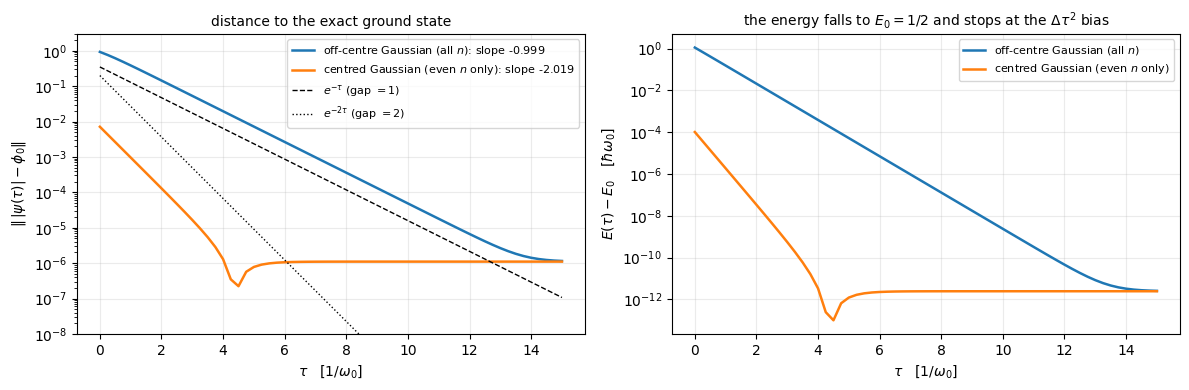

off-centre Gaussian (all $n$)        fitted decay rate = -0.9990
centred Gaussian (even $n$ only)     fitted decay rate = -2.0193
plateau of the state error at tau = 15: 1.15e-06 and 1.10e-06
plateau of the energy error                : 2.55e-12 and 2.44e-12   (the O(dtau^2) bias at dtau = 0.005)

CHECKPOINT 5 passed: the imaginary-time convergence rate is the spectral gap.


In [14]:
# ==============================================================================
# DEMONSTRATION 1: the error decays at the rate of the gap
# ==============================================================================
TAU_STEP, N_TAU = 0.25, 60                             # snapshots every 0.25 up to tau = 15
n_inner_ho = int(round(TAU_STEP / DTAU_HO))
taus_ho = np.arange(N_TAU + 1) * TAU_STEP

guesses = {"off-centre Gaussian (all $n$)": gaussian_packet(x_ho, 0.7, x_c=1.5),
           "centred Gaussian (even $n$ only)": gaussian_packet(x_ho, 0.7, x_c=0.0)}

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))
fit_slopes, errs_final, ens_final = {}, {}, {}
for label, psi_start in guesses.items():
    psi_start = jnp.asarray(normalise(psi_start, dx_ho))
    frames = np.asarray(imaginary_time_frames(psi_start, k_ho_j, dx_ho, 0.0, V_HO,
                                              DTAU_HO, n_inner_ho, N_TAU))
    # global phase is irrelevant: compare the amplitudes
    errs = np.array([np.sqrt(dx_ho * np.sum((np.abs(f) - phi0_ho) ** 2)) for f in frames])
    ens = np.array([gp_energy(f, k_ho, dx_ho, 0.0, V_HO_np) for f in frames])
    # fit only where the error is still falling: below ~100 times its own floor the curve is
    # dominated by the O(dtau^2) bias of the splitting, not by the spectral gap (Section 8.2)
    window = (taus_ho >= 1.0) & (errs > 100.0 * errs.min())
    slope = np.polyfit(taus_ho[window], np.log(errs[window]), 1)[0]
    fit_slopes[label], errs_final[label], ens_final[label] = slope, errs[-1], ens[-1] - 0.5
    axes[0].semilogy(taus_ho, errs, lw=1.8, label=f"{label}: slope {slope:.3f}")
    axes[1].plot(taus_ho, ens - 0.5, lw=1.8, label=label)

axes[0].semilogy(taus_ho, 0.35 * np.exp(-taus_ho), "k--", lw=1.0, label=r"$e^{-\tau}$ (gap $=1$)")
axes[0].semilogy(taus_ho, 0.20 * np.exp(-2 * taus_ho), "k:", lw=1.0, label=r"$e^{-2\tau}$ (gap $=2$)")
axes[0].set_xlabel(r"$\tau$   [$1/\omega_0$]"), axes[0].set_ylabel(r"$\Vert\,|\psi(\tau)|-\phi_0\Vert$")
axes[0].set_ylim(1e-8, 3), axes[0].grid(alpha=0.25), axes[0].legend(fontsize=8)
axes[0].set_title("distance to the exact ground state", fontsize=10)
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\tau$   [$1/\omega_0$]"), axes[1].set_ylabel(r"$E(\tau)-E_0$   [$\hbar\omega_0$]")
axes[1].grid(alpha=0.25), axes[1].legend(fontsize=8)
axes[1].set_title(r"the energy falls to $E_0=1/2$ and stops at the $\Delta\tau^2$ bias", fontsize=10)
fig.tight_layout()
plt.show()

for label, slope in fit_slopes.items():
    print(f"{label:36s} fitted decay rate = {slope:7.4f}")
print(f"plateau of the state error at tau = {taus_ho[-1]:g}: {errs_final['off-centre Gaussian (all $n$)']:.2e} "
      f"and {errs_final['centred Gaussian (even $n$ only)']:.2e}")
print(f"plateau of the energy error                : {ens_final['off-centre Gaussian (all $n$)']:.2e} "
      f"and {ens_final['centred Gaussian (even $n$ only)']:.2e}   (the O(dtau^2) bias at dtau = {DTAU_HO})")
assert abs(fit_slopes["off-centre Gaussian (all $n$)"] + 1.0) < 0.02, "rate must equal the gap E_1 - E_0 = 1"
assert abs(fit_slopes["centred Gaussian (even $n$ only)"] + 2.0) < 0.05, "parity doubles the rate"
print("\nCHECKPOINT 5 passed: the imaginary-time convergence rate is the spectral gap.")

The off-centre guess decays with fitted rate $-0.999$; the predicted rate is $-(E_1-E_0) = -1$. The centred
guess decays at $-2.02$ against the predicted $-(E_2-E_0) = -2$ — parity removes every odd eigenstate from
the expansion, so the first surviving contamination is $\phi_2$ and the convergence is twice as fast.

Both curves stop on a plateau at $1.1\times10^{-6}$ rather than continuing to zero. That plateau is *not* a
failure of the argument: it is the $O(\Delta\tau^{2})$ bias of the split-step map at $\Delta\tau = 0.005$,
and Section 8.2 measures it. The fit window above therefore excludes everything within a factor $100$ of it;
fitting through the plateau would return a meaningless slope.

The right panel shows the energy falling towards $E_0 = 1/2$, as Section 7.7 will show it must. Its plateau
is at $2.5\times10^{-12}$, six orders below the plateau of the *state*, which is the variational effect that
Section 8.2 explains: an error $\varepsilon$ in the state costs only $O(\varepsilon^{2})$ in the energy.

The centred guess starts much closer to $\phi_0$ than the off-centre one, and its energy curve does something
the monotonicity argument of Section 7.7 appears to forbid: it dips to $1\times10^{-13}$ at $\tau\approx4.5$
and climbs back to the plateau at $2.4\times10^{-12}$. Nothing is wrong. Equation (40) is a statement about
the *continuous* flow (39); what the code iterates is the discrete map (37), which decreases the energy of the
modified generator (36), not of $\hat H$ itself. The two differ by $O(\Delta\tau^{2})$ — exactly the size of
the plateau — so the measured $E(\tau)$ is guaranteed to fall only until it reaches that level. Above the
bias the descent is monotonic; at the bias the curve is free to wander inside it.

### 7.5 Demonstration 2: you get the lowest state *with non-zero overlap*

Start instead from an **odd** function, $\psi(x,0)\propto x\,e^{-x^{2}/4s^{2}}$. Parity is a symmetry of the
Hamiltonian, and every operation in Eq. (37) preserves it — the FFT of an odd array is odd, multiplication by
the even $V$ keeps it odd — so $c_0 = c_2 = \ldots = 0$ for ever, in exact arithmetic. Equation (33) then
converges to $\phi_1$, the *first excited state*, and the method returns $E = 3/2$.

In floating-point arithmetic "for ever" means "until round-off". Each FFT introduces an even component of
relative size $\sim10^{-16}$, and that component then *grows* relative to the odd one by $e^{(E_1-E_0)\tau} =
e^{\tau}$. Starting from $10^{-16}$, it reaches order one at $\tau\approx 16/(E_1-E_0)\approx 37$. The
calculation below runs well past that point.

In [15]:
# ==============================================================================
# DEMONSTRATION 2: an odd initial guess converges to phi_1 -- until round-off wins
# ==============================================================================
psi_odd = jnp.asarray(normalise((x_ho * np.exp(-x_ho ** 2 / (4 * 0.7 ** 2))).astype(CDTYPE), dx_ho))

print(f"{'tau':>6s} {'E(tau)':>14s} {'|<phi_0|psi>|':>15s} {'|<phi_1|psi>|':>15s}   state")
tau_list = [5.0, 10.0, 20.0, 30.0, 35.0, 40.0, 50.0, 70.0]
overlaps0 = []
for tau_end in tau_list:
    psi_t, _ = imaginary_time_ground_state(psi_odd, k_ho_j, dx_ho, 0.0, V_HO,
                                           DTAU_HO, int(round(tau_end / DTAU_HO)))
    p = np.asarray(psi_t)
    o0 = abs(dx_ho * np.sum(phi0_ho * np.conj(p)))
    o1 = abs(dx_ho * np.sum(phi1_ho * np.conj(p)))
    e_t = gp_energy(p, k_ho, dx_ho, 0.0, V_HO_np)
    overlaps0.append(o0)
    print(f"{tau_end:6.1f} {e_t:14.9f} {o0:15.3e} {o1:15.3e}   "
          f"{'first excited' if o1 > o0 else 'ground state'}")

assert overlaps0[0] < 1e-8 and overlaps0[-1] > 0.999, \
    "the odd guess must sit on phi_1 first and collapse to phi_0 later"
print("\nCHECKPOINT 6 passed: symmetry protects the excited state, round-off eventually destroys it.")

   tau         E(tau)   |<phi_0|psi>|   |<phi_1|psi>|   state
   5.0    1.500000000       1.237e-12       1.000e+00   first excited
  10.0    1.500000000       1.849e-10       1.000e+00   first excited


  20.0    1.500000000       4.073e-06       1.000e+00   first excited
  30.0    1.492014620       8.936e-02       9.960e-01   first excited


  35.0    0.505608408       9.972e-01       7.489e-02   ground state
  40.0    0.500000256       1.000e+00       5.060e-04   ground state


  50.0    0.500000000       1.000e+00       2.297e-08   ground state


  70.0    0.500000000       1.000e+00       8.440e-15   ground state

CHECKPOINT 6 passed: symmetry protects the excited state, round-off eventually destroys it.


From $\tau = 5$ to $\tau = 20$ the state is $\phi_1$ and the energy is $3/2$ to nine digits: the algorithm
has converged to an *excited* state, because the ground state was not in the initial expansion. The even
contamination is $1.2\times10^{-12}$ at $\tau=5$, $1.8\times10^{-10}$ at $\tau=10$ and
$4.1\times10^{-6}$ at $\tau=20$ — growth by $e^{\tau}$ to within a factor of two over fifteen units of
$\tau$, as predicted. By $\tau = 30$ it is $8.9\%$, at $\tau = 35$ the state has already flipped, and from
$\tau = 40$ on the energy is $1/2$ and the overlap with $\phi_0$ is one.

> **Common pitfall.** "Imaginary time converges to the ground state" is false as stated. It converges to the
> lowest state that the initial guess overlaps, and in a symmetric problem a symmetric guess can miss the
> ground state entirely — silently, with a perfectly converged-looking energy. Always check the state, not
> just the energy, and when in doubt break the symmetry of the guess on purpose (or add noise, as Section 8.6
> does).

### 7.6 Excited states by projection

The same observation turns into a method. If $\phi_0$ is already known, run the relaxation while projecting
it out after every step,

$$ \psi \;\to\; \psi \;-\; \phi_0\,\langle\phi_0\vert\psi\rangle , $$

which is one Gram-Schmidt sweep. The component along $\phi_0$ is removed faster than it can regrow, the
expansion (33) starts at $n=1$, and the relaxation converges to $\phi_1$ at rate $E_2-E_1$. Projecting out
$\phi_0$ and $\phi_1$ gives $\phi_2$, and so on. The cost of each additional state is one more inner product
per step.

In [16]:
# ==============================================================================
# DEMONSTRATION 3: the first three oscillator states by imaginary time + Gram-Schmidt
# ==============================================================================
@partial(jax.jit, static_argnames=("n_steps",))
def imaginary_time_excited(psi, k, dx, V, dtau, n_steps, basis):
    """Imaginary-time relaxation with the rows of `basis` projected out after every step (linear H only).

    MATH
        psi <- N[ P (exp(-T dt/2) exp(-V dt) exp(-T dt/2) psi) ],   P = 1 - sum_m |b_m><b_m|
    IMPLEMENTATION
        <b_m|psi> = dx sum_j conj(b_m)_j psi_j  -> one matrix-vector product per step.
    """
    exp_kin = jnp.exp(-0.25 * k ** 2 * dtau)

    def step(psi, _):
        psi = jnp.fft.ifft(exp_kin * jnp.fft.fft(psi))
        psi = psi * jnp.exp(-V * dtau)
        psi = jnp.fft.ifft(exp_kin * jnp.fft.fft(psi))
        psi = psi - basis.T @ (dx * (jnp.conj(basis) @ psi))          # remove the known states
        return psi / jnp.sqrt(dx * jnp.sum(jnp.abs(psi) ** 2)), None

    return lax.scan(step, psi, None, length=n_steps)[0]


rng = np.random.default_rng(20260919)
start_noisy = normalise((np.exp(-x_ho ** 2 / 4) * (1.0 + 0.3 * rng.standard_normal(N_HO))).astype(CDTYPE), dx_ho)

found, exact_states = [], [phi0_ho, phi1_ho, phi2_ho]
print(f"{'n':>2s} {'E_n numerical':>16s} {'E_n exact':>11s} {'error':>10s} {'|<phi_n|psi_n>|':>17s}")
for n_state in range(3):
    basis_j = (jnp.asarray(np.array(found)) if found
               else jnp.zeros((0, N_HO), dtype=CDTYPE))
    psi_n = np.asarray(imaginary_time_excited(jnp.asarray(start_noisy), k_ho_j, dx_ho, V_HO,
                                              DTAU_HO, int(round(30.0 / DTAU_HO)), basis_j))
    found.append(psi_n)
    e_n = gp_energy(psi_n, k_ho, dx_ho, 0.0, V_HO_np)
    ov = abs(dx_ho * np.sum(np.conj(exact_states[n_state]) * psi_n))
    print(f"{n_state:2d} {e_n:16.10f} {n_state + 0.5:11.1f} {abs(e_n - n_state - 0.5):10.2e} {ov:17.10f}")
    assert abs(e_n - (n_state + 0.5)) < 1e-6 and ov > 1 - 1e-6

print("\nCHECKPOINT 7 passed: imaginary time + Gram-Schmidt reproduces E_n = n + 1/2.")

 n    E_n numerical   E_n exact      error   |<phi_n|psi_n>|
 0     0.5000000000         0.5   2.44e-12      1.0000000000


 1     1.5000000000         1.5   7.32e-12      1.0000000000
 2     2.5000000000         2.5   1.22e-11      1.0000000000

CHECKPOINT 7 passed: imaginary time + Gram-Schmidt reproduces E_n = n + 1/2.


Three runs of the same loop, each $\tau=30$ long, return $0.5$, $1.5$ and $2.5$ to ten digits and the
corresponding Hermite functions to an overlap of $1$. The initial guess was a noisy Gaussian with no symmetry
at all, so nothing here relies on parity: the projection does the work.

This is the practical answer to "how do I get excited states without diagonalising?". Its cost per state is
one extra inner product per step; its weakness is that errors in $\phi_0$ propagate into $\phi_1$, so the
accuracy degrades as one climbs.

### 7.7 Three ways to look at the same algorithm

Equation (33) is one derivation. Three more points of view explain different aspects of the method, and the
third is the only one that survives the nonlinearity.

**(a) A diffusion equation with absorption.** Written out, $\partial_\tau\psi = -\hat H\psi$ reads

$$ \frac{\partial\psi}{\partial\tau} \;=\; \frac{1}{2}\frac{\partial^{2}\psi}{\partial x^{2}} \;-\; V(x)\,\psi ,
   \tag{38} $$

which is a diffusion equation with a position-dependent sink. The Laplacian smooths $\psi$ — it destroys sharp
features, short wavelengths decaying fastest, at rate $k^{2}/2$ — while the term $-V\psi$ removes amplitude
fastest where the potential is large. The competition between smoothing and selective absorption sculpts the
ground state: smooth, and concentrated where $V$ is small. The kinetic half-steps of Eq. (37) are exactly a
diffusion step in Fourier space, and the middle factor is exactly the absorption. For an attractive
nonlinearity the sink becomes a *source*, $-W = g\vert\psi\vert^{2} > 0$: amplitude grows where there is
already amplitude, which is self-focusing in one line.

**(b) The power method.** One step of Eq. (37) is multiplication by the fixed operator
$M = e^{-\hat H\Delta\tau}$ followed by renormalisation. That is the textbook **power method** for finding the
dominant eigenvector of a matrix. The eigenvalues of $M$ are $e^{-E_n\Delta\tau}$, and the *largest* of them
belongs to the *lowest* energy — the exponential turns "smallest eigenvalue of $\hat H$" into "largest
eigenvalue of $M$", which is what a power method can find. The convergence ratio per step is
$e^{-(E_1-E_0)\Delta\tau}$, which is Eq. (33) again, and the dominant eigenvalue itself is read off the norm
ratio (Section 7.9). The only reason we never form $M$ as a matrix is that applying it costs two FFTs while
storing it would cost $N_x^{2}$ numbers.

**(c) Steepest descent on the energy functional.** Renormalising after every step keeps the state on the unit
sphere $\Vert\psi\Vert = 1$. The combination of an unconstrained step $-\hat H_{\rm GP}\psi\,\Delta\tau$ and
the projection back onto the sphere is, to first order in $\Delta\tau$, a step along

$$ \frac{\partial\psi}{\partial\tau} \;=\; -\left(\hat H_{\rm GP}[\psi] - \mu[\psi]\right)\psi ,
   \qquad \mu[\psi] = \int\psi^{*}\hat H_{\rm GP}[\psi]\,\psi\;dx , \tag{39} $$

where $\mu$ is precisely the Lagrange multiplier that enforces $\Vert\psi\Vert=1$: the term $+\mu\psi$ removes
the component of the gradient *along* $\psi$, which is the one that would change the norm. This is gradient
descent on $E[\psi]$ restricted to the sphere. Repeating the three lines of Section 4.3 with $-i\hat H$
replaced by $-(\hat H_{\rm GP}-\mu)$:

$$ \begin{aligned}
   \frac{dE}{d\tau} &= 2\,\mathrm{Re}\int\left(\hat H_{\rm GP}\psi\right)\frac{\partial\psi^{*}}{\partial\tau}\,dx
    = -2\,\mathrm{Re}\int\left(\hat H_{\rm GP}\psi\right)
      \left(\hat H_{\rm GP}\psi - \mu\psi\right)^{*}dx \\
   &= -2\left[\int\left\vert \hat H_{\rm GP}\psi\right\vert^{2}dx - \mu^{2}\right]
    = -2\left\Vert\left(\hat H_{\rm GP}-\mu\right)\psi\right\Vert^{2} \;\le\; 0 ,
   \end{aligned} \tag{40} $$

using $\mu$ real and $\int(\hat H_{\rm GP}\psi)\psi^{*} = \mu$ in the third step, and
$\Vert(\hat H-\mu)\psi\Vert^{2} = \Vert \hat H\psi\Vert^{2} - 2\mu\cdot\mu + \mu^{2}
= \Vert \hat H\psi\Vert^{2}-\mu^{2}$ in the fourth.

Equation (40) is the algorithm's guarantee. The energy never increases; it stops decreasing exactly when the
**residual** $\Vert(\hat H_{\rm GP}-\mu)\psi\Vert$ vanishes, and that is the stationary equation (15). The
residual is therefore both the convergence monitor and the speed of descent, and the two are tied together by
a formula we can test.

The guarantee belongs to the continuous flow (39). A discrete step of size $\Delta\tau$ inherits it only down
to the $O(\Delta\tau^{2})$ level at which the map (37) stops being that flow — which is why the energy curves
below are monotonic while they are falling and flat, not monotonic, once they reach their bias.

linear: harmonic trap       : E decreases monotonically from +1.625102 to +0.521016; Eq. (40) holds to 2.7e-04
nonlinear: bright soliton   : E decreases monotonically from -0.080143 to -0.095788; Eq. (40) holds to 2.8e-04


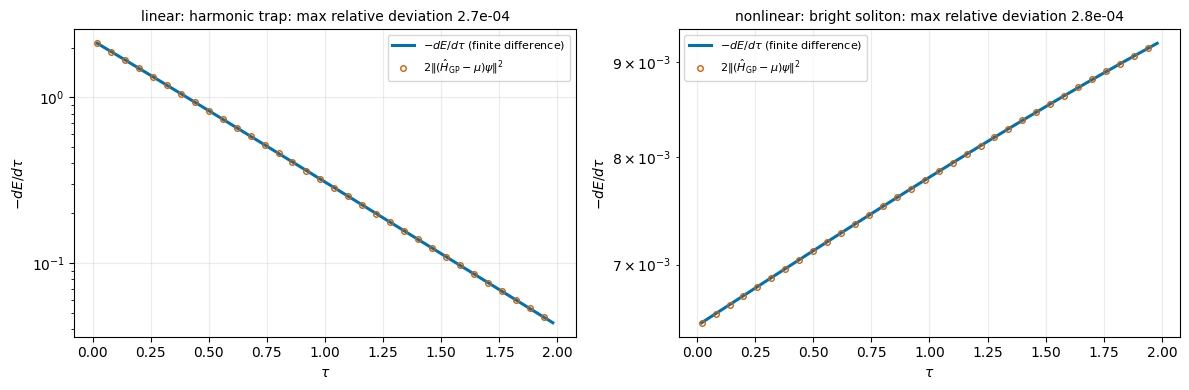


CHECKPOINT 8 passed: imaginary time is normalised gradient flow, Eq. (40).


In [17]:
# ==============================================================================
# DEMONSTRATION 4: the energy really is a gradient flow -- Eq. (40) measured
#   dE/dtau is estimated by a centred difference along a stored trajectory,
#   and compared with -2 * residual^2 computed independently at the same tau.
# ==============================================================================
TAU_SNAP, N_SNAP = 0.02, 100
DTAU_FLOW = 0.001

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))
for ax, (tag, Lg, Ng, gg, Vg, start) in zip(axes, [
        ("linear: harmonic trap", L_HO, N_HO, 0.0, lambda xx: 0.5 * xx ** 2,
         lambda xx: gaussian_packet(xx, 0.7, x_c=1.5)),
        ("nonlinear: bright soliton", L, N_X, G, lambda xx: 0.0 * xx,
         lambda xx: gaussian_packet(xx, 3.0))]):
    xg, kg, dxg = make_grid(Lg, Ng)
    Vg_np = Vg(xg)
    psi_s = jnp.asarray(normalise(start(xg), dxg))
    fr = np.asarray(imaginary_time_frames(psi_s, jnp.asarray(kg), dxg, gg, jnp.asarray(Vg_np),
                                          DTAU_FLOW, int(round(TAU_SNAP / DTAU_FLOW)), N_SNAP))
    tau_s = np.arange(N_SNAP + 1) * TAU_SNAP
    E_s = np.array([gp_energy(f, kg, dxg, gg, Vg_np) for f in fr])
    R_s = np.array([gp_residual(f, kg, dxg, gg, Vg_np) for f in fr])
    dE_measured = (E_s[2:] - E_s[:-2]) / (2 * TAU_SNAP)
    dE_predicted = -2.0 * R_s[1:-1] ** 2
    rel = np.max(np.abs(dE_measured - dE_predicted) / np.abs(dE_predicted))
    ax.plot(tau_s[1:-1], -dE_measured, color=C_NUM, lw=2.2, label=r"$-dE/d\tau$ (finite difference)")
    ax.plot(tau_s[1:-1:3], 2 * R_s[1:-1:3] ** 2, "o", ms=4, color=C_ANA, mfc="none",
            label=r"$2\Vert(\hat H_{\rm GP}-\mu)\psi\Vert^{2}$")
    ax.set_yscale("log"), ax.grid(alpha=0.25)
    ax.set_xlabel(r"$\tau$"), ax.set_ylabel(r"$-dE/d\tau$")
    ax.set_title(f"{tag}: max relative deviation {rel:.1e}", fontsize=10)
    ax.legend(fontsize=8)
    assert np.all(np.diff(E_s) <= 1e-14), "the energy must never increase"
    assert rel < 5e-3, "Eq. (40) must hold to the accuracy of the finite difference in tau"
    print(f"{tag:28s}: E decreases monotonically from {E_s[0]:+.6f} to {E_s[-1]:+.6f}; "
          f"Eq. (40) holds to {rel:.1e}")
fig.tight_layout()
plt.show()
print("\nCHECKPOINT 8 passed: imaginary time is normalised gradient flow, Eq. (40).")

Both panels put two independently computed quantities on top of each other: the numerical derivative of the
stored energy curve, and twice the squared residual evaluated from the stored states. They agree to
$2.7\times10^{-4}$ (linear) and $2.8\times10^{-4}$ (nonlinear), which is the truncation error of the centred
difference with $\Delta\tau_{\rm snap}=0.02$, not a discrepancy in Eq. (40). The energy is monotonic in both
runs. Over the two units of $\tau$ plotted, the linear descent rate falls by a factor $50$ while the
nonlinear one *rises* by $45\%$: gradient flow is not obliged to slow down monotonically, only to keep
$dE/d\tau\le0$, and the wide Gaussian of the right panel is still accelerating into the minimum at
$\tau = 2$.

### 7.8 What changes when the equation is nonlinear

The derivation of Section 7.2 uses the superposition principle twice: to expand $\psi$ in eigenstates and to
evolve each term independently. Neither step is available for Eq. (8). There is no eigenbasis of
$\hat H_{\rm GP}[\psi]$ that does not itself depend on $\psi$, and $e^{-\hat H_{\rm GP}\tau}$ applied to a sum
is not the sum of the results.

What survives is viewpoint (c). Equations (39) and (40) never used linearity: they used only that $E[\psi]$ is
a real functional and that $\hat H_{\rm GP}\psi = \delta E/\delta\psi^{*}$. So for the Gross-Pitaevskii
equation, imaginary-time relaxation is **normalised gradient flow of the energy functional**, and it is
guaranteed to decrease $E$ until the residual vanishes. Bao and Du (SIAM J. Sci. Comput. **25**, 1674 (2004))
proved that this continuous normalised gradient flow conserves the norm and diminishes the energy, and analysed
discretisations of it in which the normalisation is applied after each step.

Three consequences of replacing "lowest eigenstate" by "local minimum of a functional":

* **"Ground state" now means "minimiser of $E[\psi]$ at fixed norm".** For the attractive one-dimensional
  problem that minimiser exists and is unique up to translation and a global phase (Section 6.2), so the
  distinction is academic here. For a condensate in a double well, a rotating trap or a spinor gas it is not:
  the energy landscape has several local minima, and gradient flow finds the one whose basin contains the
  initial guess.
* **The initial guess matters more than in the linear case.** It decides the basin, and — through the zero
  mode of translation — it decides *where* the soliton ends up (Section 8.6).
* **$\mu$ is a Lagrange multiplier, not an eigenvalue.** It appears in Eq. (39) to enforce the constraint,
  and it equals $\langle \hat H_{\rm GP}\rangle$ only *at* the fixed point. Away from it, $\mu[\psi]$ and
  $E[\psi]$ are two different numbers, both changing.

### 7.9 Reading $\mu$ off the norm decay

Near the fixed point the step of Eq. (37) acts on $\psi_{*}$ like $e^{-\hat H_{\rm GP}\Delta\tau}$ acting on
its own eigenstate, so the *unnormalised* output is

$$ S(\Delta\tau)\,\psi_{*} \;=\; e^{-\mu\Delta\tau}\,\psi_{*} + O(\Delta\tau^{3}) . $$

At the fixed point of the discrete map the output is *exactly* proportional to $\psi_{*}$, so the relation
below defines a number for any $\Delta\tau$; how close that number is to $\mu$ is a separate question, and
the $O(\Delta\tau^{3})$ above is the linear-problem answer. Since the state entering each step has unit norm,
the norm recorded before the renormalisation is $\nu = e^{-\mu\Delta\tau}$, and therefore

$$ \mu \;=\; -\,\frac{\ln \nu}{\Delta\tau} \;=\; -\,\frac{\ln\left(\nu^{2}\right)}{2\,\Delta\tau} . \tag{41} $$

This costs nothing — the norm has to be computed anyway to renormalise — and it is completely independent of
the expectation value $\langle \hat H_{\rm GP}\rangle$, which needs two FFTs of its own. Comparing the two is
a free consistency check, and their difference is a convergence monitor in its own right.

In [18]:
# ==============================================================================
# DEMONSTRATION 5: mu from the norm decay, Eq. (41), against mu = <H_GP>
# ==============================================================================
print(f"{'problem':28s} {'dtau':>8s} {'mu from norms':>16s} {'mu = <H_GP>':>16s} {'exact':>12s}")
for tag, Lg, Ng, gg, Vfun, start, mu_ex in [
        ("linear: harmonic trap", L_HO, N_HO, 0.0, lambda xx: 0.5 * xx ** 2,
         lambda xx: gaussian_packet(xx, 0.7, x_c=1.5), 0.5),
        ("nonlinear: bright soliton", L, N_X, G, lambda xx: 0.0 * xx,
         lambda xx: gaussian_packet(xx, 3.0), -G ** 2 / 8)]:
    xg, kg, dxg = make_grid(Lg, Ng)
    Vg_np = Vfun(xg)
    for dtau in (0.01, 0.0025):
        psi_f, nrms = imaginary_time_ground_state(jnp.asarray(normalise(start(xg), dxg)),
                                                  jnp.asarray(kg), dxg, gg, jnp.asarray(Vg_np),
                                                  dtau, int(round(40.0 / dtau)))
        mu_from_norm = -float(jnp.log(nrms[-1])) / dtau
        mu_expect_num = gp_chemical_potential(np.asarray(psi_f), kg, dxg, gg, Vg_np)
        print(f"{tag:28s} {dtau:8.4f} {mu_from_norm:16.10f} {mu_expect_num:16.10f} {mu_ex:12.6f}")
        assert abs(mu_from_norm - mu_ex) < 0.05, "Eq. (41) must give mu to within the splitting bias"

problem                          dtau    mu from norms      mu = <H_GP>        exact
linear: harmonic trap          0.0100     0.4999979167     0.5000000000     0.500000


linear: harmonic trap          0.0025     0.4999998698     0.5000000000     0.500000
nonlinear: bright soliton      0.0100    -0.4961807845    -0.4981363033    -0.500000


nonlinear: bright soliton      0.0025    -0.4990320594    -0.4995292251    -0.500000


For the linear trap $\langle\hat H_{\rm GP}\rangle$ gives $0.5$ to ten digits at either time step, and the
norm-decay estimate gives $0.4999979$ at $\Delta\tau=0.01$ and $0.4999999$ at $\Delta\tau=0.0025$ — an error
falling by $16$ for a factor $4$ in $\Delta\tau$, the $O(\Delta\tau^{2})$ of Eq. (36).

For the soliton the two estimates differ from each other and from $-0.5$ in the third decimal, and both errors
shrink by a factor of *four*, not sixteen, when $\Delta\tau$ is divided by four: a first-order bias, whose
origin and size Section 8.2 measures properly. This is expected — for a nonlinear problem the
converged state is the fixed point of the *discretised* flow, not of Eq. (15), and the two agree only in the
limit $\Delta\tau\to0$.

### 7.10 Practical rules

* **Choosing $\Delta\tau$.** Too large: the splitting bias of Eq. (36) contaminates the answer, and if
  $2g\vert\psi\vert^{2}\Delta\tau$ approaches one the nonlinear factor $e^{g\vert\psi\vert^{2}\Delta\tau}$
  amplifies the peak faster than diffusion can spread it and the iteration runs away. Too small: the number
  of steps needed to travel a fixed $\tau$ grows, and $\tau$ itself must be several times $1/(E_1-E_0)$.
  The practical recipe is to converge at one $\Delta\tau$, halve it, and check that the answer moved by less
  than the accuracy you need — or extrapolate, as Section 8.4 does.
* **Stopping.** Two criteria, both cheap: the energy change per unit $\tau$ (which by Eq. (40) *is* the
  squared residual) and the residual itself. "The density stopped changing on the plot" is not a criterion.
* **Imaginary time is not time.** Equation (38) is a diffusion equation; it is not unitary, not reversible,
  and has nothing to do with the physical evolution of the system. The relaxation movie of Section 10.1 shows
  an algorithm converging, not a condensate doing anything. The only thing one may read off it is which
  features disappear first — high spatial frequencies, because they diffuse fastest.

## 8. The soliton ground state, found numerically

### 8.1 Relaxing a Gaussian into a $\mathrm{sech}$

The initial guess is deliberately poor: a Gaussian of width $\sigma = 3$, more than three times wider than the
soliton, with $95.5\%$ of its weight in the wrong shape. Nothing about the answer is fed in. The monitors are
the three of Section 7: the energy $E(\tau)$, the chemical potential from $\langle \hat H_{\rm GP}\rangle$,
and the residual $\Vert(\hat H_{\rm GP}-\mu)\psi\Vert$; to those we add the only monitor available because we
happen to know the answer, the distance to the exact profile of Eq. (22).

In [19]:
# ==============================================================================
# PARAMETERS of the imaginary-time run
# ==============================================================================
SIGMA_GUESS = 3.0        # width of the initial Gaussian -- 3.3 times too wide
DTAU        = 0.005      # imaginary-time step
TAU_MAX     = 40.0       # total imaginary time
N_FRAMES_IT = 80         # snapshots kept for the monitors and the animation

n_inner_it = int(round((TAU_MAX / N_FRAMES_IT) / DTAU))
taus_it = np.arange(N_FRAMES_IT + 1) * (TAU_MAX / N_FRAMES_IT)
V_ZERO = jnp.zeros(N_X, dtype=RDTYPE)          # no trap: the soliton makes its own

psi_guess = jnp.asarray(normalise(gaussian_packet(x, SIGMA_GUESS), dx))
print(f"initial guess: Gaussian of width {SIGMA_GUESS} (soliton width {np.pi / (np.sqrt(3) * G):.3f}), "
      f"E = {gp_energy(np.asarray(psi_guess), k, dx, G):+.6f} vs E_soliton = {-G ** 2 / 24:+.6f}")
print(f"run: dtau = {DTAU}, tau_max = {TAU_MAX}, {int(TAU_MAX / DTAU)} steps, "
      f"{N_FRAMES_IT} snapshots every {TAU_MAX / N_FRAMES_IT:g}")

initial guess: Gaussian of width 3.0 (soliton width 0.907), E = -0.080143 vs E_soliton = -0.166667
run: dtau = 0.005, tau_max = 40.0, 8000 steps, 80 snapshots every 0.5


In [20]:
# ==============================================================================
# THE RUN: imaginary-time relaxation of a Gaussian into the bright soliton
# ==============================================================================
t_wall = time.time()
frames_it = np.asarray(imaginary_time_frames(psi_guess, jnp.asarray(k), dx, G, V_ZERO,
                                             DTAU, n_inner_it, N_FRAMES_IT))
print(f"{int(TAU_MAX / DTAU)} imaginary-time steps (compile + run): {time.time() - t_wall:.2f} s")

E_it = np.array([gp_energy(f, k, dx, G) for f in frames_it])
mu_it = np.array([gp_chemical_potential(f, k, dx, G) for f in frames_it])
res_it = np.array([gp_residual(f, k, dx, G) for f in frames_it])
phi_ref = np.abs(soliton_exact(x, g=G))
prof_err_it = np.array([np.sqrt(dx * np.sum((np.abs(f) - phi_ref) ** 2)) for f in frames_it])

psi_gs = frames_it[-1]
print(f"\nconverged after tau = {TAU_MAX}:")
print(f"   E   = {E_it[-1]:.12f}   exact -g^2/24 = {-G ** 2 / 24:.12f}   error {abs(E_it[-1] + G ** 2 / 24):.2e}")
print(f"   mu  = {mu_it[-1]:.12f}   exact -g^2/8  = {-G ** 2 / 8:.12f}   error {abs(mu_it[-1] + G ** 2 / 8):.2e}")
print(f"   residual                        = {res_it[-1]:.3e}")
print(f"   || |psi| - sech ||              = {prof_err_it[-1]:.3e}")
print(f"   peak density  {np.max(np.abs(psi_gs) ** 2):.8f}   exact g/4 = {G / 4:.8f}")
print(f"   sigma         {np.sqrt(position_variance(psi_gs, x, dx, L)):.8f}   exact = "
      f"{np.pi / (np.sqrt(3) * G):.8f}")
assert np.all(np.diff(E_it) <= 1e-14), "the energy must decrease monotonically"
assert abs(E_it[-1] + G ** 2 / 24) < 1e-5 and abs(mu_it[-1] + G ** 2 / 8) < 1e-2

8000 imaginary-time steps (compile + run): 0.22 s

converged after tau = 40.0:
   E   = -0.166665294720   exact -g^2/24 = -0.166666666667   error 1.37e-06
   mu  = -0.499061797456   exact -g^2/8  = -0.500000000000   error 9.38e-04
   residual                        = 1.020e-03
   || |psi| - sech ||              = 1.626e-03
   peak density  0.49848459   exact g/4 = 0.50000000
   sigma         0.90926298   exact = 0.90689968


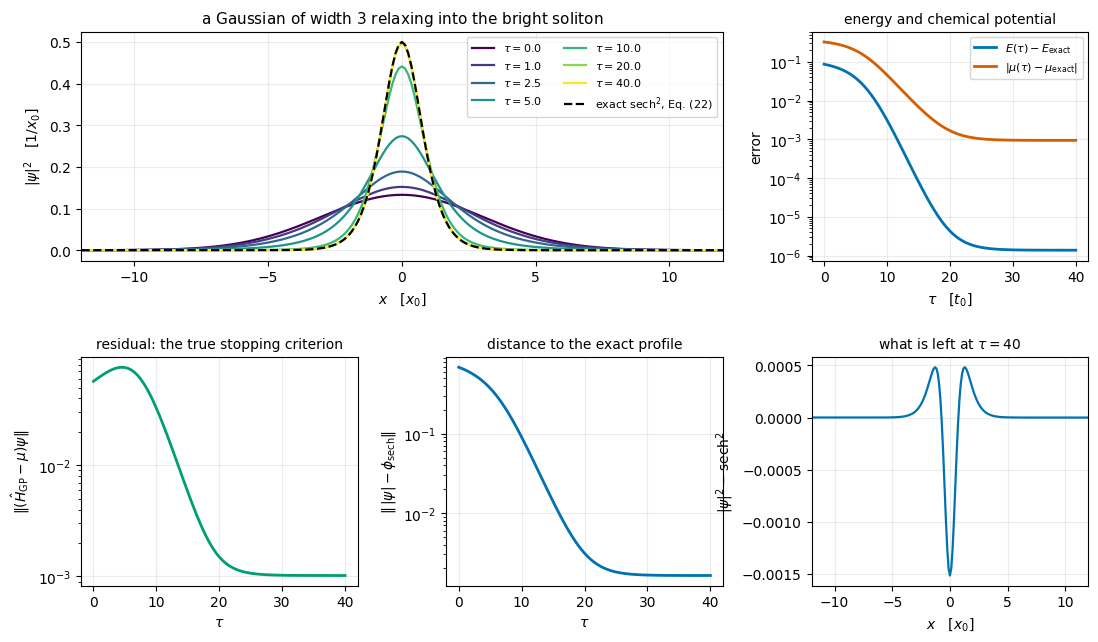

In [21]:
# ==============================================================================
# FIGURE: the relaxation, and its three convergence monitors
# ==============================================================================
fig = plt.figure(figsize=(13.0, 7.2))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.32)

ax = fig.add_subplot(gs[0, :2])
show_at = [0, 2, 5, 10, 20, 40, 80]
cmap = plt.get_cmap("viridis")
for j, idx in enumerate(show_at):
    ax.plot(x, np.abs(frames_it[idx]) ** 2, lw=1.6, color=cmap(j / (len(show_at) - 1)),
            label=rf"$\tau={taus_it[idx]:.1f}$")
ax.plot(x, phi_ref ** 2, "k--", lw=1.6, label=r"exact $\mathrm{sech}^2$, Eq. (22)")
ax.set_xlim(-12, 12), ax.set_xlabel(r"$x$   [$x_0$]"), ax.set_ylabel(r"$|\psi|^2$   [$1/x_0$]")
ax.set_title(r"a Gaussian of width $3$ relaxing into the bright soliton", fontsize=11)
ax.grid(alpha=0.25), ax.legend(fontsize=8, ncol=2)

ax = fig.add_subplot(gs[0, 2])
ax.semilogy(taus_it, E_it + G ** 2 / 24, color=C_NUM, lw=2.0, label=r"$E(\tau)-E_{\rm exact}$")
ax.semilogy(taus_it, np.abs(mu_it + G ** 2 / 8), color=C_ANA, lw=2.0, label=r"$|\mu(\tau)-\mu_{\rm exact}|$")
ax.set_xlabel(r"$\tau$   [$t_0$]"), ax.set_ylabel("error")
ax.set_title("energy and chemical potential", fontsize=10)
ax.grid(alpha=0.25), ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 0])
ax.semilogy(taus_it, res_it, color=C_THIRD, lw=2.0)
ax.set_xlabel(r"$\tau$"), ax.set_ylabel(r"$\Vert(\hat H_{\rm GP}-\mu)\psi\Vert$")
ax.set_title("residual: the true stopping criterion", fontsize=10), ax.grid(alpha=0.25)

ax = fig.add_subplot(gs[1, 1])
ax.semilogy(taus_it, prof_err_it, color=C_NUM, lw=2.0)
ax.set_xlabel(r"$\tau$"), ax.set_ylabel(r"$\Vert\,|\psi|-\phi_{\rm sech}\Vert$")
ax.set_title("distance to the exact profile", fontsize=10), ax.grid(alpha=0.25)

ax = fig.add_subplot(gs[1, 2])
ax.plot(x, np.abs(psi_gs) ** 2 - phi_ref ** 2, color=C_NUM, lw=1.6)
ax.set_xlim(-12, 12), ax.set_xlabel(r"$x$   [$x_0$]")
ax.set_ylabel(r"$|\psi|^2-\mathrm{sech}^2$")
ax.set_title(rf"what is left at $\tau={TAU_MAX:g}$", fontsize=10), ax.grid(alpha=0.25)
plt.show()

The wide Gaussian contracts, overshoots nothing (gradient flow cannot overshoot: Eq. (40) forbids the energy
from rising), and by $\tau = 20$ is indistinguishable from the dashed analytic curve on the scale of the
plot. At $\tau = 10$ its peak is still $10\%$ low, which is why the eye is not a convergence criterion. The
quantitative statement is in the other four panels.

* $E$ converges to $-0.166665$ against the exact $-0.1666667$: an error of $1.4\times10^{-6}$.
* $\mu$ converges to $-0.49906$ against $-0.5$: an error of $9.4\times10^{-4}$, seven hundred times larger.
* The residual stops falling at $1.0\times10^{-3}$, and the distance to the exact profile at
  $1.6\times10^{-3}$.

All four have *stopped improving* by $\tau\approx25$: the flow has converged, and what remains is not a
failure to converge but a property of the discrete map being iterated. The residual is not even monotonic —
it rises from $0.05$ to $0.07$ over the first five units of $\tau$ before falling, which the energy, by
Eq. (40), is not allowed to do. The last panel shows the shape of the residue: a dip of $-1.5\times10^{-3}$
at the centre and two symmetric bumps of $+5\times10^{-4}$ near $x=\pm1.3$, i.e. a converged soliton that is
slightly too wide and too low ($\sigma = 0.9093$ against $0.9069$, peak density $0.4985$ against $0.5$) — a
smooth deformation, not noise. Section 8.2 identifies it.

### 8.2 The bias left by the time step

The converged state is the fixed point of the *discrete* map (37), not of the continuous flow (39). By
Eq. (36) the map is the exact flow of a modified generator $\hat T+\hat W+\Delta\tau^{2}\hat C_2$, so one
expects the fixed point to be displaced by $O(\Delta\tau^{2})$. For the linear problem that is exactly what
happens. For the nonlinear problem it is not, and the reason is worth understanding.

The culprit is the renormalisation, which sits *outside* the symmetric product. What the three factors of
Eq. (37) integrate is the **unnormalised** flow

$$ \frac{\partial\psi}{\partial\tau} \;=\; X[\psi] \;\equiv\; -\hat H_{\rm GP}[\psi]\,\psi
   \;=\; \frac{1}{2}\psi'' + g\vert\psi\vert^{2}\psi , $$

and the projection onto the unit sphere is applied once, at the end of the step. For a *linear* $\hat H$ that
costs nothing: $e^{-\hat H\tau}\psi$ followed by normalisation **is** the exact solution of the normalised
flow (39), because scaling $\psi$ does not change $\hat H$. The Gross-Pitaevskii field $X$ has no such
property — $X[c\psi] \ne c\,X[\psi]$ — and the norm does move during a step, at the rate
$d\Vert\psi\Vert^{2}/d\tau = -2\mu$.

Expand one step at the exact soliton $\phi$. To first order $X[\phi] = -\mu\phi$ is proportional to $\phi$,
so the renormalisation removes it completely; the first term that is *not* proportional to $\phi$ appears at
second order,

$$ \phi + \Delta\tau\,X[\phi] + \frac{\Delta\tau^{2}}{2}\,DX[\phi]\!\left(X[\phi]\right) + \ldots
   \;=\; \left(1 - \mu\Delta\tau + \tfrac{1}{2}\mu^{2}\Delta\tau^{2}\right)\phi
   \;-\; \mu\,g\,\Delta\tau^{2}\,\phi^{3} + O(\Delta\tau^{3}) , $$

using $DX[\phi](\eta) = \tfrac12\eta'' + 3g\phi^{2}\eta$ for real $\phi$ and real $\eta$, and
$\tfrac12\phi'' = -\mu\phi - g\phi^{3}$ from Eq. (17). The
stray $\phi^{3}$ survives the normalisation, so every step pushes the state off the soliton by
$O(\Delta\tau^{2})$ in a direction the flow restores at a rate of order one — and the fixed point is
displaced by $O(\Delta\tau)$. The coefficient is proportional to $\mu g$, which is why the linear problem
($g=0$) is clean. The same displacement is what separates the discrete-normalisation flow that is implemented
from the continuous normalised flow (39) that is analysed, the distinction Bao and Du make.

Two things that do *not* repair it, both worth knowing because both look like the obvious fix. The middle
factor of Eq. (37) evaluates $\vert\psi\vert^{2}$ after the first kinetic half-step, where the norm is
$1 - E_{\rm kin}\Delta\tau/2 + O(\Delta\tau^{2})$ rather than one; normalising that intermediate state, so
that the interaction really is $g\vert\psi\vert^{2}$ for a unit-norm $\psi$, reduces the error of the
converged state by about $30\,\%$ and leaves its order at one. Replacing the frozen factor
$e^{g\vert\psi\vert^{2}\Delta\tau}$ by the exact solution
$\left(1-2g\vert\psi\vert^{2}\Delta\tau\right)^{-1/2}$ of the substep does not help either. What does work is
to integrate a field that *is* scale-covariant, $\tfrac12\psi'' + g(\vert\psi\vert^{2}/\Vert\psi\Vert^{2})\psi$,
whose flow commutes with the normalisation; Exercise 9 builds it and recovers the linear orders exactly.

The prediction is then:

* the converged **state** is wrong at $O(\Delta\tau)$, so the residual and the profile error scale linearly;
* the converged **energy** is wrong at $O(\Delta\tau^{2})$, because $E[\psi]$ is *stationary* at the exact
  minimiser: a state error $\varepsilon$ produces an energy error $O(\varepsilon^{2})$;
* the converged **chemical potential** is wrong at $O(\Delta\tau)$, because $\mu$ is not stationary.

All three are measured below, together with the same experiment run with $g = 0$ in a harmonic trap, where
the argument above does not apply and the orders are one better.

In [22]:
# ==============================================================================
# CONVERGENCE STUDY 1: the bias of the converged state as a function of dtau
#   Same total tau for every run, so every run is fully converged; only dtau changes.
# ==============================================================================
dtau_list = np.array([0.04, 0.02, 0.01, 0.005, 0.0025, 0.00125])
rows_nl, rows_lin = [], []

for dtau in dtau_list:
    n_steps = int(round(TAU_MAX / dtau))
    psi_f, _ = imaginary_time_ground_state(psi_guess, jnp.asarray(k), dx, G, V_ZERO, dtau, n_steps)
    p = np.asarray(psi_f)
    rows_nl.append((dtau,
                    abs(gp_energy(p, k, dx, G) + G ** 2 / 24),
                    abs(gp_chemical_potential(p, k, dx, G) + G ** 2 / 8),
                    gp_residual(p, k, dx, G),
                    np.sqrt(dx * np.sum((np.abs(p) - phi_ref) ** 2))))
    psi_l, _ = imaginary_time_ground_state(jnp.asarray(normalise(gaussian_packet(x_ho, 0.7, x_c=1.5), dx_ho)),
                                           k_ho_j, dx_ho, 0.0, V_HO, dtau, int(round(TAU_MAX / dtau)))
    pl = np.asarray(psi_l)
    rows_lin.append((dtau,
                     abs(gp_energy(pl, k_ho, dx_ho, 0.0, V_HO_np) - 0.5),
                     abs(gp_chemical_potential(pl, k_ho, dx_ho, 0.0, V_HO_np) - 0.5),
                     gp_residual(pl, k_ho, dx_ho, 0.0, V_HO_np),
                     np.sqrt(dx_ho * np.sum((np.abs(pl) - phi0_ho) ** 2))))

rows_nl, rows_lin = np.array(rows_nl), np.array(rows_lin)
slopes_nl = [np.polyfit(np.log(rows_nl[:, 0]), np.log(rows_nl[:, j]), 1)[0] for j in (1, 2, 3, 4)]
slopes_lin = [np.polyfit(np.log(rows_lin[:, 0]), np.log(rows_lin[:, j]), 1)[0] for j in (1, 2, 3, 4)]

for tag, rows, slopes in (("NONLINEAR (bright soliton, g = 2)", rows_nl, slopes_nl),
                          ("LINEAR (harmonic trap, g = 0)", rows_lin, slopes_lin)):
    print(f"\n{tag}")
    print(f"{'dtau':>9s} {'|dE|':>11s} {'|dmu|':>11s} {'residual':>11s} {'profile err':>12s}")
    for r in rows:
        print(f"{r[0]:9.5f} {r[1]:11.3e} {r[2]:11.3e} {r[3]:11.3e} {r[4]:12.3e}")
    print(f"{'fitted slope':>9s} {slopes[0]:11.3f} {slopes[1]:11.3f} {slopes[2]:11.3f} {slopes[3]:12.3f}")

assert abs(slopes_nl[0] - 2.0) < 0.1 and abs(slopes_nl[1] - 1.0) < 0.1, "nonlinear: E ~ dtau^2, mu ~ dtau"
assert abs(slopes_lin[0] - 4.0) < 0.2 and abs(slopes_lin[1] - 4.0) < 0.2, "linear: E ~ dtau^4"
assert abs(slopes_lin[2] - 2.0) < 0.1, "linear: the state itself is O(dtau^2)"
print("\nCHECKPOINT 9 passed: measured orders match Section 8.2.")


NONLINEAR (bright soliton, g = 2)
     dtau        |dE|       |dmu|    residual  profile err
  0.04000   7.868e-05   7.174e-03   7.559e-03    1.244e-02
  0.02000   2.091e-05   3.679e-03   3.944e-03    6.378e-03
  0.01000   5.398e-06   1.864e-03   2.016e-03    3.230e-03
  0.00500   1.372e-06   9.382e-04   1.020e-03    1.626e-03
  0.00250   3.459e-07   4.708e-04   5.128e-04    8.159e-04
  0.00125   8.689e-08   2.359e-04   2.572e-04    4.088e-04
fitted slope       1.967       0.986       0.977        0.987

LINEAR (harmonic trap, g = 0)
     dtau        |dE|       |dmu|    residual  profile err
  0.04000   9.996e-09   9.996e-09   1.414e-04    7.070e-05
  0.02000   6.249e-10   6.249e-10   3.535e-05    1.768e-05
  0.01000   3.906e-11   3.906e-11   8.839e-06    4.419e-06
  0.00500   2.441e-12   2.441e-12   2.210e-06    1.105e-06
  0.00250   1.524e-13   1.525e-13   5.524e-07    2.762e-07
  0.00125   9.770e-15   9.770e-15   1.381e-07    6.905e-08
fitted slope       3.995       3.995       2.0

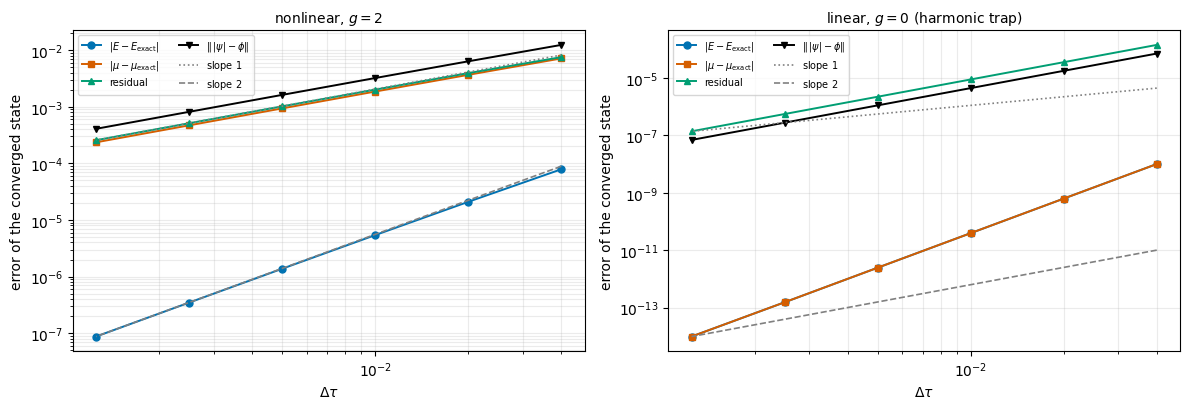

E(dtau=0.02)  = -0.166645753494   error 2.09e-05
E(dtau=0.01)  = -0.166661268454   error 5.40e-06
Richardson    = -0.166666440107   error 2.27e-07   (exact -0.166666666667)


In [23]:
# ==============================================================================
# FIGURE + RICHARDSON EXTRAPOLATION in dtau
#   E(dtau) = E_exact + c dtau^2 + O(dtau^4)  ->  (4 E(h/2) - E(h)) / 3 removes the leading term.
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))
for ax, (tag, rows) in zip(axes, [("nonlinear, $g=2$", rows_nl), ("linear, $g=0$ (harmonic trap)", rows_lin)]):
    for j, (lab, col, mk) in zip((1, 2, 3, 4),
                                 [(r"$|E-E_{\rm exact}|$", C_NUM, "o"),
                                  (r"$|\mu-\mu_{\rm exact}|$", C_ANA, "s"),
                                  (r"residual", C_THIRD, "^"),
                                  (r"$\Vert\,|\psi|-\phi\Vert$", "k", "v")]):
        ax.loglog(rows[:, 0], rows[:, j], mk + "-", ms=5, color=col, lw=1.4, label=lab)
    ref = rows[-1, 0]
    ax.loglog(rows[:, 0], rows[-1, 3] * (rows[:, 0] / ref) ** 1, ":", color="0.5", lw=1.2,
              label=r"slope $1$")
    ax.loglog(rows[:, 0], rows[-1, 1] * (rows[:, 0] / ref) ** 2, "--", color="0.5", lw=1.2,
              label=r"slope $2$")
    ax.set_xlabel(r"$\Delta\tau$"), ax.set_ylabel("error of the converged state")
    ax.set_title(tag, fontsize=10), ax.grid(alpha=0.25, which="both"), ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

E_h = np.array([gp_energy(np.asarray(imaginary_time_ground_state(
    psi_guess, jnp.asarray(k), dx, G, V_ZERO, h, int(round(TAU_MAX / h)))[0]), k, dx, G)
    for h in (0.02, 0.01)])
E_rich = (4 * E_h[1] - E_h[0]) / 3.0
print(f"E(dtau=0.02)  = {E_h[0]:.12f}   error {abs(E_h[0] + G ** 2 / 24):.2e}")
print(f"E(dtau=0.01)  = {E_h[1]:.12f}   error {abs(E_h[1] + G ** 2 / 24):.2e}")
print(f"Richardson    = {E_rich:.12f}   error {abs(E_rich + G ** 2 / 24):.2e}   (exact {-G ** 2 / 24:.12f})")
assert abs(E_rich + G ** 2 / 24) < 0.1 * abs(E_h[1] + G ** 2 / 24), "extrapolation must beat the finer run"

The measured slopes in the nonlinear case are $1.97$ for the energy, $0.99$ for the chemical potential,
$0.98$ for the residual and $0.99$ for the profile error — the pattern predicted above. The linear run in the
same figure is one order better on every line: $2.000$ for the state and $3.995$ for the energy, because
there the interaction term does not exist and the only error is the symmetric splitting (36), with the energy
gaining a further factor of two in the exponent from being stationary.

Richardson extrapolation exploits the $\Delta\tau^{2}$ law directly: combining the runs at $\Delta\tau=0.02$
and $0.01$ as $(4E_{h/2}-E_h)/3$ cancels the leading term and reduces the energy error from
$5.4\times10^{-6}$ to $2.3\times10^{-7}$, a factor of $24$, at no extra cost.

> **Numerical practice.** When an iterative solver stops improving, ask whether it has failed to converge or
> whether it has converged to the wrong fixed point. The first is cured by iterating longer, the second only
> by refining the discretisation. The residual alone cannot tell them apart; running the same calculation at
> two values of $\Delta\tau$ can.

### 8.3 The two spatial parameters

The grid contributes two more errors, and they are cleanest to measure on the *exact* profile, where no
imaginary time is involved at all.

* **Resolution $\Delta x = L/N_x$.** The $\mathrm{sech}$ is analytic and its Fourier transform decays like
  $e^{-\pi k/g}$, so the spectral method converges faster than any power of $\Delta x$ — the behaviour
  established in 00a.
* **Ring size $L$.** The soliton is not periodic; wrapping it onto a ring adds its own periodic images, whose
  amplitude at the far side is $\sim e^{-gL/4}$. The error must fall exponentially with $L$, by the factor
  $e^{-g\Delta L/4}$ per increment.

In [24]:
# ==============================================================================
# CONVERGENCE STUDY 2: resolution and ring size, measured on the exact profile
# ==============================================================================
print("(a) refine the grid at fixed L = 60")
print(f"{'N_x':>6s} {'dx':>9s} {'|E-E_ex|':>11s} {'|mu-mu_ex|':>12s} {'residual':>11s}")
for n_pts in (64, 96, 128, 192, 256, 512):
    xg, kg, dxg = make_grid(60.0, n_pts)
    pg = normalise(soliton_exact(xg, g=G), dxg)
    print(f"{n_pts:6d} {dxg:9.5f} {abs(gp_energy(pg, kg, dxg, G) + G ** 2 / 24):11.2e} "
          f"{abs(gp_chemical_potential(pg, kg, dxg, G) + G ** 2 / 8):12.2e} "
          f"{gp_residual(pg, kg, dxg, G):11.2e}")

print("\n(b) enlarge the ring at EXACTLY constant dx = 60/768 = 0.078125")
print(f"{'L':>6s} {'N_x':>6s} {'residual':>11s} {'ratio':>10s} {'exp(-g dL/4)':>13s}")
prev_res, ratios_L = None, []
for L_try, n_pts in ((20.0, 256), (30.0, 384), (40.0, 512), (50.0, 640), (60.0, 768)):
    xg, kg, dxg = make_grid(L_try, n_pts)
    pg = normalise(soliton_exact(xg, g=G), dxg)
    r = gp_residual(pg, kg, dxg, G)
    ratio = r / prev_res if prev_res else float("nan")
    if prev_res:
        ratios_L.append(ratio)
    prev_res = r
    print(f"{L_try:6.1f} {n_pts:6d} {r:11.2e} {ratio:10.5f} {np.exp(-G * 10.0 / 4):13.5f}")
print(f"       geometric mean of the four ratios: {np.exp(np.mean(np.log(ratios_L))):.5f}")

print("\n(c) imaginary time on an undersized ring (L = 12, dtau = 0.005): the images bind the soliton")
x_s, k_s, dx_s = make_grid(12.0, 128)
psi_s, _ = imaginary_time_ground_state(jnp.asarray(normalise(gaussian_packet(x_s, 1.5), dx_s)),
                                       jnp.asarray(k_s), dx_s, G, jnp.zeros(128, dtype=RDTYPE),
                                       0.005, 8000)
p_s = np.asarray(psi_s)
print(f"    E  = {gp_energy(p_s, k_s, dx_s, G):.8f}  vs the infinite-line value {-G ** 2 / 24:.8f} "
      f"(shift {gp_energy(p_s, k_s, dx_s, G) + G ** 2 / 24:+.2e})")
print(f"    mu = {gp_chemical_potential(p_s, k_s, dx_s, G):.8f}  vs {-G ** 2 / 8:.8f}")
print(f"    minimum of |psi|^2 on the ring: {np.min(np.abs(p_s) ** 2):.3e}  (it never reaches zero)")

(a) refine the grid at fixed L = 60
   N_x        dx    |E-E_ex|   |mu-mu_ex|    residual
    64   0.93750    2.03e-03     5.87e-03    2.10e-02
    96   0.62500    3.63e-05     1.07e-04    2.38e-03
   128   0.46875    4.48e-07     1.33e-06    2.29e-04
   192   0.31250    4.07e-11     1.22e-10    1.77e-06
   256   0.23438    2.80e-15     8.10e-15    1.22e-08
   512   0.11719    1.39e-16     3.33e-16    5.56e-13

(b) enlarge the ring at EXACTLY constant dx = 60/768 = 0.078125
     L    N_x    residual      ratio  exp(-g dL/4)
  20.0    256    3.32e-04        nan       0.00674
  30.0    384    2.23e-06    0.00674       0.00674
  40.0    512    1.51e-08    0.00674       0.00674
  50.0    640    1.01e-10    0.00674       0.00674
  60.0    768    6.86e-13    0.00677       0.00674
       geometric mean of the four ratios: 0.00675

(c) imaginary time on an undersized ring (L = 12, dtau = 0.005): the images bind the soliton


    E  = -0.16668990  vs the infinite-line value -0.16666667 (shift -2.32e-05)
    mu = -0.49883559  vs -0.50000000
    minimum of |psi|^2 on the ring: 5.047e-05  (it never reaches zero)


Panel (a): from $N_x = 64$ to $N_x = 512$ the energy error falls from $2\times10^{-3}$ to $10^{-16}$ —
thirteen orders of magnitude for an eightfold refinement, which no power law can do. This is the spectral convergence
of 00a, reappearing because $\mathrm{sech}$ is analytic.

Panel (b): with $\Delta x$ held *exactly* fixed, every $10$ added to $L$ multiplies the residual by
$6.74\times10^{-3}$, $6.74\times10^{-3}$, $6.74\times10^{-3}$ and $6.77\times10^{-3}$, geometric mean
$6.75\times10^{-3}$, against the predicted $e^{-g\Delta L/4} = e^{-5} = 6.74\times10^{-3}$. Three digits,
from an estimate that consisted of reading the amplitude of the soliton tail at the far side of the ring. The
ring size therefore has to be chosen by the *tails* of the state, not by its width: $L = 60$ gives
$7\times10^{-13}$, $L = 20$ only $3\times10^{-4}$.

Panel (c) shows what happens if the ring is genuinely too small. On $L = 12$ the soliton overlaps its own
images, the density never falls below $5\times10^{-5}$, and the converged energy is $2.3\times10^{-5}$
*below* the infinite-line value — the images bind the state more tightly. That shift is seventeen times the
$\Delta\tau$ bias measured on $L=60$ at the same $\Delta\tau$, so it is a genuine finite-ring effect.
Nothing in the run signals a problem — the residual converges, the energy decreases monotonically — which is
why the ring size must be varied deliberately.

### 8.4 The initial guess, and the zero mode

Equation (8) has no potential, so its energy functional is invariant under translation: every displaced
soliton has exactly the same energy. The minimiser is therefore a one-parameter *family*, and gradient flow
has no reason to prefer one member over another. Where it stops is decided entirely by the initial guess.
Formally, the linearised flow around the soliton has a **zero mode** $\partial_x\phi$ — moving along it costs
nothing — so that direction never relaxes.

initial guess            x_c(0)  sigma(0)    <x> final        E final   || |psi|-sech ||


wide,   centred            0.00      3.00    -0.000000   -0.166665295          1.626e-03
narrow, centred            0.00      0.40    -0.000000   -0.166665295          1.626e-03


narrow, off-centre        -8.00      1.50    -8.000000   -0.166665295          1.626e-03
wide,   off-centre         6.00      4.00     6.000000   -0.166665294          1.627e-03


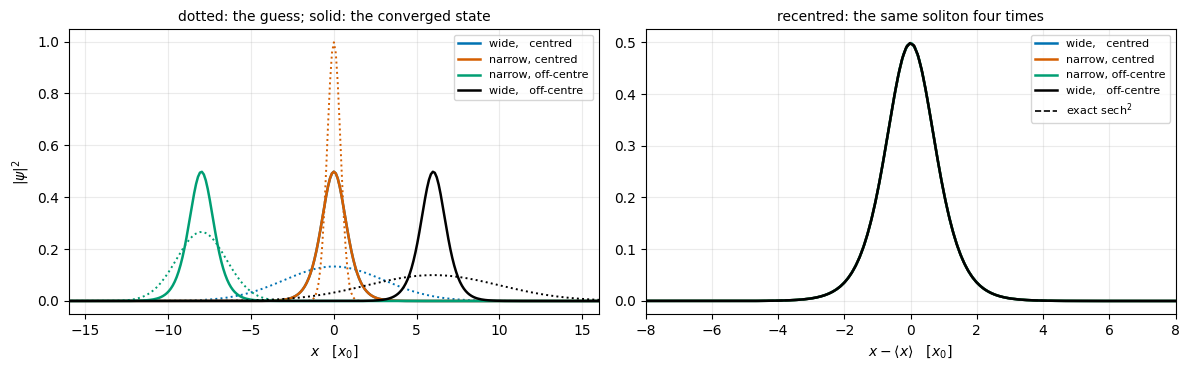

In [25]:
# ==============================================================================
# DEMONSTRATION 6: four different guesses, four identical solitons in four places
# ==============================================================================
guess_list = [("wide,   centred", 0.0, 3.0), ("narrow, centred", 0.0, 0.4),
              ("narrow, off-centre", -8.0, 1.5), ("wide,   off-centre", 6.0, 4.0)]
n_steps_it = int(round(TAU_MAX / DTAU))

fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.8))
print(f"{'initial guess':22s} {'x_c(0)':>8s} {'sigma(0)':>9s} {'<x> final':>12s} {'E final':>14s} "
      f"{'|| |psi|-sech ||':>18s}")
for (tag, xc0, sg0), col in zip(guess_list, [C_NUM, C_ANA, C_THIRD, "k"]):
    g0 = jnp.asarray(normalise(gaussian_packet(x, sg0, x_c=xc0), dx))
    pf, _ = imaginary_time_ground_state(g0, jnp.asarray(k), dx, G, V_ZERO, DTAU, n_steps_it)
    pf = np.asarray(pf)
    xbar = mean_position(pf, x, dx, L)
    err_shape = np.sqrt(dx * np.sum((np.abs(pf) - np.abs(soliton_exact(x, g=G, x_c=xbar))) ** 2))
    print(f"{tag:22s} {xc0:8.2f} {sg0:9.2f} {xbar:12.6f} {gp_energy(pf, k, dx, G):14.9f} {err_shape:18.3e}")
    axes[0].plot(x, np.abs(np.asarray(g0)) ** 2, lw=1.4, color=col, ls=":")
    axes[0].plot(x, np.abs(pf) ** 2, lw=1.8, color=col, label=tag)
    axes[1].plot(x - xbar, np.abs(pf) ** 2, lw=1.8, color=col, label=tag)
    assert abs(xbar - xc0) < 1e-4, "the soliton stays where the guess put it"
axes[1].plot(x, phi_ref ** 2, "k--", lw=1.2, label=r"exact $\mathrm{sech}^2$")
axes[0].set_xlim(-16, 16), axes[0].set_xlabel(r"$x$   [$x_0$]"), axes[0].set_ylabel(r"$|\psi|^2$")
axes[0].set_title("dotted: the guess; solid: the converged state", fontsize=10)
axes[0].grid(alpha=0.25), axes[0].legend(fontsize=8)
axes[1].set_xlim(-8, 8), axes[1].set_xlabel(r"$x-\langle x\rangle$   [$x_0$]")
axes[1].set_title("recentred: the same soliton four times", fontsize=10)
axes[1].grid(alpha=0.25), axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

Four guesses differing by a factor of ten in width and by $14$ length units in position converge to the same
energy, $-0.16666530$, to nine digits, and to profiles that coincide with the exact $\mathrm{sech}$ after
recentring. What does *not* converge to a common value is the position: each run keeps the centre of its own
guess to better than $10^{-4}$. The physics is degenerate and the algorithm inherits the degeneracy.

> **Physics insight.** A zero mode is not a numerical nuisance; it is a Goldstone mode. The soliton breaks
> the continuous translational symmetry of Eq. (8), so there is a family of solutions costing no energy, and
> exciting it at wavenumber $q\to0$ costs energy $\to 0$. In an experiment that mode is the free motion of
> the centre of mass, which is exactly the $k_0^{2}/2$ of Eq. (28).

### 8.5 Repulsive interactions: no soliton at all

For $g < 0$ the argument of Section 5.1 collapses: Eq. (20) has no turning point, the mechanical analogue
never comes back, and there is no localised solution. On a ring the minimiser of the energy is then the state
that spreads the density as uniformly as possible, $\psi = 1/\sqrt L$, with

$$ E = -\frac{g}{2}\cdot L\cdot\frac{1}{L^{2}} = -\frac{g}{2L} , \qquad \mu = -\frac{g}{L} = 2E , $$

both positive for $g<0$, and $E_{\rm kin} = 0$ exactly.

g = -2.0 on a ring of L = 20.0, relaxed to tau = 150.0:
   E  = 0.050000000000   uniform -g/(2L) = 0.050000000000
   mu = 0.100000000000   uniform -g/L    = 0.100000000000
   max | |psi| - 1/sqrt(L) | = 1.626e-14
CHECKPOINT 10 passed: for g < 0 the ground state is uniform, not localised.


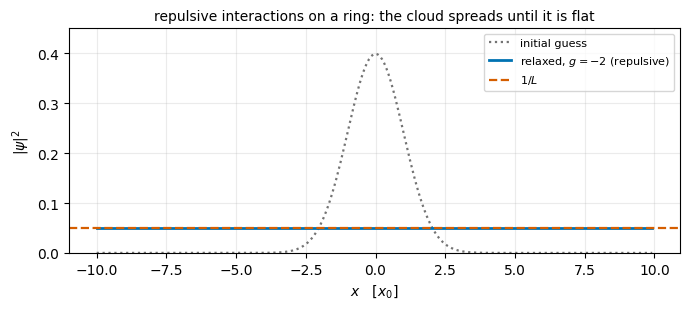

In [26]:
# ==============================================================================
# DEMONSTRATION 7: the same code with g < 0 relaxes to the uniform state
#   A smaller ring is used because the relaxation rate towards the uniform state is set
#   by the longest wavelength that fits, and on L = 60 it would take tau ~ 10^3.
# ==============================================================================
L_REP, N_REP, G_REP, TAU_REP = 20.0, 256, -2.0, 150.0
x_r, k_r, dx_r = make_grid(L_REP, N_REP)
psi_rep, _ = imaginary_time_ground_state(jnp.asarray(normalise(gaussian_packet(x_r, 1.0), dx_r)),
                                         jnp.asarray(k_r), dx_r, G_REP, jnp.zeros(N_REP, dtype=RDTYPE),
                                         DTAU, int(round(TAU_REP / DTAU)))
p_rep = np.asarray(psi_rep)
E_uni, mu_uni = -G_REP / (2 * L_REP), -G_REP / L_REP
print(f"g = {G_REP} on a ring of L = {L_REP}, relaxed to tau = {TAU_REP}:")
print(f"   E  = {gp_energy(p_rep, k_r, dx_r, G_REP):.12f}   uniform -g/(2L) = {E_uni:.12f}")
print(f"   mu = {gp_chemical_potential(p_rep, k_r, dx_r, G_REP):.12f}   uniform -g/L    = {mu_uni:.12f}")
print(f"   max | |psi| - 1/sqrt(L) | = {np.max(np.abs(np.abs(p_rep) - 1 / np.sqrt(L_REP))):.3e}")
assert np.max(np.abs(np.abs(p_rep) - 1 / np.sqrt(L_REP))) < 1e-9
print("CHECKPOINT 10 passed: for g < 0 the ground state is uniform, not localised.")

fig, ax = plt.subplots(figsize=(7.0, 3.2))
ax.plot(x_r, np.abs(normalise(gaussian_packet(x_r, 1.0), dx_r)) ** 2, ls=":", color=C_GREY, lw=1.6,
        label=r"initial guess")
ax.plot(x_r, np.abs(p_rep) ** 2, color=C_NUM, lw=2.0, label=rf"relaxed, $g={G_REP:g}$ (repulsive)")
ax.axhline(1 / L_REP, color=C_ANA, ls="--", lw=1.6, label=r"$1/L$")
ax.set_xlabel(r"$x$   [$x_0$]"), ax.set_ylabel(r"$|\psi|^2$")
ax.set_title("repulsive interactions on a ring: the cloud spreads until it is flat", fontsize=10)
ax.set_ylim(0, 0.45), ax.grid(alpha=0.25), ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The same six lines of code, with the sign of one parameter changed, produce the opposite physics: the cloud
flattens onto $1/L$ to $2\times10^{-14}$, and the energy and chemical potential match $-g/(2L)$ and $-g/L$ to
eight digits, with $\mu = 2E$ because $E_{\rm kin}$ vanishes identically for a constant profile. On an
infinite line the uniform state has zero density and $E\to0$: there is no bound state, and a repulsive gas
released from a trap simply expands. Dark solitons — density *notches* on a uniform background — are the
localised objects of the repulsive case, and Exercise 4 constructs one.

## 9. Real-time evolution

### 9.1 Why not Runge-Kutta

Notebook 00b integrated the Schrödinger equation with fourth-order Runge-Kutta and found a hard stability
limit (Press *et al.*, *Numerical Recipes*, Chapters 17 and 20, treat the stability of explicit schemes; the
Fortran 90 volume gives the corresponding array-based routines). The argument is worth repeating because it decides the choice of method here. Applying an explicit
integrator to $\dot y = \lambda y$ multiplies $y$ by an amplification factor $R(\lambda\Delta t)$; for RK4,

$$ R(z) \;=\; 1 + z + \frac{z^{2}}{2} + \frac{z^{3}}{6} + \frac{z^{4}}{24} . $$

For the Schrödinger equation $\lambda = -iE$ is purely imaginary, so $z = -i\theta$ with
$\theta = E\Delta t$ real, and $\vert R(-i\theta)\vert \le 1$ holds only for

$$ \theta \;\le\; 2\sqrt2 \;\approx\; 2.828 \qquad\Longrightarrow\qquad
   \Delta t \;\le\; \frac{2\sqrt2}{E_{\max}} . \tag{42} $$

Every mode of the discretised Hamiltonian must satisfy this, so $E_{\max}$ is the largest energy the *grid*
can represent. With the three-point Laplacian of 00b, $E_{\max} = 2/\Delta x^{2}$ and
$\Delta t \le \sqrt2\,\Delta x^{2}$ — the rule of thumb "the time step must be smaller than $\Delta x^{2}$".
With the **spectral** Laplacian used here the grid reaches all the way to the Nyquist wave number, so
$E_{\max} = (\pi/\Delta x)^{2}/2$ and the limit is *tighter*,

$$ \Delta t \;\le\; \frac{4\sqrt2}{\pi^{2}}\,\Delta x^{2} \;\approx\; 0.573\,\Delta x^{2} . \tag{43} $$

This has nothing to do with accuracy: above the limit the highest-$k$ modes are amplified every step, and the
calculation explodes no matter how smooth the physics is. Refining the grid by two makes the affordable time
step four times smaller, which is the reason explicit integrators are rarely used for wave equations.

The nonlinearity does not move the limit. The largest value the interaction term can take is
$g\vert\psi\vert^{2}_{\max} = g\cdot g/4 = 1$ for our soliton, against $E_{\max} = 359$ from the grid: a
shift of $0.3\,\%$. The cliff measured below therefore tests Eq. (43) itself, not some nonlinear correction
to it.

The Strang product of Eq. (35) has no such limit. Each of its three factors is a multiplication by a number
of modulus one — $e^{-ik^{2}\Delta t/4}$ in Fourier space, $e^{i(g\vert\psi\vert^{2}-V)\Delta t}$ in position
space — so the map is **unitary for every $\Delta t$**, the norm is conserved exactly, and nothing can grow.
The time step is then chosen by accuracy alone.

In [27]:
# ==============================================================================
# DEMONSTRATION 8: the RK4 stability cliff, and the absence of one for split-step
#   Both integrators are given the same boosted soliton and the same total time T = 2.
# ==============================================================================
@partial(jax.jit, static_argnames=("n_steps",))
def rk4_evolve(psi, k, g, V, dt, n_steps):
    """Classical fourth-order Runge-Kutta applied to i dpsi/dt = H_GP[psi] psi (matrix-free).

    MATH
        dpsi/dt = F(psi) = -i ( -(1/2) psi'' - g |psi|^2 psi + V psi )
        psi <- psi + (dt/6)(F1 + 2 F2 + 2 F3 + F4)      the standard RK4 tableau
    STABILITY
        |R(-i theta)| <= 1 only for theta = E dt <= 2 sqrt(2)  -- Eq. (42).
    """
    def F(p):
        return -1j * (jnp.fft.ifft(0.5 * k ** 2 * jnp.fft.fft(p)) - g * jnp.abs(p) ** 2 * p + V * p)

    def step(p, _):
        f1 = F(p); f2 = F(p + 0.5 * dt * f1); f3 = F(p + 0.5 * dt * f2); f4 = F(p + dt * f3)
        return p + (dt / 6.0) * (f1 + 2 * f2 + 2 * f3 + f4), None

    return lax.scan(step, psi, None, length=n_steps)[0]


def _split_step_body(k, g, V, dt):
    """One Strang step in REAL time -- Eq. (35) with h -> i dt. Each factor has modulus one."""
    exp_kin = jnp.exp(-0.25j * k ** 2 * dt)             # exp(-i (k^2/2)(dt/2))

    def step(psi, _):
        psi = jnp.fft.ifft(exp_kin * jnp.fft.fft(psi))                  # kinetic half step
        psi = psi * jnp.exp(1j * (g * jnp.abs(psi) ** 2 - V) * dt)      # nonlinear + potential full step
        return jnp.fft.ifft(exp_kin * jnp.fft.fft(psi)), None           # kinetic half step
    return step


@partial(jax.jit, static_argnames=("n_steps",))
def split_step_evolve(psi, k, g, V, dt, n_steps):
    """Propagate psi by n_steps * dt with the unitary Strang split-step Fourier method.

    MATH
        psi(t+dt) = exp(-i T dt/2) exp(-i W dt) exp(-i T dt/2) psi(t) + O(dt^3),  W = V - g|psi|^2
    IMPLEMENTATION
        The x-space factor is a pure phase, so it does NOT change |psi|^2: freezing the density
        during that substep is EXACT, unlike in imaginary time (Section 8.2).
    COST
        2 FFTs per step, O(N_x log N_x); no linear system, no matrix, no stability limit.
    """
    return lax.scan(_split_step_body(k, g, V, dt), psi, None, length=n_steps)[0]


@partial(jax.jit, static_argnames=("n_inner", "n_frames"))
def split_step_frames(psi, k, g, V, dt, n_inner, n_frames):
    """Same propagation, returning a snapshot every n_inner steps: shape (n_frames+1, N_x)."""
    step = _split_step_body(k, g, V, dt)

    def outer(psi, _):
        psi, _ = lax.scan(step, psi, None, length=n_inner)
        return psi, psi

    _, frames = lax.scan(outer, psi, None, length=n_frames)
    return jnp.concatenate([psi[None, :], frames], axis=0)


K0 = 2.0 * np.pi * 10 / L                      # commensurate kick, 10 wavelengths around the ring
psi_move0 = jnp.asarray(soliton_exact(x, g=G, x_c=-15.0, k_0=K0))
E_MAX = (np.pi / dx) ** 2 / 2.0
DT_RK4_LIMIT = 2.0 * np.sqrt(2.0) / E_MAX
T_STAB = 2.0

print(f"dx = {dx:.6f}, dx^2 = {dx ** 2:.6e}")
print(f"E_max = (pi/dx)^2/2 = {E_MAX:.2f}  ->  RK4 limit dt = 2 sqrt(2)/E_max = {DT_RK4_LIMIT:.6f} "
      f"= {DT_RK4_LIMIT / dx ** 2:.4f} dx^2   (Eq. (43) predicts 0.5732)")
print(f"\n{'method':12s} {'dt':>9s} {'dt/dx^2':>9s} {'dt/dt_limit':>12s} {'norm after T=2':>18s}")
for dt_try in (0.004, 0.006, 0.0075, 0.008, 0.009, 0.012):
    p = np.asarray(rk4_evolve(psi_move0, jnp.asarray(k), G, V_ZERO, dt_try, int(round(T_STAB / dt_try))))
    print(f"{'RK4':12s} {dt_try:9.4f} {dt_try / dx ** 2:9.3f} {dt_try / DT_RK4_LIMIT:12.3f} "
          f"{grid_norm(p, dx):18.6e}")
for dt_try in (0.02, 0.05, 0.1):
    p = np.asarray(split_step_evolve(psi_move0, jnp.asarray(k), G, V_ZERO, dt_try,
                                     int(round(T_STAB / dt_try))))
    print(f"{'split-step':12s} {dt_try:9.4f} {dt_try / dx ** 2:9.3f} {dt_try / DT_RK4_LIMIT:12.3f} "
          f"{grid_norm(p, dx):18.12f}")

p_ok = np.asarray(rk4_evolve(psi_move0, jnp.asarray(k), G, V_ZERO, 0.0075, int(round(T_STAB / 0.0075))))
p_bad = np.asarray(rk4_evolve(psi_move0, jnp.asarray(k), G, V_ZERO, 0.008, int(round(T_STAB / 0.008))))
assert abs(grid_norm(p_ok, dx) - 1) < 1e-6, "RK4 must be stable just below the limit"
assert grid_norm(p_bad, dx) > 10.0, "RK4 must blow up just above the limit"
assert abs(grid_norm(np.asarray(split_step_evolve(psi_move0, jnp.asarray(k), G, V_ZERO, 0.1, 20)), dx) - 1) < 1e4 * TOL
print("\nCHECKPOINT 11 passed: the RK4 cliff sits where Eq. (43) puts it; split-step has none.")

dx = 0.117188, dx^2 = 1.373291e-02
E_max = (pi/dx)^2/2 = 359.34  ->  RK4 limit dt = 2 sqrt(2)/E_max = 0.007871 = 0.5732 dx^2   (Eq. (43) predicts 0.5732)

method              dt   dt/dx^2  dt/dt_limit     norm after T=2


RK4             0.0040     0.291        0.508       1.000000e+00


RK4             0.0060     0.437        0.762       1.000000e+00
RK4             0.0075     0.546        0.953       1.000000e+00


RK4             0.0080     0.583        1.016       3.819622e+01


RK4             0.0090     0.655        1.143       6.570281e+02
RK4             0.0120     0.874        1.525                nan


split-step      0.0200     1.456        2.541     1.000000000000


split-step      0.0500     3.641        6.352     1.000000000000
split-step      0.1000     7.282       12.705     1.000000000000

CHECKPOINT 11 passed: the RK4 cliff sits where Eq. (43) puts it; split-step has none.


The predicted limit is $\Delta t = 0.007871 = 0.5732\,\Delta x^{2}$, and the measured behaviour is a cliff,
not a slope: at $\Delta t = 0.0075$ RK4 conserves the norm to the seven digits printed, at
$\Delta t = 0.0080$ the norm has grown to $38$ after two time units, at $0.0090$ to $657$, and at $0.012$ it
is `nan`. Split-step conserves the norm to twelve digits at $\Delta t = 0.1$, thirteen times past the RK4
limit, and would do so at any $\Delta t$ whatsoever.

> **Numerical practice.** Unconditional stability is not the same as accuracy. Split-step at $\Delta t = 0.1$
> conserves the norm exactly and gets the *physics* wrong; the norm is conserved by construction and
> therefore proves nothing about the solution. Convergence must still be demonstrated, which is what
> Section 9.5 does.

### 9.2 Test 1: the ground state does nothing

The first thing to do with a new propagator is to give it a state whose evolution is known exactly. The
imaginary-time ground state of Section 8 should, by Eq. (15), only acquire a phase:

$$ \psi(x,t) = \phi(x)\,e^{-i\mu t} \qquad\Longrightarrow\qquad
   \vert\psi(x,t)\vert^{2} = \vert\phi(x)\vert^{2}\ \text{for all } t , \qquad
   \arg\psi(x_c,t) = \arg\psi(x_c,0) - \mu t . $$

Two measurements: the drift of the density, and the rate at which the phase winds. The second returns $\mu$
without ever computing an expectation value.

In [28]:
# ==============================================================================
# CHECKPOINT 12: the exact soliton is stationary; the phase winds at the rate mu
# ==============================================================================
T_STAT, N_STAT = 20.0, 20
psi_stat0 = jnp.asarray(soliton_exact(x, g=G))

print(f"{'dt':>9s} {'max |density(t)-density(0)|':>30s} {'phase rate':>13s} {'|rate - (-mu)|':>16s} "
      f"{'norm drift':>12s}")
drifts = []
for dt_try in (0.004, 0.002, 0.001, 0.0005):
    fr = np.asarray(split_step_frames(psi_stat0, jnp.asarray(k), G, V_ZERO, dt_try,
                                      int(round((T_STAT / N_STAT) / dt_try)), N_STAT))
    dens = np.abs(fr) ** 2
    drift = float(np.max(np.abs(dens - dens[0])))
    j_peak = int(np.argmax(np.abs(fr[0])))
    phase = np.unwrap(np.angle(fr[:, j_peak]))
    t_fr = np.arange(N_STAT + 1) * (T_STAT / N_STAT)
    rate = float(np.polyfit(t_fr, phase, 1)[0])
    drifts.append(drift)
    print(f"{dt_try:9.5f} {drift:30.3e} {rate:13.9f} {abs(rate - G ** 2 / 8):16.3e} "
          f"{abs(grid_norm(fr[-1], dx) - 1):12.2e}")

order = np.polyfit(np.log([0.004, 0.002, 0.001, 0.0005]), np.log(drifts), 1)[0]
print(f"\nfitted order of the density drift in dt: {order:.3f}   (Strang predicts 2)")
assert abs(order - 2.0) < 0.15 and drifts[-1] < 1e-7
print("CHECKPOINT 12 passed: the soliton is stationary up to the O(dt^2) splitting error,")
print("                      and the measured phase rate equals -mu = g^2/8.")

       dt    max |density(t)-density(0)|    phase rate   |rate - (-mu)|   norm drift


  0.00400                      1.241e-06   0.499998569        1.431e-06     7.00e-13


  0.00200                      3.102e-07   0.499999642        3.578e-07     1.50e-12


  0.00100                      7.755e-08   0.499999911        8.946e-08     2.82e-12


  0.00050                      1.939e-08   0.499999978        2.236e-08     6.26e-12

fitted order of the density drift in dt: 2.000   (Strang predicts 2)
CHECKPOINT 12 passed: the soliton is stationary up to the O(dt^2) splitting error,
                      and the measured phase rate equals -mu = g^2/8.


The density does not move: at $\Delta t = 5\times10^{-4}$ the largest change anywhere on the grid over
$20$ time units is $1.9\times10^{-8}$, and the drift falls with the fitted power $2.000$ of $\Delta t$ — the
Strang error of Eq. (36), not an instability. The phase at the peak advances at $0.499999978$ per unit time
against the predicted $-\mu = g^{2}/8 = 0.5$, an error of $2.2\times10^{-8}$ that also falls as
$\Delta t^{2}$, and the norm is conserved to $6\times10^{-12}$.

The soliton is therefore a genuine stationary state of the *time-dependent* equation, found by a completely
different algorithm from the one that produced it.

### 9.3 Test 2: a soliton that moves, and a linear packet that does not survive

Apply the Galilean boost of Section 5.8 by multiplying the profile by $e^{ik_0x}$, with $k_0$ commensurate
with the ring ($k_0 = 2\pi\times10/L$, rule 1 of notebook 00a). Equations (27) and (28) predict a centre
moving at exactly $k_0$, a constant variance, a constant momentum and an energy $-g^{2}/24 + k_0^{2}/2$.

The comparison that makes the point is to propagate the **same initial state** with $g$ set to zero. That is
the free Schrödinger equation of 00a, whose exact solution predicts ballistic spreading,
$\mathrm{Var}(x)(t) = \mathrm{Var}(x)(0) + \mathrm{Var}(p)\,t^{2}$. For the $\mathrm{sech}$ profile the
momentum variance can be computed in closed form from
$\int(\phi')^{2}dx = 2E_{\rm kin} = g^{2}/12$, giving

$$ \mathrm{Var}(p) \;=\; \langle p^{2}\rangle - \langle p\rangle^{2} \;=\; \frac{g^{2}}{12} , \tag{44} $$

since $\langle p^{2}\rangle = \int\vert\phi'\vert^{2}dx + k_0^{2}$ and $\langle p\rangle = k_0$.

In [29]:
# ==============================================================================
# PARAMETERS of the real-time runs
# ==============================================================================
DT      = 0.001      # real-time step (3300 times the RK4 limit is available, accuracy decides)
T_MAX   = 24.0       # final time
N_MOVIE = 48         # snapshots

n_inner_rt = int(round((T_MAX / N_MOVIE) / DT))
t_fr = np.arange(N_MOVIE + 1) * (T_MAX / N_MOVIE)
print(f"k_0 = 2 pi * 10 / L = {K0:.6f}; the soliton covers k_0 T = {K0 * T_MAX:.2f} length units "
      f"= {K0 * T_MAX / L:.2f} laps in T = {T_MAX}")
print(f"dt = {DT} = {DT / dx ** 2:.2f} dx^2 = {DT / DT_RK4_LIMIT:.2f} times the RK4 stability limit")

k_0 = 2 pi * 10 / L = 1.047198; the soliton covers k_0 T = 25.13 length units = 0.42 laps in T = 24.0
dt = 0.001 = 0.07 dx^2 = 0.13 times the RK4 stability limit


In [30]:
# ==============================================================================
# THE RUN: the same initial profile, with (g = 2) and without (g = 0) interactions
# ==============================================================================
t_wall = time.time()
fr_sol = np.asarray(split_step_frames(psi_move0, jnp.asarray(k), G, V_ZERO, DT, n_inner_rt, N_MOVIE))
fr_lin = np.asarray(split_step_frames(psi_move0, jnp.asarray(k), 0.0, V_ZERO, DT, n_inner_rt, N_MOVIE))
print(f"2 x {int(T_MAX / DT)} real-time steps (compile + run): {time.time() - t_wall:.2f} s")

def unwrapped_mean(frames_arr):
    """<x>(t) on the ring, unwrapped so that it is a straight line instead of a saw-tooth."""
    raw = np.array([mean_position(p, x, dx, L) for p in frames_arr])
    return np.unwrap(raw * 2 * np.pi / L) * L / (2 * np.pi)

xbar_sol, xbar_lin = unwrapped_mean(fr_sol), unwrapped_mean(fr_lin)
var_sol = np.array([position_variance(p, x, dx, L) for p in fr_sol])
var_lin = np.array([position_variance(p, x, dx, L) for p in fr_lin])
p_sol = np.array([mean_momentum(p, k) for p in fr_sol])
E_sol_t = np.array([gp_energy(p, k, dx, G) for p in fr_sol])
nrm_sol = np.array([grid_norm(p, dx) for p in fr_sol])

var0 = np.pi ** 2 / (3 * G ** 2)
var_p = G ** 2 / 12.0
v_fit = np.polyfit(t_fr, xbar_sol, 1)[0]

print(f"\nvelocity  : fitted {v_fit:.12f}, exact k_0 = {K0:.12f}, error {abs(v_fit - K0):.2e}")
print(f"Var(x)    : t=0 {var_sol[0]:.10f}, t=T {var_sol[-1]:.10f}, exact pi^2/(3g^2) = {var0:.10f}")
print(f"            max deviation over the run: {np.max(np.abs(var_sol - var0)):.2e}")
print(f"<p>       : mean {p_sol.mean():.12f}, max deviation from k_0: {np.max(np.abs(p_sol - K0)):.2e}")
print(f"E         : {E_sol_t[-1]:.12f}, exact -g^2/24 + k_0^2/2 = {-G ** 2 / 24 + K0 ** 2 / 2:.12f}")
print(f"conserved : max |norm-1| {np.max(np.abs(nrm_sol - 1)):.2e}, "
      f"max |E(t)-E(0)| {np.max(np.abs(E_sol_t - E_sol_t[0])):.2e}, "
      f"max |<p>(t)-<p>(0)| {np.max(np.abs(p_sol - p_sol[0])):.2e}")
print(f"\nlinear run: Var(x) grows from {var_lin[0]:.4f} to {var_lin[-1]:.4f}, "
      f"width ratio {np.sqrt(var_lin[-1] / var_lin[0]):.2f}")
# the wrapped-distance variance saturates once the packet is no longer narrow compared with the ring,
# so the ballistic law can only be tested while sqrt(Var) stays well below L: the criterion used
# here is sigma < 0.07 L, beyond which the wrapping bias exceeds 1e-4 and then grows fast
ok_ballistic = np.sqrt(var_lin) < 0.07 * L
i_last = int(np.max(np.where(ok_ballistic)[0]))
print(f"            ballistic law Var(0) + Var(p) t^2 with Var(p) = g^2/12 = {var_p:.4f}:")
print(f"            at t = {t_fr[i_last]:.1f} (sigma = {np.sqrt(var_lin[i_last]):.2f} < 0.07 L = {0.07 * L:.2f}): "
      f"measured {var_lin[i_last]:.4f}, predicted {var0 + var_p * t_fr[i_last] ** 2:.4f}, "
      f"relative error {abs(var_lin[i_last] / (var0 + var_p * t_fr[i_last] ** 2) - 1):.2e}")
print(f"            at t = {T_MAX:.1f} the packet fills the ring: measured {var_lin[-1]:.1f} vs "
      f"predicted {var0 + var_p * T_MAX ** 2:.1f} -- the wrapped-distance variance has saturated")
assert abs(var_lin[i_last] / (var0 + var_p * t_fr[i_last] ** 2) - 1) < 1e-3,\
    "while the free packet is narrow compared with the ring it must follow the ballistic law"

assert abs(v_fit - K0) < 1e-9 and np.max(np.abs(var_sol - var0)) < 1e-5
assert np.max(np.abs(nrm_sol - 1)) < 1e4 * TOL
assert var_lin[-1] > 50 * var_sol[-1], "without interactions the same profile must spread"
print("\nCHECKPOINT 13 passed: Eqs. (27) and (28) hold; the linear packet does not.")

2 x 24000 real-time steps (compile + run): 1.08 s

velocity  : fitted 1.047197551207, exact k_0 = 1.047197551197, error 1.08e-11
Var(x)    : t=0 0.8224670334, t=T 0.8224672319, exact pi^2/(3g^2) = 0.8224670334
            max deviation over the run: 3.66e-07
<p>       : mean 1.047197551196, max deviation from k_0: 5.66e-13
E         : 0.381644688950, exact -g^2/24 + k_0^2/2 = 0.381644688949
conserved : max |norm-1| 7.05e-13, max |E(t)-E(0)| 5.44e-13, max |<p>(t)-<p>(0)| 5.61e-13

linear run: Var(x) grows from 0.8225 to 157.1055, width ratio 13.82
            ballistic law Var(0) + Var(p) t^2 with Var(p) = g^2/12 = 0.3333:
            at t = 7.0 (sigma = 4.14 < 0.07 L = 4.20): measured 17.1550, predicted 17.1558, relative error 4.42e-05
            at t = 24.0 the packet fills the ring: measured 157.1 vs predicted 192.8 -- the wrapped-distance variance has saturated

CHECKPOINT 13 passed: Eqs. (27) and (28) hold; the linear packet does not.


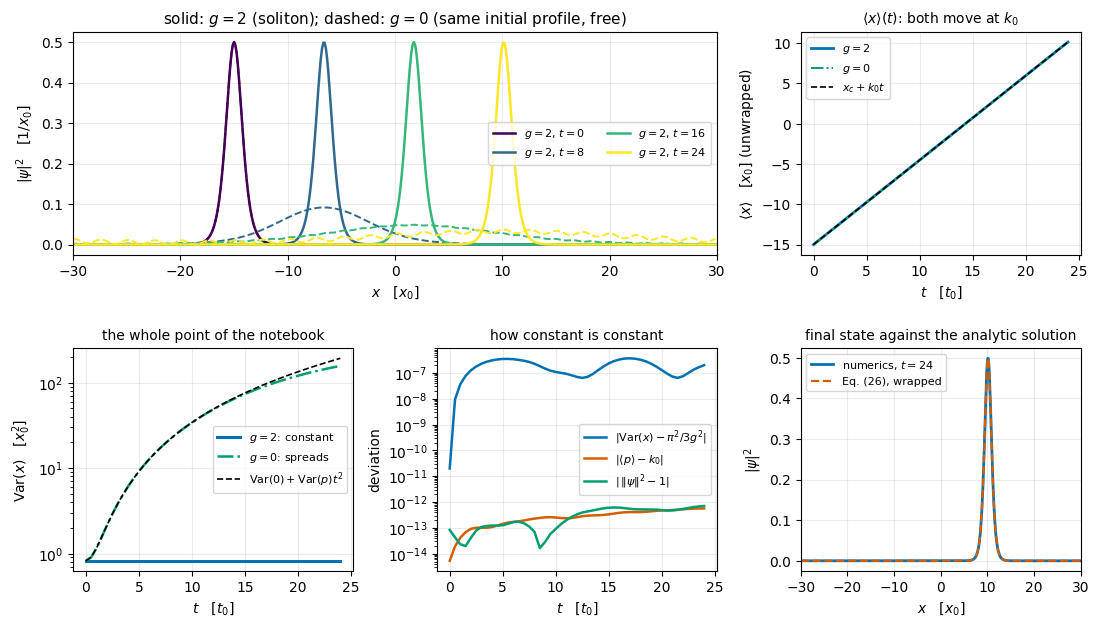

centre at t = 24.0: 10.133 (the ring is [-30, 30))
max | numerical density - analytic density, Eq. (26) | at t = 24.0: 8.065e-08


In [31]:
# ==============================================================================
# FIGURE: soliton versus free packet -- snapshots, <x>(t), Var(x)(t), conservation
# ==============================================================================
fig = plt.figure(figsize=(13.0, 7.0))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.30)

ax = fig.add_subplot(gs[0, :2])
for j, idx in enumerate([0, 16, 32, 48]):
    ax.plot(x, np.abs(fr_sol[idx]) ** 2, lw=1.8, color=cmap(j / 3), label=rf"$g=2$, $t={t_fr[idx]:.0f}$")
    ax.plot(x, np.abs(fr_lin[idx]) ** 2, lw=1.4, ls="--", color=cmap(j / 3))
ax.set_xlabel(r"$x$   [$x_0$]"), ax.set_ylabel(r"$|\psi|^2$   [$1/x_0$]")
ax.set_title(r"solid: $g=2$ (soliton); dashed: $g=0$ (same initial profile, free)", fontsize=11)
ax.set_xlim(-L / 2, L / 2), ax.grid(alpha=0.25), ax.legend(fontsize=8, ncol=2)

ax = fig.add_subplot(gs[0, 2])
ax.plot(t_fr, xbar_sol, color=C_NUM, lw=2.0, label=r"$g=2$")
ax.plot(t_fr, xbar_lin, color=C_THIRD, lw=1.4, ls="-.", label=r"$g=0$")
ax.plot(t_fr, -15.0 + K0 * t_fr, "k--", lw=1.2, label=r"$x_c+k_0t$")
ax.set_xlabel(r"$t$   [$t_0$]"), ax.set_ylabel(r"$\langle x\rangle$   [$x_0$] (unwrapped)")
ax.set_title(r"$\langle x\rangle(t)$: both move at $k_0$", fontsize=10)
ax.grid(alpha=0.25), ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 0])
ax.plot(t_fr, var_sol, color=C_NUM, lw=2.2, label=r"$g=2$: constant")
ax.plot(t_fr, var_lin, color=C_THIRD, lw=1.8, ls="-.", label=r"$g=0$: spreads")
ax.plot(t_fr, var0 + var_p * t_fr ** 2, "k--", lw=1.2, label=r"$\mathrm{Var}(0)+\mathrm{Var}(p)t^2$")
ax.set_yscale("log"), ax.set_xlabel(r"$t$   [$t_0$]"), ax.set_ylabel(r"$\mathrm{Var}(x)$   [$x_0^2$]")
ax.set_title("the whole point of the notebook", fontsize=10)
ax.grid(alpha=0.25), ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 1])
ax.plot(t_fr, np.abs(var_sol - var0), color=C_NUM, lw=1.8, label=r"$|\mathrm{Var}(x)-\pi^2/3g^2|$")
ax.plot(t_fr, np.abs(p_sol - K0) + 1e-18, color=C_ANA, lw=1.8, label=r"$|\langle p\rangle-k_0|$")
ax.plot(t_fr, np.abs(nrm_sol - 1) + 1e-18, color=C_THIRD, lw=1.8, label=r"$|\,\Vert\psi\Vert^2-1|$")
ax.set_yscale("log"), ax.set_xlabel(r"$t$   [$t_0$]"), ax.set_ylabel("deviation")
ax.set_title("how constant is constant", fontsize=10), ax.grid(alpha=0.25), ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 2])
ax.plot(x, np.abs(fr_sol[-1]) ** 2, color=C_NUM, lw=2.0, label=rf"numerics, $t={T_MAX:g}$")
ax.plot(x, np.abs(soliton_exact(x, T_MAX, G, x_c=-15.0, k_0=K0)) ** 2, color=C_ANA, ls="--", lw=1.6,
        label="Eq. (26), wrapped")
ax.set_xlim(-L / 2, L / 2), ax.set_xlabel(r"$x$   [$x_0$]"), ax.set_ylabel(r"$|\psi|^2$")
ax.set_title("final state against the analytic solution", fontsize=10)
ax.grid(alpha=0.25), ax.legend(fontsize=8)
plt.show()

# at t = T_MAX the centre sits at x_c + k_0 T = -15 + 25.13 = 10.13, comfortably inside the ring,
# so Eq. (26) can be compared point by point without worrying about periodic images.
err_final = float(np.max(np.abs(np.abs(fr_sol[-1]) ** 2
                                - np.abs(soliton_exact(x, T_MAX, G, x_c=-15.0, k_0=K0)) ** 2)))
print(f"centre at t = {T_MAX}: {-15.0 + K0 * T_MAX:.3f} (the ring is [{-L / 2:.0f}, {L / 2:.0f}))")
print(f"max | numerical density - analytic density, Eq. (26) | at t = {T_MAX}: {err_final:.3e}")
assert err_final < 1e-6, "the propagated soliton must match the closed-form solution"

### 9.4 A state that is not a soliton

Section 6.6 claimed that the soliton is an attractor. The test: start from the best *Gaussian*, the
variational winner of Section 6.1 with $\sigma_{*} = \sqrt\pi/g$, which overlaps the true soliton by
$0.9972$ and has an energy $4.5\%$ above it. Inverse-scattering theory says the initial condition decomposes
into a soliton plus radiation; the radiation is not bound, so it leaves the core and — on an infinite line —
would escape to infinity, leaving a soliton of slightly smaller norm behind.

Two diagnostics: the **peak density** $\max_x\vert\psi\vert^{2}$, which is $g/4$ for a soliton at rest and
oscillates while the packet breathes, and the fraction of the norm that stays within $\vert x\vert<6$, which
measures what has been shed. A second run with a Gaussian $1.6$ times too wide shows the same mechanism
further from equilibrium. On a ring the radiation cannot escape, so expect it to come back.

best Gaussian, $\sigma_*=\sqrt{\pi}/g$ E = -0.159155 (soliton -0.166667); peak density in [0.4502, 0.5366] around g/4 = 0.5000
                                   shed out of |x|<6: 0.39% by t=5, 0.45% by t=20, 0.42% by t=60


$1.6\,\sigma_*$                    E = -0.136774 (soliton -0.166667); peak density in [0.2813, 0.5670] around g/4 = 0.5000
                                   shed out of |x|<6: 0.51% by t=5, 3.49% by t=20, 4.14% by t=60


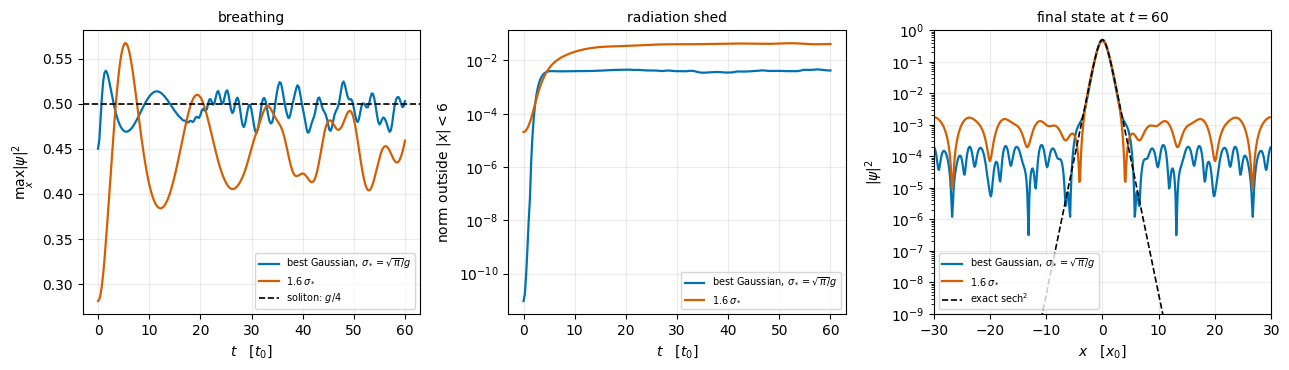

In [32]:
# ==============================================================================
# DEMONSTRATION 9: a Gaussian is not a soliton -- it breathes and radiates
# ==============================================================================
T_BREATH, N_BREATH = 60.0, 240
n_inner_b = int(round((T_BREATH / N_BREATH) / DT))
t_b = np.arange(N_BREATH + 1) * (T_BREATH / N_BREATH)
core_mask = np.abs(x) < 6.0
SIGMA_STAR = np.sqrt(np.pi) / G

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.8))
for (tag, sig_b, col) in [(r"best Gaussian, $\sigma_*=\sqrt{\pi}/g$", SIGMA_STAR, C_NUM),
                          (r"$1.6\,\sigma_*$", 1.6 * SIGMA_STAR, C_ANA)]:
    psi_b0 = jnp.asarray(normalise(gaussian_packet(x, sig_b), dx))
    fr_b = np.asarray(split_step_frames(psi_b0, jnp.asarray(k), G, V_ZERO, DT, n_inner_b, N_BREATH))
    peak = np.array([float(np.max(np.abs(p) ** 2)) for p in fr_b])
    core = np.array([float(dx * np.sum(np.abs(p[core_mask]) ** 2)) for p in fr_b])
    print(f"{tag:34s} E = {gp_energy(np.asarray(psi_b0), k, dx, G):+.6f} "
          f"(soliton {-G ** 2 / 24:+.6f}); peak density in [{peak.min():.4f}, {peak.max():.4f}] "
          f"around g/4 = {G / 4:.4f}")
    shed = 100.0 * (core[0] - core)
    print(f"{'':34s} shed out of |x|<6: {shed[np.argmax(t_b >= 5.0)]:.2f}% by t=5, "
          f"{shed[np.argmax(t_b >= 20.0)]:.2f}% by t=20, {shed[-1]:.2f}% by t={t_b[-1]:.0f}")
    axes[0].plot(t_b, peak, color=col, lw=1.6, label=tag)
    axes[1].plot(t_b, 1.0 - core, color=col, lw=1.6, label=tag)
    axes[2].plot(x, np.abs(fr_b[-1]) ** 2, color=col, lw=1.6, label=tag)

axes[0].axhline(G / 4, color="k", ls="--", lw=1.2, label=r"soliton: $g/4$")
axes[0].set_xlabel(r"$t$   [$t_0$]"), axes[0].set_ylabel(r"$\max_x|\psi|^2$")
axes[0].set_title("breathing", fontsize=10), axes[0].grid(alpha=0.25), axes[0].legend(fontsize=7)
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$t$   [$t_0$]"), axes[1].set_ylabel(r"norm outside $|x|<6$")
axes[1].set_title("radiation shed", fontsize=10), axes[1].grid(alpha=0.25), axes[1].legend(fontsize=7)
axes[2].plot(x, np.abs(soliton_exact(x, g=G)) ** 2, "k--", lw=1.2, label=r"exact $\mathrm{sech}^2$")
axes[2].set_yscale("log"), axes[2].set_ylim(1e-9, 1.0), axes[2].set_xlim(-L / 2, L / 2)
axes[2].set_xlabel(r"$x$   [$x_0$]"), axes[2].set_ylabel(r"$|\psi|^2$")
axes[2].set_title(rf"final state at $t={T_BREATH:g}$", fontsize=10)
axes[2].grid(alpha=0.25), axes[2].legend(fontsize=7)
fig.tight_layout()
plt.show()

The peak density oscillates instead of sitting at $g/4 = 0.5$: the state breathes. The best Gaussian stays
between $0.450$ and $0.537$, within $10\%$ of the soliton value; the $1.6\sigma_{*}$ Gaussian swings from
$0.281$ to $0.567$. The middle panel shows where the mismatch goes. The best Gaussian loses $0.39\%$ of its
norm out of $\vert x\vert<6$ within the first five time units and then stays between $0.42\%$ and
$0.45\%$: one burst, and it is over. The $1.6\sigma_{*}$ Gaussian is further from equilibrium and takes longer — $0.5\%$ by $t=5$,
$3.5\%$ by $t=20$, $4.1\%$ by $t=60$ — because each breathing cycle sheds a little more. That radiation
appears in the right panel as a rippled background four orders of magnitude below the peak for the best
Gaussian and three for the $1.6\sigma_{*}$ one, while
the central lump still lies on the dashed $\mathrm{sech}^{2}$ over four decades out to
$\vert x\vert\approx5$.

The oscillation does not visibly damp over $t = 60$, and that is a property of the *ring*: the radiation has
nowhere to go, wraps around and returns to the core. On an infinite line it would leave for good and the core
would relax onto an exact soliton. What the run does show is that the shedding happens once, quickly, and
then stops: the core is close to a fixed point and stays there.

Contrast this with the free packet of 00a, which has no preferred shape and simply keeps spreading. The
nonlinear equation has a shape it returns to.

### 9.5 Convergence in $\Delta t$, and what is conserved

The last two questions for any propagator: does it converge at the advertised rate, and does it conserve
what the equation conserves? The order is measured by comparing runs at several $\Delta t$ against a
reference run at a much smaller one, which is the standard procedure when no closed-form solution is
available — although here one is, so both references are used.

      dt   err vs dt=1e-4 run    ratio    err vs Eq. (26)      norm-1
  0.0800           9.3770e-04      nan         9.3771e-04   -8.30e-14
  0.0400           2.3505e-04    3.989         2.3505e-04   -8.35e-14
  0.0200           5.8801e-05    3.997         5.8803e-05   -8.18e-14


  0.0100           1.4702e-05    4.000         1.4706e-05   -7.87e-14
  0.0050           3.6744e-06    4.001         3.6866e-06   -6.37e-14

fitted order in dt: 1.9990   (Strang predicts 2)


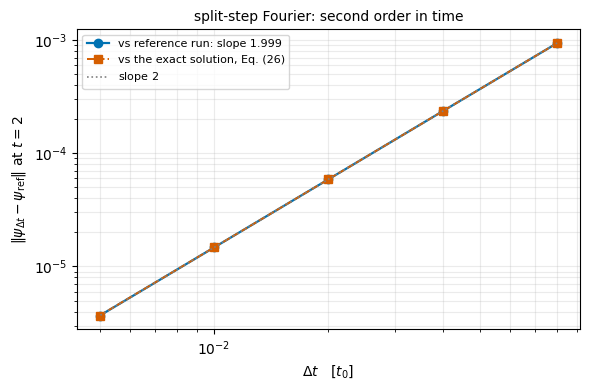


conservation over the main run (T = 24, dt = 0.001):
   norm       : max |N(t) - 1|        = 7.052e-13
   energy     : max |E(t) - E(0)|     = 5.441e-13
   momentum   : max |<p>(t) - <p>(0)| = 5.609e-13
   width      : max |Var(t) - Var(0)| = 3.663e-07


In [33]:
# ==============================================================================
# CHECKPOINT 14: order of the split-step method in dt, and the conservation laws
# ==============================================================================
T_CONV = 2.0
psi_ref = np.asarray(split_step_evolve(psi_move0, jnp.asarray(k), G, V_ZERO, 1e-4, int(round(T_CONV / 1e-4))))
psi_ana = soliton_exact(x, T_CONV, G, x_c=-15.0, k_0=K0)

dt_scan = np.array([0.08, 0.04, 0.02, 0.01, 0.005])
err_ref, err_ana = [], []
print(f"{'dt':>8s} {'err vs dt=1e-4 run':>20s} {'ratio':>8s} {'err vs Eq. (26)':>18s} {'norm-1':>11s}")
prev = None
for dt_try in dt_scan:
    p = np.asarray(split_step_evolve(psi_move0, jnp.asarray(k), G, V_ZERO, dt_try,
                                     int(round(T_CONV / dt_try))))
    e_r = float(np.sqrt(dx * np.sum(np.abs(p - psi_ref) ** 2)))
    e_a = float(np.sqrt(dx * np.sum(np.abs(p - psi_ana) ** 2)))
    err_ref.append(e_r), err_ana.append(e_a)
    print(f"{dt_try:8.4f} {e_r:20.4e} {(prev / e_r if prev else float('nan')):8.3f} {e_a:18.4e} "
          f"{grid_norm(p, dx) - 1:11.2e}")
    prev = e_r

slope_dt = np.polyfit(np.log(dt_scan), np.log(err_ref), 1)[0]
print(f"\nfitted order in dt: {slope_dt:.4f}   (Strang predicts 2)")
assert abs(slope_dt - 2.0) < 0.05

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.loglog(dt_scan, err_ref, "o-", color=C_NUM, lw=1.6, label=rf"vs reference run: slope {slope_dt:.3f}")
ax.loglog(dt_scan, err_ana, "s--", color=C_ANA, lw=1.4, label="vs the exact solution, Eq. (26)")
ax.loglog(dt_scan, err_ref[-1] * (dt_scan / dt_scan[-1]) ** 2, ":", color="0.5", lw=1.2, label=r"slope $2$")
ax.set_xlabel(r"$\Delta t$   [$t_0$]"), ax.set_ylabel(rf"$\Vert\psi_{{\Delta t}}-\psi_{{\rm ref}}\Vert$ at $t={T_CONV:g}$")
ax.set_title("split-step Fourier: second order in time", fontsize=10)
ax.grid(alpha=0.25, which="both"), ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print("\nconservation over the main run (T = 24, dt = 0.001):")
print(f"   norm       : max |N(t) - 1|        = {np.max(np.abs(nrm_sol - 1)):.3e}")
print(f"   energy     : max |E(t) - E(0)|     = {np.max(np.abs(E_sol_t - E_sol_t[0])):.3e}")
print(f"   momentum   : max |<p>(t) - <p>(0)| = {np.max(np.abs(p_sol - p_sol[0])):.3e}")
print(f"   width      : max |Var(t) - Var(0)| = {np.max(np.abs(var_sol - var_sol[0])):.3e}")

The error against the reference run falls by a factor of four for every halving of $\Delta t$ (measured
ratios $3.989$, $3.997$, $4.000$, $4.001$); the fitted slope is $1.999$, which is the Strang order of
Eq. (36). The comparison against the closed-form solution (26) lies on the same line until the smallest step,
where the two differ by $1.2\times10^{-8}$: below that level the comparison stops measuring the time step
and starts measuring the spatial discretisation and the periodic images — the point made in 00a about always
knowing which reference you are measuring against.

The conservation laws of Section 4 hold to round-off for the norm (which the method conserves by
construction, factor by factor) and to $10^{-12}$ for the energy and the momentum, which it does *not*
conserve by construction: their constancy is a genuine test that passed.

## 10. Animations and space-time maps

The function below is the one written in notebook 00a, reused unchanged in spirit: `FuncAnimation` updates
the data of artists created once, `PillowWriter` encodes the frames, the GIF is written to a temporary
directory that deletes itself, and the bytes are displayed as **one output carrying two representations** —
a plain `image/gif` for Jupyter and the GitHub notebook viewer, and a base64 `<img>` tag for static website
renderers, which drop `image/gif` outputs. Each viewer shows the animation exactly once, and no file is left
on disk.

In [34]:
# ==============================================================================
# STEP 4: a reusable "stack of curves -> embedded animated GIF" function
#         (copied from notebook 00a, Section 10)
# ==============================================================================
def make_density_gif(x, densities, times, overlay=None, mean_x=None, envelope=None, band=None,
                     title="", xlabel=r"$x$  [$x_0$]", ylabel=r"$|\psi(x,t)|^2$", time_label=r"t",
                     ylim=None, fill=True, label_num="numerics", label_ana="analytic",
                     fps=12, dpi=72, figsize=(7.2, 3.3)):
    """Animate a stack of curves and embed the result as an animated GIF in the notebook output.

    ARGUMENTS
        x          : (N_x,)            the grid
        densities  : (n_frames, N_x)   the quantity drawn as a filled curve (usually |psi|^2)
        times      : (n_frames,)       the time (or imaginary time) of each frame, for the label
        overlay    : (n_frames, N_x)   optional reference curve, drawn dashed
        mean_x     : (n_frames,)       optional marker on the x-axis (usually <x>(t))
        envelope   : (n_frames, N_x)   optional thin grey curves at +/- envelope
        band       : (n_frames, 2)     optional horizontal bar [x_lo, x_hi]
    IMPLEMENTATION
        FuncAnimation -> PillowWriter -> a temporary file -> bytes -> one display() carrying BOTH
        an "image/gif" and a base64 "<img>" text/html representation of the same animation.
        The figure is closed so the last frame does not also appear as a static image.
    """
    densities = np.asarray(densities)
    n_frames = len(times)
    if ylim is None:
        lo, hi = float(densities.min()), float(densities.max())
        pad = 0.12 * (hi - lo)
        ylim = (lo - pad, hi + pad)

    fig, ax = plt.subplots(figsize=figsize)
    patch = ax.fill_between(x, 0, densities[0], color=C_NUM, alpha=0.35, lw=0) if fill else None
    (line_num,) = ax.plot(x, densities[0], color=C_NUM, lw=1.9, label=label_num)
    line_ana = ax.plot(x, overlay[0], color=C_ANA, lw=1.8, ls="--", label=label_ana)[0] if overlay is not None else None
    if envelope is not None:
        (line_env_p,) = ax.plot(x, envelope[0], color=C_GREY, lw=0.9)
        (line_env_m,) = ax.plot(x, -envelope[0], color=C_GREY, lw=0.9)
    bar = ax.plot(band[0], [ylim[0], ylim[0]], color="k", lw=2.5, solid_capstyle="butt",
                  clip_on=False, label=r"$\langle x\rangle \pm \sigma$")[0] if band is not None else None
    marker = ax.plot([mean_x[0]], [ylim[0]], marker="^", ms=9, color="k",
                     clip_on=False, ls="none", label=r"$\langle x\rangle$")[0] if mean_x is not None else None
    txt = ax.text(0.015, 0.90, "", transform=ax.transAxes, fontsize=11,
                  bbox=dict(boxstyle="round", fc="w", ec="0.7", alpha=0.85))
    ax.set_xlim(x[0], x[-1] + (x[1] - x[0])), ax.set_ylim(*ylim)
    ax.set_xlabel(xlabel), ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    fig.tight_layout()                                    # otherwise the x-label is cut off in the GIF

    def update(i):
        nonlocal patch
        if patch is not None:
            patch.remove()                                # a filled area cannot be updated: redraw it
            patch = ax.fill_between(x, 0, densities[i], color=C_NUM, alpha=0.35, lw=0)
        line_num.set_ydata(densities[i])
        if line_ana is not None:
            line_ana.set_ydata(overlay[i])
        if envelope is not None:
            line_env_p.set_ydata(envelope[i]), line_env_m.set_ydata(-envelope[i])
        if bar is not None:
            bar.set_data(band[i], [ylim[0], ylim[0]])
        if marker is not None:
            marker.set_data([mean_x[i]], [ylim[0]])
        txt.set_text(f"${time_label} = {times[i]:6.2f}$")
        return ()

    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=False)
    with tempfile.TemporaryDirectory() as tmpdir:         # the directory (and the GIF) vanish afterwards
        path = os.path.join(tmpdir, "anim.gif")
        anim.save(path, writer=PillowWriter(fps=fps), dpi=dpi)
        with open(path, "rb") as fh:
            gif_bytes = fh.read()
    plt.close(fig)                                        # no duplicate static image
    b64 = base64.b64encode(gif_bytes).decode("ascii")
    tag = f'<img src="data:image/gif;base64,{b64}" alt="animation" style="max-width:100%;height:auto">'
    display({"image/gif": b64, "text/html": tag}, raw=True)   # two representations, one output
    print(f"   [{n_frames} frames, {len(gif_bytes) / 1e6:.2f} MB embedded in the notebook]")
    return len(gif_bytes)


print("make_density_gif is ready.")

make_density_gif is ready.


### 10.1 Animation 1: imaginary-time relaxation

Frames are equally spaced in $\tau$, not in $t$. Nothing in this movie is physical evolution: it is an
optimiser converging, and the only thing it shows is how fast each length scale relaxes. The dashed orange
curve is the exact $\mathrm{sech}^{2}$ of Eq. (22), which the numerics is *not* told about.

max | density - exact sech^2 | in the last frame: 1.515e-03


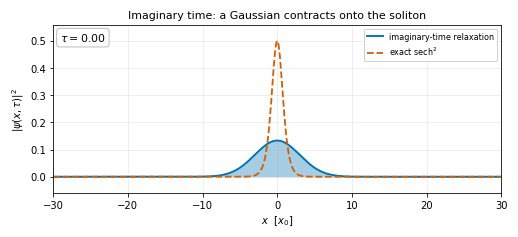

   [41 frames, 0.19 MB embedded in the notebook]


In [35]:
# ==============================================================================
# ANIMATION 1: a Gaussian relaxing into the bright soliton, in imaginary time
# ==============================================================================
sub = slice(None, None, 2)                                  # 41 of the 81 stored frames
dens_it = np.abs(frames_it[sub]) ** 2
tau_show = taus_it[sub]
exact_it = np.tile(phi_ref ** 2, (len(tau_show), 1))

err_it_frames = float(np.max(np.abs(dens_it[-1] - phi_ref ** 2)))
print(f"max | density - exact sech^2 | in the last frame: {err_it_frames:.3e}")

n_bytes = make_density_gif(x, dens_it, tau_show, overlay=exact_it,
                           xlabel=r"$x$  [$x_0$]", ylabel=r"$|\psi(x,\tau)|^2$", time_label=r"\tau",
                           label_num="imaginary-time relaxation", label_ana=r"exact $\mathrm{sech}^2$",
                           title=r"Imaginary time: a Gaussian contracts onto the soliton")
assert n_bytes < 1_500_000

The wide Gaussian narrows monotonically, most of the visible change happening between $\tau = 2$ and
$\tau = 20$, after which the frames stop differing — the history that the residual plot of Section 8.1 shows
quantitatively. The final frame differs from the analytic curve by $1.5\times10^{-3}$ in the density, which
is the $O(\Delta\tau)$ bias of Section 8.2 and not a failure to converge.

### 10.2 Animation 2: soliton against free packet

The same initial profile, propagated with $g=2$ (solid blue) and with $g=0$ (dashed orange). This is the
figure that the whole notebook exists to produce.

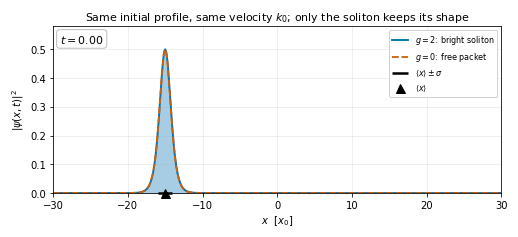

   [49 frames, 0.26 MB embedded in the notebook]


In [36]:
# ==============================================================================
# ANIMATION 2: the moving soliton and the free packet built from the same profile
# ==============================================================================
dens_sol, dens_lin = np.abs(fr_sol) ** 2, np.abs(fr_lin) ** 2
band_sol = np.stack([np.array([mean_position(p, x, dx, L) for p in fr_sol]) - np.sqrt(var_sol),
                     np.array([mean_position(p, x, dx, L) for p in fr_sol]) + np.sqrt(var_sol)], axis=1)

n_bytes = make_density_gif(x, dens_sol, t_fr, overlay=dens_lin,
                           mean_x=np.array([mean_position(p, x, dx, L) for p in fr_sol]),
                           band=band_sol, ylim=(0.0, 0.58),
                           label_num=r"$g=2$: bright soliton", label_ana=r"$g=0$: free packet",
                           title=r"Same initial profile, same velocity $k_0$; only the soliton keeps its shape")
assert n_bytes < 1_500_000

Both lumps travel at $k_0 = 1.047$ and stay centred on the same point — the centre of mass does not care
about the interaction, as Section 6.4 argued, and the fitted velocity agrees with $k_0$ to $10^{-11}$. What
differs is everything else: the orange free packet flattens until it fills the ring and starts interfering
with itself, while the blue soliton keeps the width marked by the black bar constant to $3.7\times10^{-7}$
over $24$ time units. The ratio of the two widths at the end of the run is $13.8$.

### 10.3 Animation 3: a Gaussian that is not a soliton

The best Gaussian of Section 6.1, at rest, on a logarithmic density scale so that the radiation is visible.

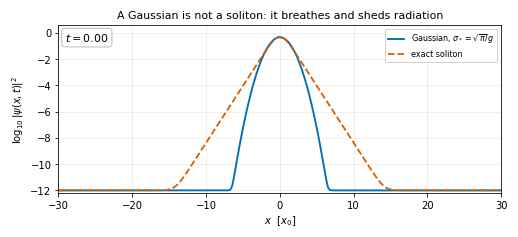

   [49 frames, 0.46 MB embedded in the notebook]


In [37]:
# ==============================================================================
# ANIMATION 3: breathing and radiation (log scale, so the shed radiation is visible)
# ==============================================================================
psi_b0 = jnp.asarray(normalise(gaussian_packet(x, SIGMA_STAR), dx))
fr_b = np.asarray(split_step_frames(psi_b0, jnp.asarray(k), G, V_ZERO, DT, n_inner_b, N_BREATH))
sub_b = slice(None, None, 5)                                # 49 of the 241 frames
dens_b = np.log10(np.abs(fr_b[sub_b]) ** 2 + 1e-12)
exact_b = np.tile(np.log10(np.abs(soliton_exact(x, g=G)) ** 2 + 1e-12), (dens_b.shape[0], 1))

n_bytes = make_density_gif(x, dens_b, t_b[sub_b], overlay=exact_b, ylim=(-12.2, 0.6), fill=False,
                           ylabel=r"$\log_{10}|\psi(x,t)|^2$",
                           label_num=r"Gaussian, $\sigma_*=\sqrt{\pi}/g$", label_ana=r"exact soliton",
                           title=r"A Gaussian is not a soliton: it breathes and sheds radiation")
assert n_bytes < 1_500_000

The central lump pulses, and two low wings crawl outwards from it, wrap around the ring and fill it with a
rippled background. That background sits near $10^{-4}$ in density, four orders below the peak, which is why
a linear plot shows nothing at all and why the middle panel of Section 9.4 had to integrate the norm outside
the core to detect it. The centre tracks the dashed exact soliton over four decades and departs from it only
where the radiation takes over, at $\vert x\vert\gtrsim5$.

### 10.4 Space-time maps, and static fall-backs

Animations cannot be read quantitatively and are dropped by some renderers. The same three runs as
space-time heat maps, which show the entire history at once.

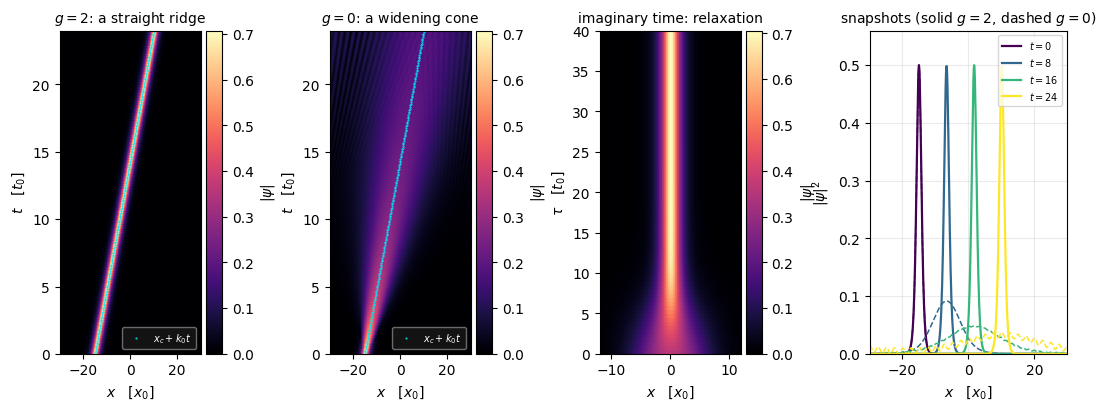

In [38]:
# ==============================================================================
# FIGURE: space-time maps of the three runs + snapshot panels (fall-back for the GIFs)
# ==============================================================================
t_map = np.linspace(0.0, T_MAX, 200)
n_map_inner = int(round((T_MAX / 199) / DT))
map_sol = np.abs(np.asarray(split_step_frames(psi_move0, jnp.asarray(k), G, V_ZERO, DT, n_map_inner, 199))) ** 2
map_lin = np.abs(np.asarray(split_step_frames(psi_move0, jnp.asarray(k), 0.0, V_ZERO, DT, n_map_inner, 199))) ** 2

fig = plt.figure(figsize=(13.0, 4.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.15], wspace=0.55)

for n_panel, (dat, ttl) in enumerate([(map_sol, r"$g=2$: a straight ridge"),
                                      (map_lin, r"$g=0$: a widening cone"),
                                      (np.abs(frames_it) ** 2, r"imaginary time: relaxation")]):
    axn = fig.add_subplot(gs[0, n_panel])
    if n_panel < 2:
        im = axn.imshow(dat ** 0.5, origin="lower", aspect="auto", cmap="magma",
                        extent=[-L / 2, L / 2, 0, T_MAX], interpolation="nearest")
        axn.set_ylabel(r"$t$   [$t_0$]")
        axn.plot(((-15.0 + K0 * t_map + L / 2) % L) - L / 2, t_map, ".", color="#00e5ff", ms=1.0,
                 label=r"$x_c+k_0t$")
        axn.legend(fontsize=7, loc="lower right", labelcolor="w", facecolor="0.15", framealpha=0.5)
    else:
        im = axn.imshow(dat ** 0.5, origin="lower", aspect="auto", cmap="magma",
                        extent=[-L / 2, L / 2, 0, TAU_MAX], interpolation="nearest")
        axn.set_ylabel(r"$\tau$   [$t_0$]"), axn.set_xlim(-12, 12)
    axn.set_xlabel(r"$x$   [$x_0$]")
    axn.set_title(ttl, fontsize=10)
    fig.colorbar(im, ax=axn, pad=0.03, label=r"$|\psi|$")

axn = fig.add_subplot(gs[0, 3])
for j, idx in enumerate([0, 16, 32, 48]):
    axn.plot(x, np.abs(fr_sol[idx]) ** 2, lw=1.6, color=cmap(j / 3), label=rf"$t={t_fr[idx]:.0f}$")
    axn.plot(x, np.abs(fr_lin[idx]) ** 2, lw=1.1, ls="--", color=cmap(j / 3))
axn.set_xlim(-L / 2, L / 2), axn.set_ylim(0, 0.56)
axn.set_xlabel(r"$x$   [$x_0$]"), axn.set_ylabel(r"$|\psi|^2$")
axn.set_title("snapshots (solid $g=2$, dashed $g=0$)", fontsize=10)
axn.grid(alpha=0.25), axn.legend(fontsize=7)
plt.show()

The first map is a ridge of constant width and constant brightness whose slope is $1/k_0$; the cyan dots are
the analytic $x_c + k_0t$ folded onto the ring, and they run along its crest. The second map, from the same
initial state with the interaction switched off, is a cone that opens until it fills the ring, at which point
its own tails meet and produce the interference fringes of 00a. The third is imaginary time: a broad bright
band that narrows and brightens as the Gaussian contracts onto the soliton, and stops changing at
$\tau\approx25$.

## 11. Summary

### 11.1 Key takeaways

* **A nonlinear Schrödinger equation is a mean-field statement, not a modification of quantum mechanics.**
  Putting $N$ bosons into one orbital and replacing the pair interaction by a contact pseudopotential turns
  the linear $N$-body problem into the cubic Eq. (8). What is lost is every correlation between particles,
  including — Section 6.5 — the delocalisation of the centre of mass that the exact ground state must have.
* **One parameter.** Non-dimensionalisation collapses $m$, $N$, $a_s$ and $\omega_\perp$ into
  $g = -Ng_{\rm 1D}mx_0/\hbar^{2}$, and choosing $x_0$ to be the soliton width sets $g=2$ once and for all.
  The two 2002 lithium experiments are the same calculation with different conversion factors.
* **The soliton, in closed form.** The stationary equation has a mechanical first integral; integrating it
  gives $\phi = (\sqrt g/2)\,\mathrm{sech}(gx/2)$ with $\mu = -g^{2}/8$, $E = -g^{2}/24$,
  $\sigma = \pi/(\sqrt3 g)$ and peak density $g/4$ — all verified on the grid to $10^{-12}$.
* **$\mu \ne E$.** $\mu = E_{\rm kin}+2E_{\rm int}$ while $E = E_{\rm kin}+E_{\rm int}$; the physical
  content is $\mu = dE_{\rm tot}/dN$, checked three ways in Section 6.3.
* **Why the soliton exists, in one formula.** $E(w) = a/w^{2} - bg/w$: dispersion pushes out, attraction
  pulls in, and in one dimension the two always balance at a finite width. In three dimensions the
  attraction term is $-g/w^{3}$ and nothing stops the collapse; that is why the experiments are done in
  waveguides, and why they still sit only factors $1.02$ and $1.13$ below the computed collapse threshold
  $\kappa_c = 0.675$ — within the error bar on their atom numbers.
* **Imaginary time is normalised gradient flow.** $t\to-i\tau$ makes excited components decay as
  $e^{-(E_n-E_0)\tau}$ for a linear problem — a rate we measured to be $0.999$ against a gap of $1$ — and,
  for a nonlinear one, guarantees $dE/d\tau = -2\Vert(\hat H_{\rm GP}-\mu)\psi\Vert^{2}\le0$, an identity
  confirmed to $2.8\times10^{-4}$ in Section 7.7.
* **The method converges to the lowest state it overlaps.** An odd initial guess in a symmetric trap returns
  the *first excited* state and a perfectly convincing $E=3/2$ — until round-off breaks the symmetry at
  $\tau\approx35$ and the answer changes. Projection (Gram-Schmidt) turns this failure mode into a way of
  computing excited states.
* **The discretisation bias has a measurable order, and it is not always the obvious one.** Strang splitting
  is $O(\Delta\tau^{2})$, but the discrete renormalisation makes the *converged state* of the nonlinear flow
  $O(\Delta\tau)$; because $E$ is stationary at the minimiser, its error is $O(\Delta\tau^{2})$ and $\mu$'s is
  $O(\Delta\tau)$. Measured slopes: $0.99$ for the state, $1.97$ for the energy, $0.99$ for $\mu$; the same
  code with $g=0$ gives $2.000$ and $3.995$.
* **Split-step is unconditionally stable; RK4 is not.** The explicit integrator explodes above
  $\Delta t = 2\sqrt2/E_{\max} = 0.573\,\Delta x^{2}$ — measured cliff between $0.0075$ and $0.0080$ — while
  the unitary splitting conserves the norm at thirteen times that step. Stability is not accuracy: the order
  in $\Delta t$ still has to be measured, and it is $2.00$.
* **A soliton is a particle with a shape that is an attractor.** It moves at $k_0$ with constant width
  ($3.7\times10^{-7}$ over $24$ time units) while the same profile without interactions spreads by a factor
  $13.8$; and a Gaussian that is not a soliton breathes and sheds $0.4\%$ of its norm as radiation in the
  first five time units, leaving a core that still lies on a $\mathrm{sech}^{2}$.

### 11.2 The workflow checklist, extended

The list from 00a and 00b, with the two steps this notebook adds.

1. **Non-dimensionalise.** Reduce the problem to the smallest set of dimensionless parameters, and build the
   conversion table back to the laboratory.
2. **Solve something exactly first.** Even for a nonlinear equation there is often a closed-form solution;
   it is worth more than any number of plausible-looking runs.
3. **Discretise, and write down every error term separately.** Here: $\Delta x$ (spectral), $L$ (exponential
   in the tails), $\Delta\tau$ and $\Delta t$ (both $O(\cdot^{2})$ in the propagator, but with different
   consequences for the converged state).
4. **Imaginary time first, then real time.** Relax to the state you want with a gradient flow, check it
   against every analytic number you have, and only then propagate it. A real-time run started from a state
   that is not what you think it is produces dynamics that is not what you think it is.
5. **Monitor the residual, not the picture.** $\Vert(\hat H-\mu)\psi\Vert$ and the energy decrement are
   quantitative; "it stopped changing on the plot" is not. Check the *state*, not only the energy: symmetry
   can hand you a converged excited state.
6. **Identify the conserved quantities and watch them.** Norm, energy and momentum here; the first is
   conserved by construction and therefore proves nothing, the other two are real tests.
7. **Run a convergence test in every parameter separately**, and compare the measured slope with the derived
   order. Extrapolate when the law is known.
8. **Only then explore.** And when the new physics looks surprising, repeat steps 3-7.

### 11.3 Exercises

**1. (★) A soliton in a trap.** Add $V(x) = \tfrac12\omega^{2}x^{2}$ with $\omega = 0.05$ to
`imaginary_time_ground_state` (the argument `V` is already there) and find the ground state for
$g = 0.5, 1, 2, 4$. Plot the width against $g$ and identify the two limits: the harmonic ground state of
width $1/\sqrt{2\omega}$ when the trap dominates, and the free soliton width $\pi/(\sqrt3 g)$ when the
interaction does. Then displace the state and propagate it in real time: the centre oscillates at frequency
$\omega$ regardless of $g$ (Section 6.4 explains why), which is what Strecker et al. observed.

**2. (★) Measure the convergence rate yourself.** Repeat the demonstration of Section 7.4 for a harmonic
trap of frequency $\omega \ne 1$ — the gap is then $\omega$ — and confirm that the fitted slope tracks it
over $\omega\in\{0.5,1,2\}$. Predict, before running, how long $\tau$ must be to reach a residual of
$10^{-8}$.

**3. (★★) The virial theorem.** Show analytically that for any stationary solution of Eq. (15) in one
dimension, $E_{\rm int} = -2E_{\rm kin}$. (Substitute the scaled profile
$\phi_\lambda(x) = \sqrt\lambda\,\phi(\lambda x)$, which stays normalised for all $\lambda$, into Eq. (10),
differentiate with respect to $\lambda$ at $\lambda=1$, and set the result to zero.) Verify it numerically
for the state produced by imaginary time, and use it as an extra convergence monitor.

**4. (★★) A dark soliton.** For $g<0$ the localised object is a density *notch* on a uniform background,
$\psi \propto \tanh(x/\xi)$, which carries a phase jump of $\pi$. Build it by imprinting the phase
$\pi\,\Theta(x)$ on the uniform state of Section 8.5 (smooth the step over a few grid points), propagate it,
and measure the depth and width of the notch. Verify that $\xi = 1/\sqrt{\vert g\vert n}$ with
$n = 1/L$ the background density. Why can a dark soliton not be obtained by imaginary time from an arbitrary
guess?

**5. (★★) Fourth-order splitting.** The composition
$S(\gamma h)\,S((1-2\gamma)h)\,S(\gamma h)$ with $\gamma = 1/(2-2^{1/3})$ is fourth-order accurate
(Yoshida's construction; note $1-2\gamma<0$, so one sub-step runs backwards). Implement it for real time,
repeat the convergence study of Section 9.5, and check that the fitted slope is $4$. At which $\Delta t$ does
it become cheaper than the second-order method for a given accuracy?

**6. (★★) The two-parameter ansatz $\mathrm{sech}^{p}(x/w)$.** Extend Section 6.1 to a trial family
$\psi\propto\mathrm{sech}^{p}(x/w)$ with two parameters $p$ and $w$, minimise $E$ numerically over both with
`jax.grad`, and confirm that the optimum is $p=1$, $w=2/g$. Then repeat with a trap added and watch $p$ grow:
$\mathrm{sech}^{p}(x/w)\to\exp[-px^{2}/(2w^{2})]$ as $p\to\infty$ at fixed $w/\sqrt p$, so a Gaussian is the
$p\to\infty$ member of this family and the drift of $p$ measures how far the trap has taken over.

**7. (★★★) The collapse threshold, one dimension at a time.** Solve the two-dimensional Gross-Pitaevskii
equation on a $256\times256$ grid with the same split-step method (the kinetic factor becomes
$e^{-i(k_x^{2}+k_y^{2})\Delta t/4}$) and show numerically that in 2D the imaginary-time relaxation either
spreads without limit or contracts without limit depending on $g$, with no stable width in between — the
critical case of Section 6.2. Estimate the critical $g$ and compare with the known Townes-soliton value.

**8. (★★★) Beyond the mean field, cheaply.** The Bogoliubov spectrum of the bright soliton is obtained by
linearising Eq. (8) around $\phi$ and diagonalising the resulting $2\times2$ operator. Build it on the grid
with finite differences, diagonalise it densely for $N_x = 256$, and identify the two zero modes (translation
and phase) and the continuum edge at $\vert\mu\vert = g^{2}/8$. The absence of any discrete mode in between is
the statement that the soliton has no internal oscillation: a perturbed soliton has nothing to oscillate in,
so the breathing of Section 9.4 can only decay by radiating — which is why it would die away on an infinite
line, and does not on the ring, where the radiation comes back.

**9. (★★★) Restoring second order in imaginary time.** Section 8.2 traced the $O(\Delta\tau)$ bias of the
converged state to the fact that the splitting integrates the *unnormalised* field
$X[\psi] = \tfrac12\psi'' + g\vert\psi\vert^{2}\psi$, which is not scale-covariant. Replace it by
$\tilde X[\psi] = \tfrac12\psi'' + g(\vert\psi\vert^{2}/\Vert\psi\Vert^{2})\psi$, whose flow commutes with
scaling. Its nonlinear substep can be integrated exactly: with $\rho = \vert\psi\vert^{2}$ normalised at the
start of the substep, reparametrise $ds = d\tau/\Vert\psi\Vert^{2}$, so that
$\rho(s) = \rho_0/(1-2g\rho_0 s)$ and
$\tau(s) = -\frac{\Delta x}{2g}\sum_j\ln\!\left(1-2g\rho_{0,j}s\right)$; solve that scalar equation for $s$
(bisection) and apply $\psi\to\psi/\sqrt{1-2g\rho_0 s}$. Repeat the convergence study of Section 8.2 and
check that the state and $\mu$ become $O(\Delta\tau^{2})$ and the energy $O(\Delta\tau^{4})$ — the orders of
the linear column. Then ask what this costs per step, and whether Richardson extrapolation is not the better
deal.

### 11.4 References

* L. P. Pitaevskii and S. Stringari, *Bose-Einstein Condensation*, Oxford University Press (2003) — the
  Gross-Pitaevskii theory of dilute condensates and its derivation from the many-body Hamiltonian.
* C. J. Pethick and H. Smith, *Bose-Einstein Condensation in Dilute Gases*, 2nd ed., Cambridge University
  Press (2008) — Chapter 5 (interactions between atoms, the contact interaction of Section 2.2) and Chapter 6
  (theory of the condensed state, the mean-field derivation of Section 2.1).
* M. Olshanii, *Atomic scattering in the presence of an external confinement and a gas of impenetrable
  bosons*, Phys. Rev. Lett. **81**, 938 (1998) — the one-dimensional coupling constant, Eq. (7).
* V. E. Zakharov and A. B. Shabat, *Exact theory of two-dimensional self-focusing and one-dimensional
  self-modulation of waves in nonlinear media*, Sov. Phys. JETP **34**, 62 (1972) — integrability of the
  nonlinear Schrödinger equation by inverse scattering.
* L. Khaykovich, F. Schreck, G. Ferrari, T. Bourdel, J. Cubizolles, L. D. Carr, Y. Castin and C. Salomon,
  *Formation of a matter-wave bright soliton*, Science **296**, 1290 (2002).
* K. E. Strecker, G. B. Partridge, A. G. Truscott and R. G. Hulet, *Formation and propagation of matter-wave
  soliton trains*, Nature **417**, 150 (2002).
* J. H. V. Nguyen, D. Luo and R. G. Hulet, *Formation of matter-wave soliton trains by modulational
  instability*, Science **356**, 422 (2017).
* W. Bao and Q. Du, *Computing the ground state solution of Bose-Einstein condensates by a normalized
  gradient flow*, SIAM J. Sci. Comput. **25**, 1674 (2004) — norm conservation and energy decrease of the
  normalised gradient flow, the result behind Section 7.8.
* N. G. Parker, S. L. Cornish, C. S. Adams and A. M. Martin, *Bright solitary waves and trapped solutions in
  Bose-Einstein condensates with attractive interactions*, J. Phys. B **40**, 3127 (2007) — the collapse
  threshold $\kappa_c = 0.675\pm0.005$ used in Section 6.8.
* E. A. Donley, N. R. Claussen, S. L. Cornish, J. L. Roberts, E. A. Cornell and C. E. Wieman, *Dynamics of
  collapsing and exploding Bose-Einstein condensates*, Nature **412**, 295 (2001) — the Bosenova of
  Section 6.2.
* L. Salasnich, A. Parola and L. Reatto, *Effective wave equations for the dynamics of cigar-shaped and
  disk-shaped Bose condensates*, Phys. Rev. A **65**, 043614 (2002) — the non-polynomial Schrödinger equation.
* L. Salasnich, A. Parola and L. Reatto, *Condensate bright solitons under transverse confinement*, Phys. Rev. A
  **66**, 043603 (2002) — the analytic collapse threshold $2/3$ of Section 6.8.
* Y. Lai and H. A. Haus, *Quantum theory of solitons in optical fibers. I. Time-dependent Hartree
  approximation*, Phys. Rev. A **40**, 844 (1989), and *II. Exact solution*, Phys. Rev. A **40**, 854
  (1989) — the quantum states behind the classical soliton, referred to in Section 6.5.
* G. P. Agrawal, *Nonlinear Fiber Optics*, 5th ed., Academic Press (2013) — Chapter 5 (*Optical
  Solitons*), the optical version of Eq. (8); the appendix *Numerical Code for the NLS Equation* gives the
  split-step Fourier method as it is used in photonics.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of
  Scientific Computing*, 3rd ed., Cambridge University Press (2007) — Chapter 12 (fast Fourier transform),
  Chapter 17 (integration of ordinary differential equations, including the Runge-Kutta stability of
  Section 9.1) and Chapter 20 (partial differential equations).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes in Fortran 90: The
  Art of Parallel Scientific Computing*, 2nd ed. (Fortran Numerical Recipes, Volume 2), Cambridge University
  Press (1996) — the routines of the second edition rewritten as parallel, whole-array Fortran 90, including
  the FFT and the ODE integrators (the methods themselves are explained in the companion text).

### 11.5 What comes next

The propagator written here is reused, unchanged, in
[00d — two-soliton collisions](00d_two_soliton_collisions.ipynb): two solitons launched at each other pass
straight through, emerge with their shapes intact and only a shift in position and phase to show for it —
the experimental signature of integrability, and something no linear wave packet and no classical particle
does. What happens during the overlap depends on the relative phase, which Nguyen, Dyke, Luo, Malomed and
Hulet measured directly (Nature Physics **10**, 918 (2014)).

Then [01 — JAX from scratch](01_jax_from_scratch.ipynb) explains the three tools used here on trust —
`jit`, `lax.scan` and `grad` — together with `vmap` and the rest of the library, and the many-body part of
the course begins.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/